# Analyse results from Pypsa-Earth
This notebook reads the latest optimization described in the config.yaml file and makes plots and summaries of the results.

Sources: 
- Plot capacity - map view: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/viz/regional_transm_system_viz.ipynb
- Analyse energy potential: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/build_renewable_profiles.ipynb
- Analyse energy generation: https://pypsa.readthedocs.io/en/latest/examples/statistics.html

Some files are needed:
* PyPSA network file (e.g. "elec.nc" contains a lot of details and looks perfect)
* a country shape file (may be found in "resources/shapes/country_shapes.geojson")
* a renewable profile file (may be found in "resources/renewable_profiles/....nc)

## Import packages

In [32]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy
import glob
import logging

## Settings

### Set project root

In [33]:
if not os.path.isdir("pypsa-earth-geothermal"):
    os.chdir("../..")

PARENT = os.path.realpath("pypsa-earth-geothermal") + os.sep

### Load configuration

In [34]:
with open(os.path.join(PARENT, "config.yaml"), "r") as f:
    cfg = yaml.safe_load(f)

run = cfg.get("run", {}) or {}
scen = cfg.get("scenario", {}) or {}
costs = cfg.get("costs", {}) or {}
expo = cfg.get("export", {}) or {}

results_dir = (cfg.get("results_dir", "results/") or "results/").strip("/") + "/"

### Set add-on file paths

In [35]:
scenario_name = cfg["run"]["name"]
scenario_subpath = scenario_name + "/" if scenario_name else ""

# Network file
network_path = "/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/results/EGS_Test/postnetworks/elec_s_10_ec_lcopt_Co2L0.1-Ep_144h_2050_0.0514_AG_0export_393import.nc"
country_shape_path = PARENT + f"resources/{scenario_subpath}shapes/country_shapes.geojson"
# Country shape file
regions_onshore_path = PARENT + f"resources/{scenario_subpath}shapes/country_shapes.geojson"
# Renewable profile file
solar_path = "/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test//renewable_profiles/profile_solar.nc"
onwind_path = "/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/renewable_profiles/profile_onwind.nc"

### Directory definitions

In [36]:
RDIR = (run.get("name") or "").strip()
RDIR = (RDIR + "/") if RDIR else ""

# Scan for solved networks to analyse
result_dir = os.path.join(PARENT, results_dir, RDIR, "postnetworks")

### Wildcard helper

In [37]:
def pick(val, allow_empty=False):
    """
    Return single value if exactly one is given.
    Return '*' if multiple values or empty (unless allow_empty=True).
    """
    if val is None:
        return "*"
    if isinstance(val, (list, tuple)):
        if len(val) == 1:
            s = "" if val[0] is None else str(val[0])
            return s if (allow_empty or s != "") else "*"
        return "*"
    s = "" if val is None else str(val)
    return s if (allow_empty or s != "") else "*"

### Build wildcard segments

In [38]:
simpl = pick(scen.get("simpl", [""]), allow_empty=True)
clusters = pick(scen.get("clusters"))
ll = pick(scen.get("ll"))
opts = pick(scen.get("opts"))
sopts = pick(scen.get("sopts", [""]), allow_empty=True)
plan = pick(scen.get("planning_horizons"))
dr = pick(costs.get("discountrate"))
demand = pick(scen.get("demand"))

h2_raw = pick(expo.get("h2export"))
h2 = (h2_raw + "export") if h2_raw != "*" else "*export"

### Pattern builders

In [39]:
patterns = [
    os.path.join(result_dir, f"elec_s{simpl}_{clusters}_ec_l{ll}_{opts}.nc"),
    os.path.join(result_dir, f"elec_s{simpl}_{clusters}_ec_l{ll}_{opts}_*.nc"),
]

### Find networks

In [40]:
all_matches = []
for pat in patterns:
    all_matches.extend(glob.glob(pat))

# remove duplicates
all_matches = sorted(set(all_matches), key=os.path.getmtime)

if not all_matches:
    recent = sorted(
        glob.glob(os.path.join(PARENT, results_dir, "**", "*.nc"), recursive=True),
        key=os.path.getmtime
    )[-20:]
    recent_txt = "\n".join(os.path.relpath(p, PARENT) for p in recent) or "(none)"
    raise FileNotFoundError(
        "No network matched.\n"
        "Here are the last few .nc files under results/:\n"
        f"{recent_txt}"
    )

print("Found networks:")
for m in all_matches:
    print("-", os.path.relpath(m, PARENT))

Found networks:
- results/Without_EGS_Test/postnetworks/elec_s_10_ec_lcopt_Co2L0.0-Ep_144h_2050_0.0514_AG_0export_393import - without EGS.nc
- results/Without_EGS_Test/postnetworks/elec_s_10_ec_lcopt_Co2L0.0-Ep_48h_2050_0.0514_AG_0export_393import.nc
- results/Without_EGS_Test/postnetworks/elec_s_10_ec_lcopt_Co2L0.0-Ep_144h_2050_0.0514_AG_0export_393import.nc


## Energy system analysis setup - power and energy generation

In [41]:
warnings.simplefilter(action='ignore', category=FutureWarning)
logging.getLogger("pypsa.io").setLevel(logging.ERROR) # ignore warnings

chosen = all_matches[-1]  # choose newest one

n = pypsa.Network(chosen)

country_shape = gpd.read_file(country_shape_path)
country_coordinates = country_shape.total_bounds[[0, 2, 1, 3]]
gadm_shapes = gpd.read_file("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/shapes/gadm_shapes.geojson")
warnings.simplefilter(action='default', category=FutureWarning)

## Data import check

Plot of the region of interest

Text(0.5, 1.0, 'JP')

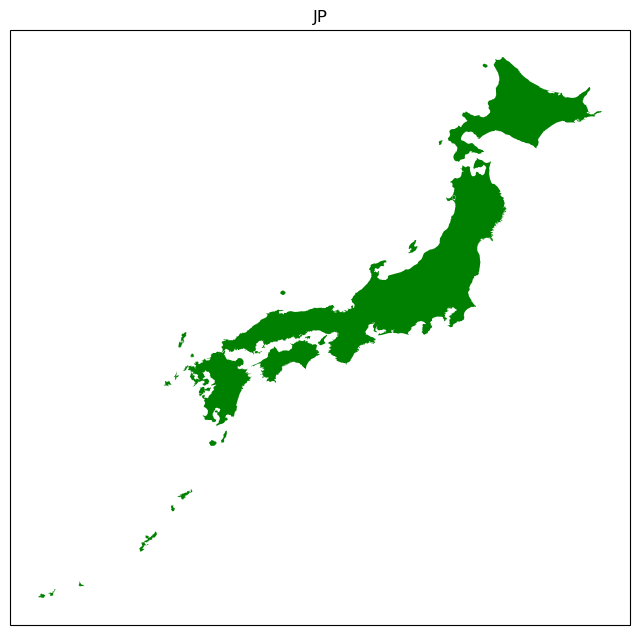

In [42]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.PlateCarree()})
with plt.rc_context({"patch.linewidth": 0.}):
    country_shape.plot(
    ax=ax,
    facecolor="green",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
    )
ax.set_title(", ".join(country_shape.name.values))

List number of components by type

In [43]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 1134 entries
Component 'Carrier' has 135 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 88 entries
Component 'LineType' has 35 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 3058 entries
Component 'Load' has 1421 entries
Component 'Generator' has 1815 entries
Component 'StorageUnit' has 44 entries
Component 'Store' has 754 entries


List the snapshots of the PyPSA network

In [44]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2013-01-01', '2013-01-07', '2013-01-13', '2013-01-19',
               '2013-01-25', '2013-01-31', '2013-02-06', '2013-02-12',
               '2013-02-18', '2013-02-24', '2013-03-02', '2013-03-08',
               '2013-03-14', '2013-03-20', '2013-03-26', '2013-04-01',
               '2013-04-07', '2013-04-13', '2013-04-19', '2013-04-25',
               '2013-05-01', '2013-05-07', '2013-05-13', '2013-05-19',
               '2013-05-25', '2013-05-31', '2013-06-06', '2013-06-12',
               '2013-06-18', '2013-06-24', '2013-06-30', '2013-07-06',
               '2013-07-12', '2013-07-18', '2013-07-24', '2013-07-30',
               '2013-08-05', '2013-08-11', '2013-08-17', '2013-08-23',
               '2013-08-29', '2013-09-04', '2013-09-10', '2013-09-16',
               '2013-09-22', '2013-09-28', '2013-10-04', '2013-10-10',
               '2013-10-16', '2013-10-22', '2013-10-28', '2013-11-03',
               '2013-11-09', '2013-11-15', '2013-11-21', '2013-11-27',
      

In [45]:
bad_gen = n.generators[n.generators["bus"].isna() | (n.generators["bus"] == "")]
print(bad_gen[["bus", "carrier"]])
print(bad_gen.index.tolist())

Empty DataFrame
Columns: [bus, carrier]
Index: []
[]


In [46]:
for b in n.buses.index:
    print(b)

JP.10_1_AC
JP.11_1_AC
JP.12_1_AC
JP.12_1_DC
JP.13_1_AC
JP.14_1_AC
JP.15_1_AC
JP.16_1_AC
JP.17_1_AC
JP.18_1_AC
JP.19_1_AC
JP.1_1_AC
JP.20_1_AC
JP.21_1_AC
JP.22_1_AC
JP.23_1_AC
JP.24_1_AC
JP.25_1_AC
JP.26_1_AC
JP.27_1_AC
JP.28_1_AC
JP.29_1_AC
JP.2_1_AC
JP.30_1_AC
JP.31_1_AC
JP.32_1_AC
JP.33_1_AC
JP.34_1_AC
JP.35_1_AC
JP.36_1_AC
JP.37_1_AC
JP.38_1_AC
JP.39_1_AC
JP.3_1_AC
JP.3_1_DC
JP.40_1_AC
JP.41_1_AC
JP.42_1_AC
JP.43_1_AC
JP.44_1_AC
JP.45_1_AC
JP.46_1_AC
JP.47_1_AC
JP.4_1_AC
JP.5_1_AC
JP.6_1_AC
JP.7_1_AC
JP.8_1_AC
JP.9_1_AC
co2 atmosphere
JP.10_1_AC co2 stored
JP.11_1_AC co2 stored
JP.12_1_AC co2 stored
JP.13_1_AC co2 stored
JP.14_1_AC co2 stored
JP.15_1_AC co2 stored
JP.16_1_AC co2 stored
JP.17_1_AC co2 stored
JP.18_1_AC co2 stored
JP.19_1_AC co2 stored
JP.1_1_AC co2 stored
JP.20_1_AC co2 stored
JP.21_1_AC co2 stored
JP.22_1_AC co2 stored
JP.23_1_AC co2 stored
JP.24_1_AC co2 stored
JP.25_1_AC co2 stored
JP.26_1_AC co2 stored
JP.27_1_AC co2 stored
JP.28_1_AC co2 stored
JP.29_1_AC co2 st

## Analyse energy system

Analyse the current capacity of the energy system - map view

Total existing electricity capacity shown on map: 325.9 GW


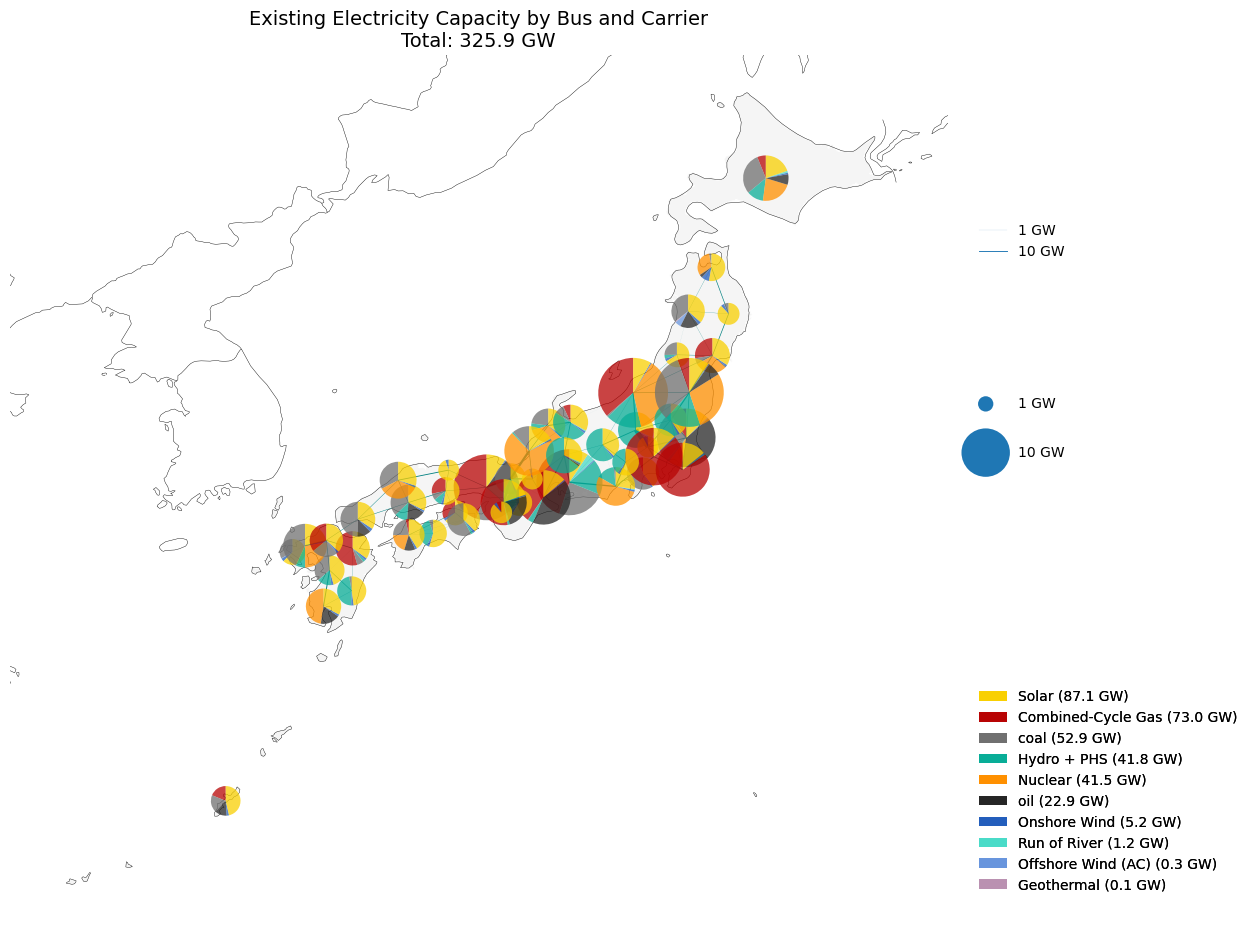

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action="ignore", category=UserWarning)

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

# Larger value = smaller bus pie charts = less overlap
bus_scale = 2.5e4
line_scale = 1.5e4

# Legend sizes in MW
bus_sizes = [1000, 10000]      # 1 GW and 10 GW
line_sizes = [1000, 10000]     # 1 GW and 10 GW

electric_bus_carriers = ["AC", "DC", "low voltage"]

# Set to True if hydro and PHS should be shown together
merge_hydro_phs = True
combined_hydro_name = "hydro + PHS"

# Minimum capacity in MW for showing a carrier in the legend
min_capacity_threshold = 0


# ------------------------------------------------------------
# Helper: rename carriers for plotting
# ------------------------------------------------------------
def rename_carriers(series):
    """
    Rename selected carriers in a MultiIndex Series with levels bus/carrier.
    """
    if not merge_hydro_phs:
        return series

    series = series.copy()

    new_index = pd.MultiIndex.from_arrays(
        [
            series.index.get_level_values("bus"),
            series.index.get_level_values("carrier").to_series().replace({
                "hydro": combined_hydro_name,
                "Hydro": combined_hydro_name,
                "PHS": combined_hydro_name,
                "phs": combined_hydro_name,
            }).values
        ],
        names=["bus", "carrier"]
    )

    series.index = new_index
    return series.groupby(level=["bus", "carrier"]).sum()


# ------------------------------------------------------------
# Backup carrier table, because we temporarily add combined carrier
# ------------------------------------------------------------
carriers_backup = n.carriers.copy()

if merge_hydro_phs and combined_hydro_name not in n.carriers.index:
    # Create a temporary carrier entry so n.plot can find a color
    n.carriers.loc[combined_hydro_name, :] = np.nan

    if "hydro" in n.carriers.index:
        n.carriers.loc[combined_hydro_name, "color"] = n.carriers.loc["hydro", "color"]
    elif "PHS" in n.carriers.index:
        n.carriers.loc[combined_hydro_name, "color"] = n.carriers.loc["PHS", "color"]
    else:
        n.carriers.loc[combined_hydro_name, "color"] = "#1f77b4"

    n.carriers.loc[combined_hydro_name, "nice_name"] = "Hydro + PHS"


# ------------------------------------------------------------
# 1) Existing generator capacities from n.generators
# ------------------------------------------------------------
generators = n.generators.copy()

generators = generators[
    ~generators.carrier.astype(str).str.contains("load", case=False, na=False)
].copy()

generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

generators = generators[
    generators["bus_carrier"].isin(electric_bus_carriers)
].copy()

generator_capacity_by_bus_carrier = (
    generators
    .assign(p_nom=generators["p_nom"].fillna(0))
    .groupby(["bus", "carrier"])["p_nom"]
    .sum()
)

generator_capacity_by_bus_carrier.index.names = ["bus", "carrier"]
generator_capacity_by_bus_carrier = rename_carriers(generator_capacity_by_bus_carrier)


# ------------------------------------------------------------
# 2) Existing storage unit power capacities from n.storage_units
# ------------------------------------------------------------
storage_units = n.storage_units.copy()

storage_units = storage_units[
    storage_units["p_nom"].fillna(0) > 0
].copy()

storage_units["bus_carrier"] = storage_units.bus.map(n.buses.carrier)

storage_units = storage_units[
    storage_units["bus_carrier"].isin(electric_bus_carriers)
].copy()

storage_capacity_by_bus_carrier = (
    storage_units
    .assign(p_nom=storage_units["p_nom"].fillna(0))
    .groupby(["bus", "carrier"])["p_nom"]
    .sum()
)

storage_capacity_by_bus_carrier.index.names = ["bus", "carrier"]
storage_capacity_by_bus_carrier = rename_carriers(storage_capacity_by_bus_carrier)


# ------------------------------------------------------------
# 3) Existing electricity-producing link capacities from n.links
# ------------------------------------------------------------
links = n.links.copy()

# Only current/existing links, not optimized expansion
links = links[
    links["p_nom"].fillna(0) > 0
].copy()

link_capacity_parts = []

# In PyPSA links:
# p_nom is the input capacity.
# Electrical output capacity on bus1 = p_nom * efficiency
# Electrical output capacity on bus2 = p_nom * efficiency2
# etc.
for bus_number in range(1, 6):
    bus_col = f"bus{bus_number}"

    if bus_col not in links.columns:
        continue

    if bus_number == 1:
        efficiency_col = "efficiency"
    else:
        efficiency_col = f"efficiency{bus_number}"

    output_bus_carrier = links[bus_col].map(n.buses.carrier)
    input_bus_carrier = links["bus0"].map(n.buses.carrier)

    # Count only links that produce electricity from a non-electric input
    mask = (
        output_bus_carrier.isin(electric_bus_carriers)
        & ~input_bus_carrier.isin(electric_bus_carriers)
    )

    if not mask.any():
        continue

    selected_links = links.loc[mask].copy()

    if efficiency_col in links.columns:
        if bus_number == 1:
            efficiency = links.loc[mask, efficiency_col].fillna(1)
        else:
            efficiency = links.loc[mask, efficiency_col].fillna(0)
    else:
        efficiency = 1 if bus_number == 1 else 0

    selected_links["electric_capacity"] = (
        selected_links["p_nom"].fillna(0) * efficiency
    )

    tmp = (
        selected_links
        .assign(bus=selected_links[bus_col])
        .groupby(["bus", "carrier"])["electric_capacity"]
        .sum()
    )

    tmp.index.names = ["bus", "carrier"]
    link_capacity_parts.append(tmp)


if link_capacity_parts:
    link_capacity_by_bus_carrier = (
        pd.concat(link_capacity_parts)
        .groupby(level=["bus", "carrier"])
        .sum()
    )
else:
    link_capacity_by_bus_carrier = pd.Series(
        dtype=float,
        index=pd.MultiIndex.from_tuples([], names=["bus", "carrier"])
    )

link_capacity_by_bus_carrier = rename_carriers(link_capacity_by_bus_carrier)


# ------------------------------------------------------------
# 4) Combine all capacities for bus pie charts
# ------------------------------------------------------------
buses = (
    pd.concat(
        [
            generator_capacity_by_bus_carrier,
            storage_capacity_by_bus_carrier,
            link_capacity_by_bus_carrier,
        ]
    )
    .groupby(level=["bus", "carrier"])
    .sum()
)

# Keep only positive capacities
buses = buses[buses > 0]

# Remove V2G from map and legend
buses = buses[
    buses.index.get_level_values("carrier").str.lower() != "v2g"
]

# Total check
total_capacity_GW = buses.sum() / 1e3
print(f"Total existing electricity capacity shown on map: {total_capacity_GW:.1f} GW")


# ------------------------------------------------------------
# 5) Make sure all plotted carriers have colors
# ------------------------------------------------------------
for carrier in buses.index.get_level_values("carrier").unique():
    if carrier not in n.carriers.index:
        n.carriers.loc[carrier, :] = np.nan
        n.carriers.loc[carrier, "nice_name"] = carrier
        n.carriers.loc[carrier, "color"] = "#cccccc"

    if pd.isna(n.carriers.loc[carrier, "color"]) or n.carriers.loc[carrier, "color"] == "":
        n.carriers.loc[carrier, "color"] = "#cccccc"

    if pd.isna(n.carriers.loc[carrier, "nice_name"]) or n.carriers.loc[carrier, "nice_name"] == "":
        n.carriers.loc[carrier, "nice_name"] = carrier


# ------------------------------------------------------------
# 6) Filter network links for line plotting only
# ------------------------------------------------------------
link_bus0_base = n.links.bus0.astype(str).str.split("_AC").str[0]
link_bus1_base = n.links.bus1.astype(str).str.split("_AC").str[0]

valid_links = n.links[
    link_bus0_base.isin(gadm_shapes.index)
    & link_bus1_base.isin(gadm_shapes.index)
    & (n.links.p_nom.fillna(0) > 0)
].copy()

links_backup = n.links.copy()
n.links = valid_links


# ------------------------------------------------------------
# 7) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(15, 12),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# Plot regions first so the pies are on top
country_shape.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0.3,
    zorder=0,
)

with plt.rc_context({"patch.linewidth": 0.0}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.75,
        line_widths=n.lines.s_nom.fillna(0) / line_scale,
        link_widths=n.links.p_nom.fillna(0) / line_scale,
        line_colors="teal",
        link_colors="teal",
        ax=ax,
        margin=0.05,
        color_geomap=None,
    )

# Set map extent with small buffer
bounds = country_shape.total_bounds
lon_buffer = 1.5
lat_buffer = 1.0

ax.set_extent(
    [
        bounds[0] - lon_buffer,
        bounds[2] + lon_buffer,
        bounds[1] - lat_buffer,
        bounds[3] + lat_buffer,
    ],
    crs=ccrs.PlateCarree()
)

ax.set_title(
    f"Existing Electricity Capacity by Bus and Carrier\n"
    f"Total: {total_capacity_GW:.1f} GW",
    fontsize=14
)


# ------------------------------------------------------------
# 8) Legends
# ------------------------------------------------------------
legend_kwargs = {
    "loc": "upper left",
    "frameon": False,
}

add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000:.0f} GW" for s in line_sizes],
    legend_kw={
        "bbox_to_anchor": (1.02, 0.82),
        **legend_kwargs,
    },
)

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000:.0f} GW" for s in bus_sizes],
    legend_kw={
        "bbox_to_anchor": (1.02, 0.62),
        "labelspacing": 2.5,
        **legend_kwargs,
    },
)

# Carrier legend: only carriers that actually appear in buses
carrier_totals = (
    buses
    .groupby(level="carrier")
    .sum()
    .sort_values(ascending=False)
)

carrier_totals = carrier_totals[carrier_totals > min_capacity_threshold]

colors_legend = []
labels_legend = []

for carrier, value in carrier_totals.items():
    color = n.carriers.loc[carrier, "color"] if carrier in n.carriers.index else "#cccccc"
    name = n.carriers.loc[carrier, "nice_name"] if carrier in n.carriers.index else carrier

    colors_legend.append(color)
    labels_legend.append(f"{name} ({value / 1e3:.1f} GW)")

add_legend_patches(
    ax,
    colors_legend,
    labels_legend,
    legend_kw={
        "bbox_to_anchor": (1.02, 0.02),
        "loc": "lower left",
        "frameon": False,
    },
)

fig.subplots_adjust(right=0.75)
plt.show()


# ------------------------------------------------------------
# 9) Restore original network data
# ------------------------------------------------------------
n.links = links_backup
n.carriers = carriers_backup

warnings.simplefilter(action="default", category=UserWarning)

------------------------------------------------------------
Existing electricity capacity map
------------------------------------------------------------
Aggregation auf 10 Regionen: True
Total existing electricity capacity shown on map: 325.9 GW

Kapazitäten nach Region [GW]:


,capacity_GW
region,
Kanto,60.732864
Kinki,53.925065
Tohoku,40.279882
Kyushu,39.322408
Tokai,32.259727
Koshinetsu,29.999136
Chugoku,22.724112
Hokuriku,21.808216
Shikoku,15.573674



Kapazitäten nach Carrier [GW]:


,capacity_GW
carrier,
solar,87.068000
CCGT,73.019808
coal,52.877324
hydro + PHS,41.795976
nuclear,41.482131
oil,22.859756
onwind,5.184340
ror,1.235000
offwind-ac,0.314000


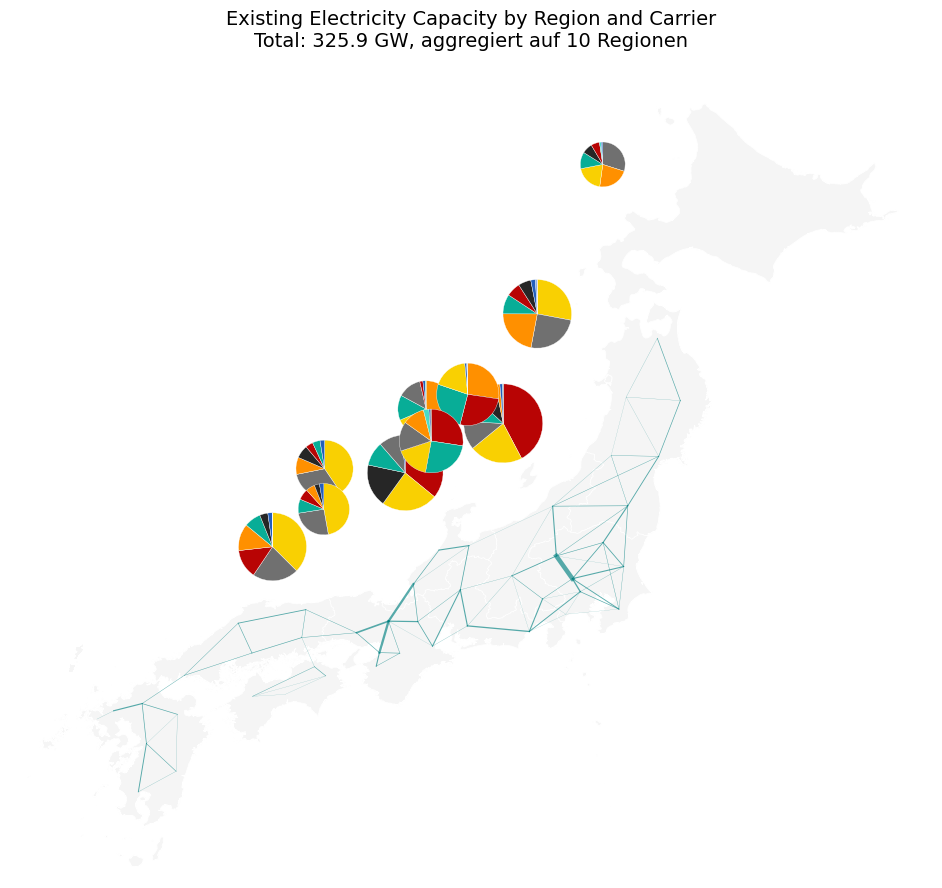

In [48]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import fiona
import warnings

warnings.simplefilter(action="ignore", category=UserWarning)


# ============================================================
# Settings
# ============================================================

# Existing/current capacities, wie in deinem ursprünglichen Code
capacity_mode = "current"

electric_bus_carriers = ["AC", "DC", "low voltage"]

# ------------------------------------------------------------
# GADM / Aggregation
# ------------------------------------------------------------

aggregate_to_coarse_regions = True

# 10-Regionen-GPKG
coarse_gadm_path = (
    "/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/data/gadm/gadm41_JPN/old/OUTPUT.gpkg"
)

# Simulations-GPKG
fine_gadm_path = (
    "/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/data/gadm/gadm41_JPN/gadm41_JPN.gpkg"
)

# 1 = 47 Regionen
simulation_gadm_level = 1

# Grobe Darstellungsebene: 10 Regionen
coarse_gadm_level = 1

# Im 10er-GPKG ist NAME_1 die grobe Region
coarse_region_id_col = "NAME_1"

# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------

# Größerer Wert = kleinere Kreisdiagramme
pie_scale = 0.100

# Mindest- und Maximalgröße der Pies als Anteil der Achsenbreite
pie_size_min = 0.035
pie_size_max = 0.120

# Linien
plot_network_lines = True
plot_network_links = False

line_scale = 1.5e4
line_sizes = [1000, 10000]  # MW

# Legend sizes in MW
pie_legend_sizes = [1000, 10000]  # 1 GW and 10 GW

# Hydro und PHS zusammenfassen
merge_hydro_phs = True
combined_hydro_name = "hydro + PHS"

# Minimum capacity in MW for showing a carrier in the legend
min_capacity_threshold = 0

# Relevanter Kartenausschnitt Japan
map_extent = [128.0, 146.5, 30.0, 46.5]


# ============================================================
# Helper functions: GADM / GeoPackage
# ============================================================

def find_gadm_layer(gpkg_path, gadm_level):
    target = f"ADM_ADM_{gadm_level}"
    layers = fiona.listlayers(gpkg_path)

    matches = [
        layer for layer in layers
        if layer.endswith(target) or target in layer
    ]

    if not matches:
        raise ValueError(
            f"Kein Layer für {target} in {gpkg_path} gefunden. "
            f"Vorhandene Layer: {layers}"
        )

    return matches[0]


def read_gadm_layer(gpkg_path, gadm_level):
    layer = find_gadm_layer(gpkg_path, gadm_level)

    gdf = gpd.read_file(
        gpkg_path,
        layer=layer
    )

    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")

    return gdf.to_crs("EPSG:4326")


def infer_gadm_id_col(gdf, gadm_level):
    candidates = [
        "GADM_ID",
        f"GID_{gadm_level}",
        "GID_2",
        "GID_1",
        "region",
        "name",
        "Name",
        "NAME_2",
        "NAME_1",
    ]

    for col in candidates:
        if col in gdf.columns:
            return col

    raise ValueError(
        "Keine passende Regions-ID-Spalte gefunden. "
        f"Vorhandene Spalten: {list(gdf.columns)}"
    )


def sjoin_compat(left, right, how="left", predicate="within"):
    try:
        return gpd.sjoin(
            left,
            right,
            how=how,
            predicate=predicate
        )
    except TypeError:
        return gpd.sjoin(
            left,
            right,
            how=how,
            op=predicate
        )


def get_fine_to_coarse_mapping(
    fine_regions,
    coarse_regions,
    fine_region_col="region",
    coarse_region_col="coarse_region",
):
    fine = fine_regions.copy()
    coarse = coarse_regions.copy()

    if fine.crs is None:
        fine = fine.set_crs("EPSG:4326")

    if coarse.crs is None:
        coarse = coarse.set_crs("EPSG:4326")

    fine = fine.to_crs("EPSG:4326")
    coarse = coarse.to_crs("EPSG:4326")

    fine_points = fine[[fine_region_col, "geometry"]].copy()
    fine_points["geometry"] = fine_points.geometry.representative_point()

    mapping = sjoin_compat(
        fine_points,
        coarse[[coarse_region_col, "geometry"]],
        how="left",
        predicate="within"
    )

    mapping = mapping[[fine_region_col, coarse_region_col]].drop_duplicates()

    missing = mapping[mapping[coarse_region_col].isna()]

    if not missing.empty:
        print("Warnung: Einige feine Regionen konnten keiner groben Region zugeordnet werden:")
        print(missing[fine_region_col].tolist())

    mapping = mapping.dropna(subset=[coarse_region_col])

    return mapping


# ============================================================
# Helper functions: PyPSA
# ============================================================

def get_capacity(df, nominal_col="p_nom", mode="current"):
    if mode == "optimized":
        opt_col = f"{nominal_col}_opt"

        if opt_col in df.columns:
            capacity = df[opt_col].copy()

            if nominal_col in df.columns:
                capacity = capacity.fillna(df[nominal_col])

            return capacity.fillna(0)

    if nominal_col in df.columns:
        return df[nominal_col].fillna(0)

    return pd.Series(0, index=df.index)


def bus_to_region(bus_name):
    s = str(bus_name).strip()

    suffixes = [
        "_AC",
        "_DC",
        " AC",
        " DC",
        " low voltage",
        "_low voltage",
        " heat",
        "_heat",
        " gas",
        "_gas",
        " oil",
        "_oil",
        " coal",
        "_coal",
        " biomass",
        "_biomass",
        " H2",
        "_H2",
    ]

    changed = True

    while changed:
        changed = False

        for suffix in suffixes:
            if s.endswith(suffix):
                s = s[: -len(suffix)].strip()
                changed = True

    return s


def normalize_region_id(region_id):
    s = bus_to_region(region_id)

    if s.startswith("JPN."):
        s = "JP." + s[len("JPN."):]

    return s.strip()


def rename_carrier_name(carrier):
    carrier = str(carrier)

    if merge_hydro_phs and carrier.lower() in [
        "hydro",
        "phs",
        "pumped hydro storage",
    ]:
        return combined_hydro_name

    return carrier


def aggregate_to_coarse_capacity(capacity_by_region_carrier, mapping):
    """
    Aggregiert MultiIndex-Series region/carrier auf coarse_region/carrier.
    """
    if capacity_by_region_carrier.empty:
        return capacity_by_region_carrier

    df = (
        capacity_by_region_carrier
        .rename("capacity_MW")
        .reset_index()
    )

    df["region"] = df["region"].map(normalize_region_id)

    df = df.merge(
        mapping,
        on="region",
        how="left"
    )

    missing = df[df["coarse_region"].isna()]

    if not missing.empty:
        print("Warnung: Einige Kapazitätswerte konnten keiner groben Region zugeordnet werden:")
        print(missing[["region", "carrier", "capacity_MW"]].head(20))

    df = df.dropna(subset=["coarse_region"])

    result = (
        df
        .groupby(["coarse_region", "carrier"])["capacity_MW"]
        .sum()
    )

    result.index.names = ["region", "carrier"]

    return result


def get_carrier_color(carrier, carrier_table):
    if carrier in carrier_table.index:
        color = carrier_table.loc[carrier, "color"]

        if pd.notna(color) and str(color).strip() != "":
            return color

    return "#cccccc"


def get_carrier_nice_name(carrier, carrier_table):
    if carrier in carrier_table.index:
        nice_name = carrier_table.loc[carrier, "nice_name"]

        if pd.notna(nice_name) and str(nice_name).strip() != "":
            return nice_name

    return carrier


# ============================================================
# Helper functions: plotting pies
# ============================================================

def data_to_axes_fraction(ax, x, y):
    display = ax.transData.transform((x, y))
    ax_frac = ax.transAxes.inverted().transform(display)

    return ax_frac


def capacity_to_pie_size(total_capacity_MW, max_capacity_MW):
    if max_capacity_MW <= 0:
        return pie_size_min

    scaled = np.sqrt(total_capacity_MW / max_capacity_MW)

    return pie_size_min + scaled * (pie_size_max - pie_size_min)


def add_capacity_pies(
    ax,
    capacity_by_region_carrier,
    plot_regions,
    carrier_table,
    region_col="region",
):
    """
    Zeichnet Kreisdiagramme auf die aggregierten Regionen.
    """
    if capacity_by_region_carrier.empty:
        return

    capacity_df = (
        capacity_by_region_carrier
        .rename("capacity_MW")
        .reset_index()
    )

    region_totals = (
        capacity_df
        .groupby("region")["capacity_MW"]
        .sum()
    )

    max_capacity = region_totals.max()

    plot_points = plot_regions[[region_col, "geometry"]].copy()
    plot_points["point"] = plot_points.geometry.representative_point()
    plot_points["lon"] = plot_points["point"].x
    plot_points["lat"] = plot_points["point"].y

    for region, total_capacity in region_totals.items():
        if total_capacity <= 0:
            continue

        point_row = plot_points[plot_points[region_col] == region]

        if point_row.empty:
            continue

        lon = point_row.iloc[0]["lon"]
        lat = point_row.iloc[0]["lat"]

        x_ax, y_ax = data_to_axes_fraction(ax, lon, lat)

        size = capacity_to_pie_size(total_capacity, max_capacity)

        left = np.clip(x_ax - size / 2, 0.002, 1 - size - 0.002)
        bottom = np.clip(y_ax - size / 2, 0.002, 1 - size - 0.002)

        inset = ax.inset_axes(
            [left, bottom, size, size],
            transform=ax.transAxes
        )

        region_values = (
            capacity_df[capacity_df["region"] == region]
            .groupby("carrier")["capacity_MW"]
            .sum()
            .sort_values(ascending=False)
        )

        colors = [
            get_carrier_color(carrier, carrier_table)
            for carrier in region_values.index
        ]

        inset.pie(
            region_values.values,
            colors=colors,
            startangle=90,
            counterclock=False,
            wedgeprops={
                "linewidth": 0.25,
                "edgecolor": "white",
            }
        )

        inset.set_aspect("equal")
        inset.set_xticks([])
        inset.set_yticks([])
        inset.set_facecolor("none")


def draw_network_edges(ax, line_scale=1.5e4):
    """
    Zeichnet elektrische Linien und optional Links direkt über Buskoordinaten.
    """
    if plot_network_lines and hasattr(n, "lines") and len(n.lines) > 0:
        for _, row in n.lines.iterrows():
            bus0 = row.get("bus0")
            bus1 = row.get("bus1")

            if bus0 not in n.buses.index or bus1 not in n.buses.index:
                continue

            x0, y0 = n.buses.loc[bus0, ["x", "y"]]
            x1, y1 = n.buses.loc[bus1, ["x", "y"]]

            width = row.get("s_nom", 0)

            if pd.isna(width) or width <= 0:
                continue

            ax.plot(
                [x0, x1],
                [y0, y1],
                color="teal",
                linewidth=max(width / line_scale, 0.1),
                alpha=0.65,
                transform=ccrs.PlateCarree(),
                zorder=1
            )

    if plot_network_links and hasattr(n, "links") and len(n.links) > 0:
        for _, row in n.links.iterrows():
            bus0 = row.get("bus0")
            bus1 = row.get("bus1")

            if bus0 not in n.buses.index or bus1 not in n.buses.index:
                continue

            x0, y0 = n.buses.loc[bus0, ["x", "y"]]
            x1, y1 = n.buses.loc[bus1, ["x", "y"]]

            width = row.get("p_nom", 0)

            if pd.isna(width) or width <= 0:
                continue

            ax.plot(
                [x0, x1],
                [y0, y1],
                color="teal",
                linewidth=max(width / line_scale, 0.1),
                alpha=0.45,
                transform=ccrs.PlateCarree(),
                zorder=1
            )


# ============================================================
# Backup carrier table
# ============================================================

carriers_backup = n.carriers.copy()

if merge_hydro_phs and combined_hydro_name not in n.carriers.index:
    n.carriers.loc[combined_hydro_name, :] = np.nan

    if "hydro" in n.carriers.index:
        n.carriers.loc[combined_hydro_name, "color"] = n.carriers.loc["hydro", "color"]
    elif "PHS" in n.carriers.index:
        n.carriers.loc[combined_hydro_name, "color"] = n.carriers.loc["PHS", "color"]
    else:
        n.carriers.loc[combined_hydro_name, "color"] = "#1f77b4"

    n.carriers.loc[combined_hydro_name, "nice_name"] = "Hydro + PHS"


# ============================================================
# 1) Prepare fine and coarse regions
# ============================================================

fine_regions = read_gadm_layer(
    fine_gadm_path,
    simulation_gadm_level
)

fine_region_id_col = infer_gadm_id_col(
    fine_regions,
    simulation_gadm_level
)

fine_regions["region"] = (
    fine_regions[fine_region_id_col]
    .astype(str)
    .map(normalize_region_id)
)

if aggregate_to_coarse_regions:
    coarse_regions = read_gadm_layer(
        coarse_gadm_path,
        coarse_gadm_level
    )

    if coarse_region_id_col not in coarse_regions.columns:
        raise ValueError(
            f"Die Spalte {coarse_region_id_col} wurde im groben GADM-Layer nicht gefunden. "
            f"Vorhandene Spalten: {list(coarse_regions.columns)}"
        )

    coarse_regions["coarse_region"] = (
        coarse_regions[coarse_region_id_col]
        .astype(str)
        .str.strip()
    )

    fine_to_coarse = get_fine_to_coarse_mapping(
        fine_regions=fine_regions,
        coarse_regions=coarse_regions,
        fine_region_col="region",
        coarse_region_col="coarse_region",
    )

    plot_regions = coarse_regions.copy()
    plot_regions["region"] = plot_regions["coarse_region"]

else:
    plot_regions = fine_regions.copy()


# ============================================================
# 2) Existing generator capacities
# ============================================================

generators = n.generators.copy()

generators = generators[
    ~generators.carrier.astype(str).str.contains("load", case=False, na=False)
].copy()

generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

generators = generators[
    generators["bus_carrier"].isin(electric_bus_carriers)
].copy()

generators["region"] = generators.bus.map(normalize_region_id)
generators["carrier_plot"] = generators.carrier.map(rename_carrier_name)

generator_capacity_by_region_carrier = (
    generators
    .assign(capacity_MW=generators["p_nom"].fillna(0))
    .groupby(["region", "carrier_plot"])["capacity_MW"]
    .sum()
)

generator_capacity_by_region_carrier.index.names = ["region", "carrier"]


# ============================================================
# 3) Existing storage unit power capacities
# ============================================================

storage_units = n.storage_units.copy()

storage_units = storage_units[
    storage_units["p_nom"].fillna(0) > 0
].copy()

storage_units["bus_carrier"] = storage_units.bus.map(n.buses.carrier)

storage_units = storage_units[
    storage_units["bus_carrier"].isin(electric_bus_carriers)
].copy()

storage_units["region"] = storage_units.bus.map(normalize_region_id)
storage_units["carrier_plot"] = storage_units.carrier.map(rename_carrier_name)

storage_capacity_by_region_carrier = (
    storage_units
    .assign(capacity_MW=storage_units["p_nom"].fillna(0))
    .groupby(["region", "carrier_plot"])["capacity_MW"]
    .sum()
)

storage_capacity_by_region_carrier.index.names = ["region", "carrier"]


# ============================================================
# 4) Existing electricity-producing link capacities
# ============================================================

links = n.links.copy()

links = links[
    links["p_nom"].fillna(0) > 0
].copy()

link_capacity_parts = []

for bus_number in range(1, 6):
    bus_col = f"bus{bus_number}"

    if bus_col not in links.columns:
        continue

    if bus_number == 1:
        efficiency_col = "efficiency"
    else:
        efficiency_col = f"efficiency{bus_number}"

    output_bus_carrier = links[bus_col].map(n.buses.carrier)
    input_bus_carrier = links["bus0"].map(n.buses.carrier)

    mask = (
        output_bus_carrier.isin(electric_bus_carriers)
        & ~input_bus_carrier.isin(electric_bus_carriers)
    )

    if not mask.any():
        continue

    selected_links = links.loc[mask].copy()

    if efficiency_col in links.columns:
        if bus_number == 1:
            efficiency = links.loc[mask, efficiency_col].fillna(1)
        else:
            efficiency = links.loc[mask, efficiency_col].fillna(0)
    else:
        efficiency = 1 if bus_number == 1 else 0

    selected_links["capacity_MW"] = (
        selected_links["p_nom"].fillna(0)
        * efficiency
    )

    selected_links["region"] = selected_links[bus_col].map(normalize_region_id)
    selected_links["carrier_plot"] = selected_links.carrier.map(rename_carrier_name)

    tmp = (
        selected_links
        .groupby(["region", "carrier_plot"])["capacity_MW"]
        .sum()
    )

    tmp.index.names = ["region", "carrier"]
    link_capacity_parts.append(tmp)


if link_capacity_parts:
    link_capacity_by_region_carrier = (
        pd.concat(link_capacity_parts)
        .groupby(level=["region", "carrier"])
        .sum()
    )
else:
    link_capacity_by_region_carrier = pd.Series(
        dtype=float,
        index=pd.MultiIndex.from_tuples([], names=["region", "carrier"])
    )


# ============================================================
# 5) Combine all capacities on fine regions
# ============================================================

capacity_by_region_carrier = (
    pd.concat(
        [
            generator_capacity_by_region_carrier,
            storage_capacity_by_region_carrier,
            link_capacity_by_region_carrier,
        ]
    )
    .groupby(level=["region", "carrier"])
    .sum()
)

capacity_by_region_carrier = capacity_by_region_carrier[
    capacity_by_region_carrier > 0
]

capacity_by_region_carrier = capacity_by_region_carrier[
    capacity_by_region_carrier.index.get_level_values("carrier").str.lower() != "v2g"
]


# ============================================================
# 6) Aggregate to coarse regions for display
# ============================================================

if aggregate_to_coarse_regions:
    capacity_for_plot = aggregate_to_coarse_capacity(
        capacity_by_region_carrier,
        fine_to_coarse
    )
else:
    capacity_for_plot = capacity_by_region_carrier.copy()


capacity_for_plot = capacity_for_plot[
    capacity_for_plot > 0
]

total_capacity_GW = capacity_for_plot.sum() / 1e3

print("------------------------------------------------------------")
print("Existing electricity capacity map")
print("------------------------------------------------------------")
print(f"Aggregation auf 10 Regionen: {aggregate_to_coarse_regions}")
print(f"Total existing electricity capacity shown on map: {total_capacity_GW:.1f} GW")

print("")
print("Kapazitäten nach Region [GW]:")
display(
    capacity_for_plot
    .groupby(level="region")
    .sum()
    .div(1e3)
    .sort_values(ascending=False)
    .to_frame("capacity_GW")
)

print("")
print("Kapazitäten nach Carrier [GW]:")
display(
    capacity_for_plot
    .groupby(level="carrier")
    .sum()
    .div(1e3)
    .sort_values(ascending=False)
    .to_frame("capacity_GW")
)


# ============================================================
# 7) Make sure all plotted carriers have colors
# ============================================================

for carrier in capacity_for_plot.index.get_level_values("carrier").unique():
    if carrier not in n.carriers.index:
        n.carriers.loc[carrier, :] = np.nan
        n.carriers.loc[carrier, "nice_name"] = carrier
        n.carriers.loc[carrier, "color"] = "#cccccc"

    if pd.isna(n.carriers.loc[carrier, "color"]) or n.carriers.loc[carrier, "color"] == "":
        n.carriers.loc[carrier, "color"] = "#cccccc"

    if pd.isna(n.carriers.loc[carrier, "nice_name"]) or n.carriers.loc[carrier, "nice_name"] == "":
        n.carriers.loc[carrier, "nice_name"] = carrier


# ============================================================
# 8) Plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 12),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

plot_regions.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0.5,
    zorder=0,
)

draw_network_edges(
    ax=ax,
    line_scale=line_scale
)

# Wichtig: Canvas zuerst zeichnen, damit inset-Koordinaten stimmen
fig.canvas.draw()

add_capacity_pies(
    ax=ax,
    capacity_by_region_carrier=capacity_for_plot,
    plot_regions=plot_regions,
    carrier_table=n.carriers,
    region_col="region",
)

ax.set_extent(
    map_extent,
    crs=ccrs.PlateCarree()
)

if aggregate_to_coarse_regions:
    region_text = "aggregiert auf 10 Regionen"
else:
    region_text = f"GADM-Level {simulation_gadm_level}"

ax.set_title(
    f"Existing Electricity Capacity by Region and Carrier\n"
    f"Total: {total_capacity_GW:.1f} GW, {region_text}",
    fontsize=14
)

ax.axis("off")


# ============================================================
# 9) Legends
# ============================================================

# Linienlegende
line_handles = [
    Line2D(
        [0],
        [0],
        color="teal",
        linewidth=max(s / line_scale, 0.1),
        label=f"{s / 1000:.0f} GW"
    )
    for s in line_sizes
]

if plot_network_lines:
    line_legend = ax.legend(
        handles=line_handles,
        title="Transmission",
        loc="upper left",
        bbox_to_anchor=(1.02, 0.90),
        frameon=False,
    )
    ax.add_artist(line_legend)


# Pie-Größenlegende
region_totals = capacity_for_plot.groupby(level="region").sum()
max_capacity_MW = region_totals.max() if not region_totals.empty else 1

pie_size_handles = []

for s in pie_legend_sizes:
    size = capacity_to_pie_size(s, max_capacity_MW)
    markersize = size * 220

    pie_size_handles.append(
        Line2D(
            [0],
            [0],
            marker="o",
            color="black",
            markerfacecolor="none",
            markersize=markersize,
            linewidth=0,
            label=f"{s / 1000:.0f} GW"
        )
    )

pie_legend = ax.legend(
    handles=pie_size_handles,
    title="Capacity",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.72),
    frameon=False,
    labelspacing=1.8,
)

ax.add_artist(pie_legend)


# Carrier-Legende
carrier_totals = (
    capacity_for_plot
    .groupby(level="carrier")
    .sum()
    .sort_values(ascending=False)
)

carrier_totals = carrier_totals[
    carrier_totals > min_capacity_threshold
]

carrier_handles = []

for carrier, value in carrier_totals.items():
    color = get_carrier_color(carrier, n.carriers)
    name = get_carrier_nice_name(carrier, n.carriers)

    carrier_handles.append(
        mpatches.Patch(
            facecolor=color,
            edgecolor="black",
            label=f"{name} ({value / 1e3:.1f} GW)"
        )
    )

carrier_legend = ax.legend(
    handles=carrier_handles,
    title="Carrier",
    loc="lower left",
    bbox_to_anchor=(1.02, 0.02),
    frameon=False,
)

ax.add_artist(carrier_legend)

fig.subplots_adjust(right=0.74)
plt.show()


# ============================================================
# 10) Restore original carrier table
# ============================================================

n.carriers = carriers_backup

warnings.simplefilter(action="default", category=UserWarning)

Analyse the current generation capacity of the energy system - pie chart view

Total existing electricity capacity: 325.9 GW


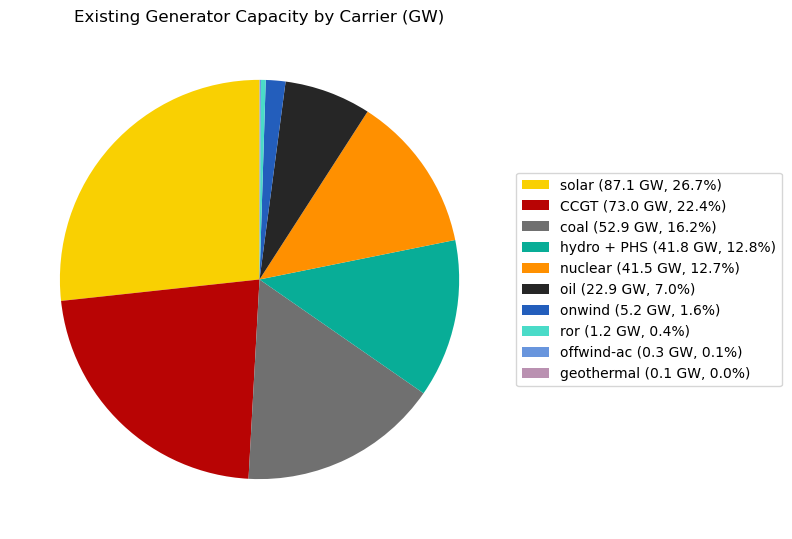

Total existing generator capacity: 325.9 GW


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Existing generator capacities from n.generators
# ------------------------------------------------------------
generators = n.generators.copy()

generator_capacity_by_carrier = (
    generators[
        ~generators.carrier.astype(str).str.contains("load", case=False, na=False)
    ]
    .groupby("carrier")
    .p_nom
    .sum()
)


# ------------------------------------------------------------
# 2) Existing fossil power plant capacities from n.links
# ------------------------------------------------------------
links = n.links.copy()

# Fossil technologies that are commonly stored as links in PyPSA-Earth
fossil_pattern = (
    "coal|lignite|gas|oil|diesel|kerosene|naphta|"
    "CCGT|OCGT|CHP|solid biomass"
)

# Keep only fossil conversion links
fossil_links = links[
    links.carrier.astype(str).str.contains(
        fossil_pattern,
        case=False,
        regex=True,
        na=False
    )
].copy()

# Keep only links that produce electricity on bus1
# In PyPSA links, bus1 is normally multiplied by "efficiency"
fossil_links["bus1_carrier"] = fossil_links.bus1.map(n.buses.carrier)

fossil_links = fossil_links[
    fossil_links["bus1_carrier"].isin(["AC", "DC", "low voltage"])
].copy()

# Convert fuel/input capacity to electric output capacity
fossil_links["electric_capacity"] = (
    fossil_links["p_nom"].fillna(0)
    * fossil_links["efficiency"].fillna(1)
)

link_capacity_by_carrier = (
    fossil_links
    .groupby("carrier")
    .electric_capacity
    .sum()
)

# ------------------------------------------------------------
# 2b) Existing storage unit power capacities
# ------------------------------------------------------------
storage_units = n.storage_units.copy()

# Keep only existing/current storage units
storage_units = storage_units[
    storage_units["p_nom"].fillna(0) > 0
].copy()

# Optional: keep only storage units connected to electricity buses
storage_units["bus_carrier"] = storage_units.bus.map(n.buses.carrier)

storage_units = storage_units[
    storage_units["bus_carrier"].isin(["AC", "DC", "low voltage"])
].copy()

storage_unit_capacity_by_carrier = (
    storage_units
    .groupby("carrier")
    .p_nom
    .sum()
)

# ------------------------------------------------------------
# 3) Combine generators, fossil links and storage units
# ------------------------------------------------------------
capacity_by_carrier = pd.concat(
    [
        generator_capacity_by_carrier,
        link_capacity_by_carrier,
        storage_unit_capacity_by_carrier
    ],
    axis=0
)

# Merge PHS and hydro into one category
capacity_by_carrier.index = capacity_by_carrier.index.to_series().replace({
    "PHS": "hydro + PHS",
    "phs": "hydro + PHS",
    "hydro": "hydro + PHS",
    "Hydro": "hydro + PHS"
})

capacity_by_carrier = (
    capacity_by_carrier
    .groupby(level=0)
    .sum()
    .div(1e3)  # MW to GW
    .sort_values(ascending=False)
)

# Keep only entries > 0
capacity_by_carrier = capacity_by_carrier[capacity_by_carrier > 0]

total_capacity_GW = capacity_by_carrier.sum()

print(f"Total existing electricity capacity: {total_capacity_GW:.1f} GW")


# ------------------------------------------------------------
# 4) Plot
# ------------------------------------------------------------
carrier_colors = (
    n.carriers["color"]
    .reindex(capacity_by_carrier.index)
    .replace("", np.nan)
)

# Use hydro color also for combined hydro + PHS category
if "hydro + PHS" in carrier_colors.index:
    if "hydro" in n.carriers.index:
        carrier_colors.loc["hydro + PHS"] = n.carriers.loc["hydro", "color"]
    elif "PHS" in n.carriers.index:
        carrier_colors.loc["hydro + PHS"] = n.carriers.loc["PHS", "color"]

colors = carrier_colors.fillna("#cccccc")

plt.figure(figsize=(8, 8))

wedges, _ = plt.pie(
    capacity_by_carrier,
    labels=None,
    startangle=90,
    colors=colors
)

labels = [
    f"{carrier} ({capacity:.1f} GW, "
    f"{100 * capacity / capacity_by_carrier.sum():.1f}%)"
    for carrier, capacity in capacity_by_carrier.items()
]

plt.legend(
    wedges,
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title("Existing Generator Capacity by Carrier (GW)")
plt.tight_layout()
plt.show()

total_capacity_GW = capacity_by_carrier.sum()

print(f"Total existing generator capacity: {total_capacity_GW:.1f} GW")

Total selected installed electricity capacity: 954.9 GW


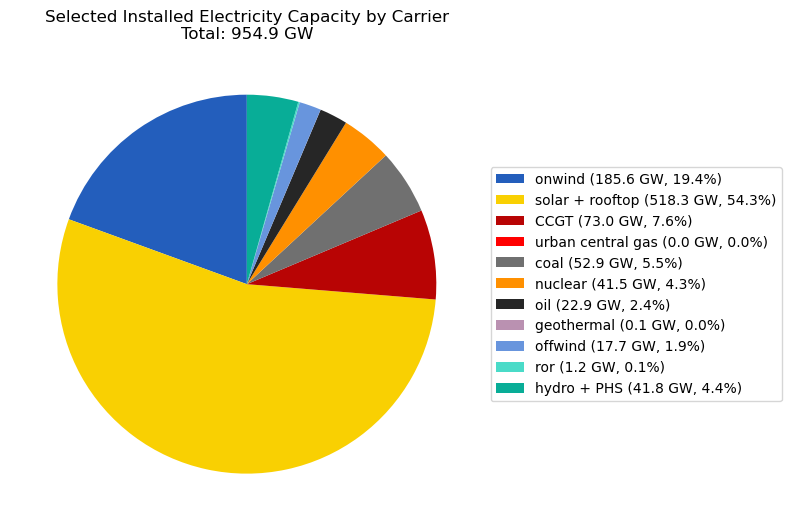

,capacity_GW
carrier,
onwind,185.619030
solar + rooftop,518.253064
CCGT,73.019808
urban central gas,0.000022
coal,52.877324
nuclear,41.482131
oil,22.859756
geothermal,0.066400
offwind,17.732975


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
electric_bus_carriers = ["AC", "DC", "low voltage"]

allowed_carriers_order = [
    "onwind",
    "solar + rooftop",
    "CCGT",
    "urban central gas",
    "coal",
    "nuclear",
    "oil",
    "geothermal",
    "offwind",
    "ror",
    "hydro + PHS",
]

# ------------------------------------------------------------
# Helper: get final optimized capacity
# ------------------------------------------------------------
def get_nominal_capacity(df, nominal_col="p_nom"):
    """
    Returns the final nominal capacity.
    Prefer p_nom_opt if available, otherwise fall back to p_nom.
    """
    opt_col = f"{nominal_col}_opt"

    if opt_col in df.columns:
        capacity = df[opt_col].copy()

        if nominal_col in df.columns:
            capacity = capacity.fillna(df[nominal_col])

        return capacity.fillna(0)

    if nominal_col in df.columns:
        return df[nominal_col].fillna(0)

    return pd.Series(0, index=df.index)


# ------------------------------------------------------------
# Helper: map detailed PyPSA carriers to selected display carriers
# ------------------------------------------------------------
def map_carrier(carrier):
    carrier_str = str(carrier)
    carrier_low = carrier_str.lower()

    # Solar
    if carrier_low in ["solar", "solar rooftop", "solar-rooftop"]:
        return "solar + rooftop"

    # Offshore wind
    if carrier_low.startswith("offwind"):
        return "offwind"

    # Hydro and pumped hydro storage
    if carrier_low in ["hydro", "phs", "pumped hydro storage"]:
        return "hydro + PHS"

    # Run-of-river
    if carrier_low in ["ror", "run of river", "run-of-river"]:
        return "ror"

    # Onshore wind
    if carrier_low == "onwind":
        return "onwind"

    # Fossil and nuclear technologies
    if carrier_low == "ccgt":
        return "CCGT"

    if carrier_low == "coal":
        return "coal"

    if carrier_low == "oil":
        return "oil"

    if carrier_low == "nuclear":
        return "nuclear"

    # Geothermal
    if "geothermal" in carrier_low:
        return "geothermal"

    # Urban central gas technologies, e.g. urban central gas CHP
    if "urban central gas" in carrier_low:
        return "urban central gas"

    return carrier_str


def aggregate_and_filter(series):
    """
    Map carriers, aggregate them, and keep only selected carriers.
    Input must be a Series indexed by carrier.
    """
    if series.empty:
        return pd.Series(dtype=float)

    series = series.copy()
    series.index = series.index.to_series().map(map_carrier)

    series = (
        series
        .groupby(level=0)
        .sum()
    )

    series = series[series.index.isin(allowed_carriers_order)]

    return series


# ------------------------------------------------------------
# 1) Generator capacities connected to electricity buses
# ------------------------------------------------------------
generators = n.generators.copy()

generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

generators = generators[
    ~generators.carrier.astype(str).str.contains("load", case=False, na=False)
    & generators["bus_carrier"].isin(electric_bus_carriers)
].copy()

generators["capacity_MW"] = get_nominal_capacity(generators, "p_nom")

generator_capacity_by_carrier = (
    generators
    .groupby("carrier")["capacity_MW"]
    .sum()
)

generator_capacity_by_carrier = aggregate_and_filter(generator_capacity_by_carrier)


# ------------------------------------------------------------
# 2) Electricity-producing link capacities
# ------------------------------------------------------------
links = n.links.copy()

links["p_nom_final"] = get_nominal_capacity(links, "p_nom")

# Only technologies requested for this chart
generation_link_pattern = (
    "coal|gas|oil|CCGT|urban central gas|geothermal"
)

links["is_selected_generation_link"] = links.carrier.astype(str).str.contains(
    generation_link_pattern,
    case=False,
    regex=True,
    na=False
)

link_capacity_parts = []

# In PyPSA links:
# p_nom is input capacity.
# Electrical output capacity on bus1 = p_nom * efficiency
# Electrical output capacity on bus2 = p_nom * efficiency2
# etc.
for bus_number in range(1, 6):
    bus_col = f"bus{bus_number}"

    if bus_col not in links.columns:
        continue

    if bus_number == 1:
        efficiency_col = "efficiency"
    else:
        efficiency_col = f"efficiency{bus_number}"

    output_bus_carrier = links[bus_col].map(n.buses.carrier)
    input_bus_carrier = links["bus0"].map(n.buses.carrier)

    mask = (
        links["is_selected_generation_link"]
        & output_bus_carrier.isin(electric_bus_carriers)
        & ~input_bus_carrier.isin(electric_bus_carriers)
    )

    if not mask.any():
        continue

    tmp = links.loc[mask, ["carrier", "p_nom_final"]].copy()

    if efficiency_col in links.columns:
        if bus_number == 1:
            tmp["efficiency_factor"] = links.loc[mask, efficiency_col].fillna(1)
        else:
            tmp["efficiency_factor"] = links.loc[mask, efficiency_col].fillna(0)
    else:
        tmp["efficiency_factor"] = 1 if bus_number == 1 else 0

    # Convert input capacity to electrical output capacity
    tmp["capacity_MW"] = tmp["p_nom_final"] * tmp["efficiency_factor"]

    link_capacity_parts.append(tmp[["carrier", "capacity_MW"]])


if link_capacity_parts:
    link_capacity_by_carrier = (
        pd.concat(link_capacity_parts)
        .groupby("carrier")["capacity_MW"]
        .sum()
    )
else:
    link_capacity_by_carrier = pd.Series(dtype=float)

link_capacity_by_carrier = aggregate_and_filter(link_capacity_by_carrier)


# ------------------------------------------------------------
# 3) Storage unit power capacities
# ------------------------------------------------------------
storage_units = n.storage_units.copy()

storage_units["bus_carrier"] = storage_units.bus.map(n.buses.carrier)

storage_units = storage_units[
    storage_units["bus_carrier"].isin(electric_bus_carriers)
].copy()

storage_units["capacity_MW"] = get_nominal_capacity(storage_units, "p_nom")

storage_unit_capacity_by_carrier = (
    storage_units
    .groupby("carrier")["capacity_MW"]
    .sum()
)

storage_unit_capacity_by_carrier = aggregate_and_filter(storage_unit_capacity_by_carrier)


# ------------------------------------------------------------
# 4) Combine generators, links and storage units
# ------------------------------------------------------------
capacity_by_carrier = (
    pd.concat(
        [
            generator_capacity_by_carrier,
            link_capacity_by_carrier,
            storage_unit_capacity_by_carrier,
        ],
        axis=0
    )
    .groupby(level=0)
    .sum()
)

# Keep only selected carriers and sort by chosen order
capacity_by_carrier = capacity_by_carrier[
    capacity_by_carrier.index.isin(allowed_carriers_order)
]

capacity_by_carrier = capacity_by_carrier.reindex(allowed_carriers_order).fillna(0)

# Convert MW to GW
capacity_by_carrier = capacity_by_carrier.div(1e3)

# Keep only positive capacities
capacity_by_carrier = capacity_by_carrier[capacity_by_carrier > 0]

total_capacity_GW = capacity_by_carrier.sum()

print(f"Total selected installed electricity capacity: {total_capacity_GW:.1f} GW")


# ------------------------------------------------------------
# 5) Colors
# ------------------------------------------------------------
color_source = {
    "onwind": "onwind",
    "solar + rooftop": "solar",
    "CCGT": "CCGT",
    "urban central gas": "urban central gas CHP",
    "coal": "coal",
    "nuclear": "nuclear",
    "oil": "oil",
    "geothermal": "geothermal",
    "offwind": "offwind-ac",
    "ror": "ror",
    "hydro + PHS": "hydro",
}

carrier_colors = []

for carrier in capacity_by_carrier.index:
    source_carrier = color_source.get(carrier, carrier)

    if source_carrier in n.carriers.index:
        color = n.carriers.loc[source_carrier, "color"]
    elif carrier in n.carriers.index:
        color = n.carriers.loc[carrier, "color"]
    else:
        color = "#cccccc"

    if pd.isna(color) or color == "":
        color = "#cccccc"

    carrier_colors.append(color)


# ------------------------------------------------------------
# 6) Plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 8))

wedges, _ = plt.pie(
    capacity_by_carrier,
    labels=None,
    startangle=90,
    colors=carrier_colors
)

labels = [
    f"{carrier} ({capacity:.1f} GW, "
    f"{100 * capacity / capacity_by_carrier.sum():.1f}%)"
    for carrier, capacity in capacity_by_carrier.items()
]

plt.legend(
    wedges,
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title(
    f"Selected Installed Electricity Capacity by Carrier\n"
    f"Total: {total_capacity_GW:.1f} GW"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7) Optional table output
# ------------------------------------------------------------
capacity_by_carrier.to_frame("capacity_GW")

Analyse the current gernation capacity of the energy system - tabular view

In [51]:
generator_capacity_by_carrier

carrier
geothermal             66.400000
nuclear             41482.131091
offwind             17732.974664
onwind             185619.029706
ror                  1235.000000
solar + rooftop    518253.064322
Name: capacity_MW, dtype: float64

Analyse the future capacity of the energy system - map view

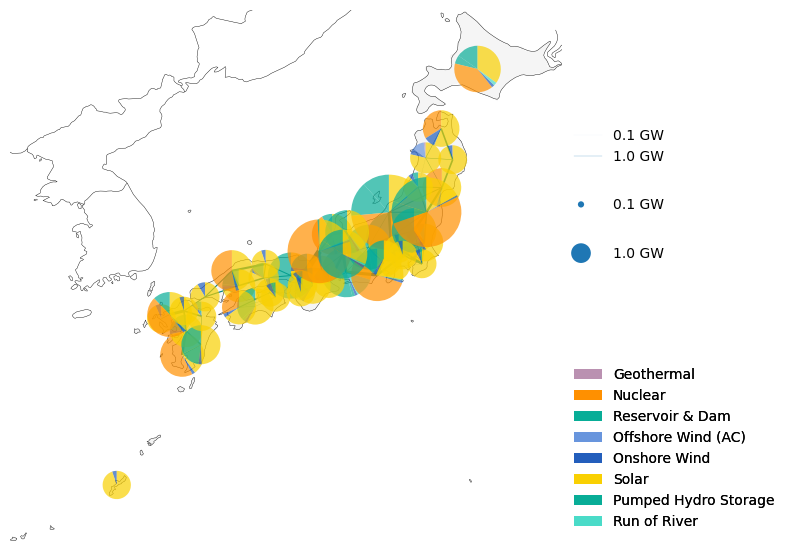

In [52]:
warnings.simplefilter(action='ignore', category=UserWarning)

# --- Scale settings ---
bus_scale = 6e3
line_scale = 6e3

# --- Legend settings ---
bus_sizes = [100, 1000]   # in MW
line_sizes = [100, 1000]  # in MW

# --- Remove "Load" carrier for plotting ---
if "Load" in n.carriers.index:
    n.carriers.drop("Load", inplace=True)

# --------------------------------------------------
# Nur AC-Busse verwenden
# --------------------------------------------------
ac_buses = n.buses.index[n.buses.carrier.eq("AC")]

# --------------------------------------------------
# Generatoren aggregieren
# - keine "load"-Carrier
# - kein "geothermal heat"
# - nur Generatoren an AC-Bussen
# --------------------------------------------------
gen = (
    n.generators[
        ~n.generators.carrier.str.contains("load", case=False, na=False)
        & ~n.generators.carrier.isin(["geothermal heat"])
        & n.generators.bus.isin(ac_buses)
    ]
    .groupby(["bus", "carrier"])
    .p_nom.sum()
)

# --------------------------------------------------
# Storage Units aggregieren
# - nur an AC-Bussen
# --------------------------------------------------
sto = (
    n.storage_units[
        n.storage_units.bus.isin(ac_buses)
    ]
    .groupby(["bus", "carrier"])
    .p_nom.sum()
)

# --------------------------------------------------
# Busdaten zusammenführen
# --------------------------------------------------
buses = pd.concat([gen, sto]).groupby(level=[0, 1]).sum()

# --------------------------------------------------
# Fehlende oder leere Farben für verwendete Carrier abfangen
# --------------------------------------------------
used_carriers = buses.index.get_level_values("carrier").unique()

for c in used_carriers:
    if c not in n.carriers.index:
        continue
    if "color" not in n.carriers.columns:
        continue
    color = n.carriers.loc[c, "color"]
    if pd.isna(color) or str(color).strip() == "":
        n.carriers.loc[c, "color"] = "lightgray"

# --------------------------------------------------
# Plotting
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.PlateCarree()})

# --- Filter Links: only those that lie within GADM regions ---
link_bus0_base = n.links.bus0.str.split("_AC").str[0]
link_bus1_base = n.links.bus1.str.split("_AC").str[0]

valid_links = n.links[
    link_bus0_base.isin(gadm_shapes.index) &
    link_bus1_base.isin(gadm_shapes.index) &
    (n.links.p_nom > 0)
]

# overwrite temporarily for the plot
links_backup = n.links
n.links = valid_links

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom / line_scale,
        link_widths=n.links.p_nom / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )

country_shape.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)

# Set map extent
ax.set_extent(country_shape.total_bounds[[0, 2, 1, 3]])

# --- Add legends ---
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,
)

add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)

# --- Create patch legend for carriers (unique nice_name, non-zero capacity) ---
colors_legend = []
labels_legend = []
seen = set()

min_capacity_threshold = 50

for c in n.carriers.index:
    name = n.carriers.loc[c, "nice_name"] if "nice_name" in n.carriers.columns else c
    color = n.carriers.loc[c, "color"] if "color" in n.carriers.columns else "lightgray"

    if c in buses.index.get_level_values("carrier"):
        val_total = buses.xs(c, level="carrier").sum()
    else:
        val_total = 0

    if pd.isna(color) or str(color).strip() == "":
        color = "lightgray"

    if name not in seen and val_total > min_capacity_threshold:
        seen.add(name)
        colors_legend.append(color)
        labels_legend.append(name)

add_legend_patches(
    ax,
    colors_legend,
    labels_legend,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc": "lower left"},
)

fig.tight_layout()
plt.show()

# Restore original links
n.links = links_backup
warnings.simplefilter(action='default', category=UserWarning)

Analys the future generation capacity expansion of the energy system - bar chart

Total electricity capacity expansion: 644.77 GW


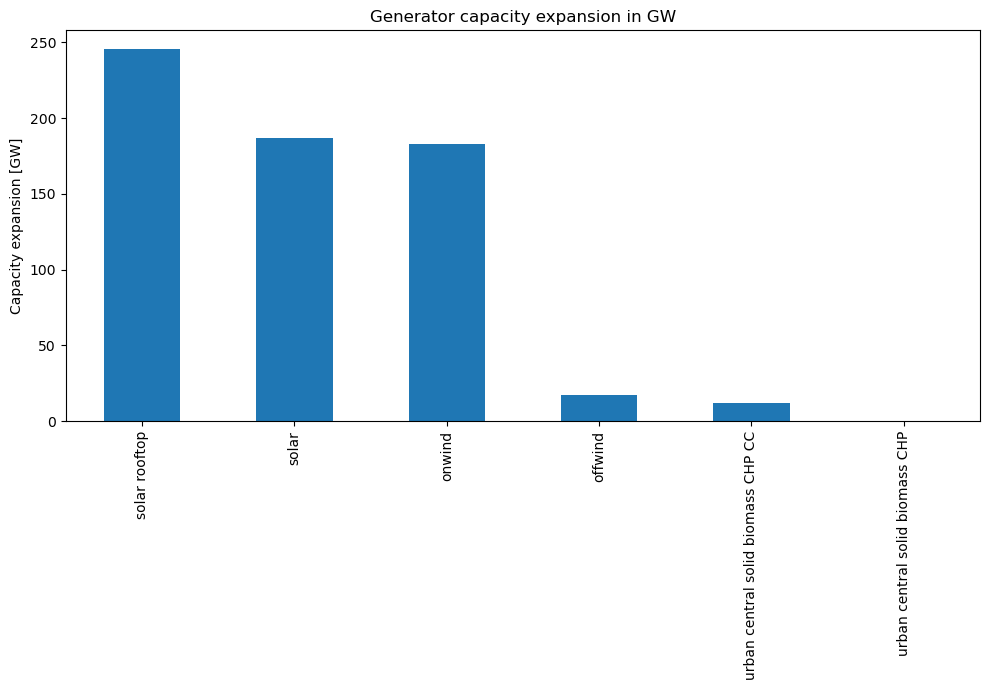

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
electric_bus_carriers = ["AC", "DC", "low voltage"]

# Minimum expansion shown in the plot [GW]
min_expansion_GW = 0.001

# Optional carrier grouping
merge_solar_rooftop = False
merge_hydro_phs = True
merge_offwind = True


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def get_capacity(df, column="p_nom"):
    """
    Return capacity column if it exists, otherwise zero.
    """
    if column in df.columns:
        return df[column].fillna(0)
    return pd.Series(0, index=df.index)


def map_carrier(carrier):
    """
    Map detailed carriers to grouped display names.
    """
    carrier_str = str(carrier)
    carrier_low = carrier_str.lower()

    if merge_solar_rooftop:
        if carrier_low in ["solar", "solar rooftop", "solar-rooftop"]:
            return "solar + rooftop"

    if merge_hydro_phs:
        if carrier_low in ["hydro", "phs", "pumped hydro storage"]:
            return "hydro + PHS"

    if merge_offwind:
        if carrier_low.startswith("offwind"):
            return "offwind"

    if "urban central gas" in carrier_low:
        return "urban central gas"

    if "geothermal" in carrier_low:
        return "geothermal"

    if carrier_low == "ccgt":
        return "CCGT"

    if carrier_low == "ocgt":
        return "OCGT"

    return carrier_str


def aggregate_expansion(series):
    """
    Map carrier names and aggregate expansion by carrier.
    """
    if series.empty:
        return pd.Series(dtype=float)

    series = series.copy()
    series.index = series.index.to_series().map(map_carrier)

    return series.groupby(level=0).sum()


# ------------------------------------------------------------
# 1) Generator capacity expansion
# ------------------------------------------------------------
generators = n.generators.copy()

generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

generators = generators[
    ~generators.carrier.astype(str).str.contains("load", case=False, na=False)
    & generators["bus_carrier"].isin(electric_bus_carriers)
].copy()

generators["installed_capacity_MW"] = get_capacity(generators, "p_nom")
generators["optimal_capacity_MW"] = get_capacity(generators, "p_nom_opt")

generators["capacity_expansion_MW"] = (
    generators["optimal_capacity_MW"]
    - generators["installed_capacity_MW"]
).clip(lower=0)

generator_expansion_by_carrier = (
    generators
    .groupby("carrier")["capacity_expansion_MW"]
    .sum()
)

generator_expansion_by_carrier = aggregate_expansion(generator_expansion_by_carrier)


# ------------------------------------------------------------
# 2) StorageUnit power capacity expansion
# ------------------------------------------------------------
storage_units = n.storage_units.copy()

storage_units["bus_carrier"] = storage_units.bus.map(n.buses.carrier)

storage_units = storage_units[
    storage_units["bus_carrier"].isin(electric_bus_carriers)
].copy()

storage_units["installed_capacity_MW"] = get_capacity(storage_units, "p_nom")
storage_units["optimal_capacity_MW"] = get_capacity(storage_units, "p_nom_opt")

storage_units["capacity_expansion_MW"] = (
    storage_units["optimal_capacity_MW"]
    - storage_units["installed_capacity_MW"]
).clip(lower=0)

storage_expansion_by_carrier = (
    storage_units
    .groupby("carrier")["capacity_expansion_MW"]
    .sum()
)

storage_expansion_by_carrier = aggregate_expansion(storage_expansion_by_carrier)


# ------------------------------------------------------------
# 3) Link electricity generation capacity expansion
# ------------------------------------------------------------
links = n.links.copy()

links["installed_capacity_MW"] = get_capacity(links, "p_nom")
links["optimal_capacity_MW"] = get_capacity(links, "p_nom_opt")
links["input_expansion_MW"] = (
    links["optimal_capacity_MW"]
    - links["installed_capacity_MW"]
).clip(lower=0)

link_expansion_parts = []

# In PyPSA links:
# p_nom is input-side capacity.
# Electrical output capacity on bus1 = p_nom * efficiency
# Electrical output capacity on bus2 = p_nom * efficiency2
# etc.
for bus_number in range(1, 6):
    bus_col = f"bus{bus_number}"

    if bus_col not in links.columns:
        continue

    if bus_number == 1:
        efficiency_col = "efficiency"
    else:
        efficiency_col = f"efficiency{bus_number}"

    output_bus_carrier = links[bus_col].map(n.buses.carrier)
    input_bus_carrier = links["bus0"].map(n.buses.carrier)

    # Count only links that produce electricity from a non-electric input.
    # This avoids counting grid links, transmission, chargers, etc.
    mask = (
        output_bus_carrier.isin(electric_bus_carriers)
        & ~input_bus_carrier.isin(electric_bus_carriers)
    )

    if not mask.any():
        continue

    selected_links = links.loc[mask].copy()

    if efficiency_col in links.columns:
        if bus_number == 1:
            efficiency = links.loc[mask, efficiency_col].fillna(1)
        else:
            efficiency = links.loc[mask, efficiency_col].fillna(0)
    else:
        efficiency = 1 if bus_number == 1 else 0

    selected_links["electric_expansion_MW"] = (
        selected_links["input_expansion_MW"]
        * efficiency
    )

    tmp = (
        selected_links
        .groupby("carrier")["electric_expansion_MW"]
        .sum()
    )

    link_expansion_parts.append(tmp)


if link_expansion_parts:
    link_expansion_by_carrier = (
        pd.concat(link_expansion_parts)
        .groupby(level=0)
        .sum()
    )
else:
    link_expansion_by_carrier = pd.Series(dtype=float)

link_expansion_by_carrier = aggregate_expansion(link_expansion_by_carrier)


# ------------------------------------------------------------
# 4) Combine all electricity capacity expansion
# ------------------------------------------------------------
capacity_expansion_by_carrier = (
    pd.concat(
        [
            generator_expansion_by_carrier,
            storage_expansion_by_carrier,
            link_expansion_by_carrier,
        ],
        axis=0
    )
    .groupby(level=0)
    .sum()
    .div(1e3)  # MW to GW
    .sort_values(ascending=False)
)

# Keep only technologies that are actually expanded
capacity_expansion_by_carrier = capacity_expansion_by_carrier[
    capacity_expansion_by_carrier > min_expansion_GW
]

total_expansion_GW = capacity_expansion_by_carrier.sum()

print(f"Total electricity capacity expansion: {total_expansion_GW:.2f} GW")

capacity_expansion_by_carrier.to_frame("capacity_expansion_GW")

# ------------------------------------------------------------
# 5) Plot like the example figure
# ------------------------------------------------------------

# Only show carriers that are actually expanded
capacity_expansion_plot = capacity_expansion_by_carrier[
    capacity_expansion_by_carrier > min_expansion_GW
].copy()

# Optional: sort from largest to smallest
capacity_expansion_plot = capacity_expansion_plot.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))

capacity_expansion_plot.plot.bar(
    ax=ax,
    title="Generator capacity expansion in GW"
)

ax.set_ylabel("Capacity expansion [GW]")
ax.set_xlabel("")

# Rotate x-axis labels like in your example
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    ha="center"
)

plt.tight_layout()
plt.show()

Plot the future generation capacity expansion of the energy system - tabular chart

In [54]:
 # In GW
capacity_expansion_by_carrier

carrier
solar rooftop                         245.688669
solar                                 186.651104
onwind                                182.881040
offwind                                17.418975
urban central solid biomass CHP CC     12.094095
urban central solid biomass CHP         0.040820
dtype: float64

Analyse the future energy generation of the energy system - bar chart view

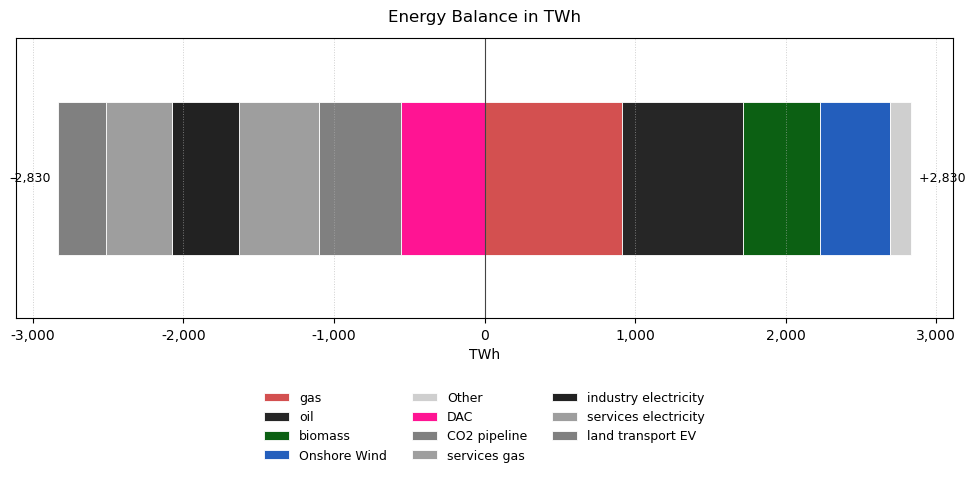

In [55]:
# Rename columns for better readability
rename_cols = {
    "-": "Load",
    "load": "load shedding",
}

# Calculate the energy balance, aggregate by carrier, and convert MWh to TWh
energy_balance = (
    n.statistics.energy_balance()
    .loc[:, :, :]
    # .loc[:, :, "AC"] #nur Stromsystem
    .groupby("carrier")
    .sum()
    .div(1e6)  # Convert MWh to TWh
    .to_frame()
    .T
    .rename(columns=rename_cols)
)

# Remove carriers with no energy flow
energy_balance = energy_balance.loc[:, (energy_balance != 0).any(axis=0)]

# Build color lookup from cfg
colors = {k.lower(): v for k, v in cfg["plotting"]["tech_colors"].items()}
nice_names = {v.lower(): k for k, v in cfg["plotting"]["nice_names"].items()}

def color_for(col):
    original = col.lower()
    key = nice_names.get(original, original).lower()
    return colors.get(key, "#9e9e9e")  # fallback gray

# --- Order by absolute contribution, keep top 10, roll rest into "Other" ---
top_n = 10
s = energy_balance.iloc[0]
ordered = s.reindex(s.abs().sort_values(ascending=False).index)

top_cols = ordered.index[:top_n].tolist()
other_cols = ordered.index[top_n:].tolist()

df_plot = energy_balance[top_cols].copy()
if other_cols:
    df_plot["Other"] = energy_balance[other_cols].sum(axis=1)

# Order within the stack: positives (largest→smallest), then negatives (smallest→largest)
pos = df_plot.iloc[0][df_plot.iloc[0] > 0].sort_values(ascending=False)
neg = df_plot.iloc[0][df_plot.iloc[0] < 0].sort_values(ascending=True)
stack_order = list(pos.index) + list(neg.index)
df_plot = df_plot[stack_order]

# --- Build color list ---
color_list = [color_for(c) if c != "Other" else "#cfcfcf" for c in df_plot.columns]

# --- Plot horizontal stacked bar ---
fig, ax = plt.subplots(figsize=(10, 4.5))
df_plot.plot.barh(
    stacked=True, ax=ax, color=color_list, edgecolor="white", linewidth=0.6, width=0.6
)
ax.set_title("Energy Balance in TWh", pad=12)
ax.set_xlabel("TWh")
ax.set_ylabel("")
ax.set_yticklabels([""])  # hide category label
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
ax.grid(axis="x", linestyle=":", linewidth=0.7, alpha=0.6)
ax.axvline(0, color="#444", linewidth=0.8)

# --- Build legend ---
nice_labels = [cfg["plotting"]["nice_names"].get(c, c) for c in df_plot.columns]
handles = [
    Patch(facecolor=color_list[i], edgecolor="white", linewidth=0.6, label=nice_labels[i])
    for i in range(len(df_plot.columns))
]
cols_in_legend = 3 if len(nice_labels) <= 18 else 4
ax.legend(
    handles=handles,
    labels=nice_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=cols_in_legend,
    frameon=False,
    fontsize=9,
    title=None,
)

# --- Annotate totals ---
vals = df_plot.iloc[0]
cum_pos = vals[vals > 0].sum()
cum_neg = vals[vals < 0].sum()
ax.text(cum_pos, 0, f"  +{int(round(cum_pos)):,}", va="center", ha="left", fontsize=9)
ax.text(cum_neg, 0, f"{int(round(cum_neg)):,}  ", va="center", ha="right", fontsize=9)

plt.tight_layout()
plt.subplots_adjust(bottom=0.28)
plt.show()


Analyse the future energy generation of the energy system - tabular view

In [56]:
n.statistics.energy_balance()/1e6 # In TWh

component  carrier                               bus_carrier                  
Store      biogas                                biogas                           3.316390e-05
           co2                                   co2                              6.597668e-02
           co2 stored                            co2 stored                      -4.629884e+01
           oil                                   oil                              9.036039e+02
           residential rural water tanks         residential rural water tanks   -5.415000e-08
                                                                                      ...     
Link       urban central solid biomass CHP CC    urban central heat               4.007721e+02
           urban central water tanks charger     urban central heat              -6.098100e-07
                                                 urban central water tanks        6.098100e-07
           urban central water tanks discharger  urban central hea

## Analyse pv and wind potential - map view

In [57]:
solar = xr.open_dataset(solar_path)
wind = xr.open_dataset(onwind_path)

def plot_voronoi(n, carrier, voronoi, cmap, projection, title=None, filename=None):
    g = n.generators.loc[n.generators.carrier == carrier]
    br = gpd.read_file(f"{PARENT}resources/{scenario_name}/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br_area = br.to_crs("ESRI:54009")
    br_area = br_area.geometry.area * 1e-6
    br["p_nom_max"] = g.groupby("bus").sum().p_nom_max / br_area

    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": projection})
    plt.rcParams.update({"font.size": 10})
    br.plot(
        ax=ax,
        column="p_nom_max",
        transform=ccrs.PlateCarree(),
        linewidth=0.25,
        edgecolor="k",
        cmap=cmap,
        vmin=0,
        vmax=br["p_nom_max"].max(),
        legend=True,
        legend_kwds={"label": r"potential density"},
    )
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS.with_scale("110m"))
    ax.set_extent(country_coordinates, crs=ccrs.PlateCarree()) 
    
    if title is not None:
        plt.title(title)

Plot wind energy potential

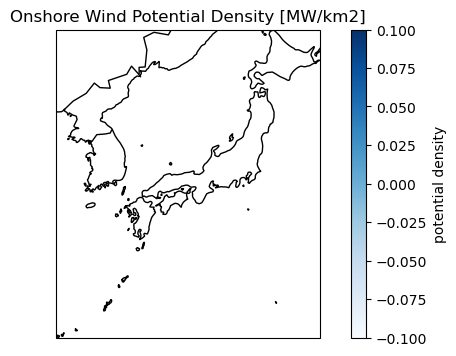

In [58]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "onwind",
    "onshore",
    "Blues",
    ccrs.PlateCarree(),
    title="Onshore Wind Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Plot pv energy potential

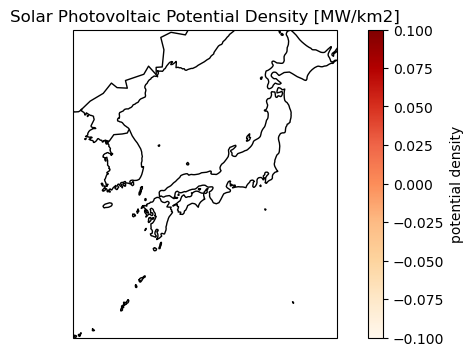

In [59]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "solar",
    "onshore",
    "OrRd",
    ccrs.PlateCarree(),
    title="Solar Photovoltaic Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

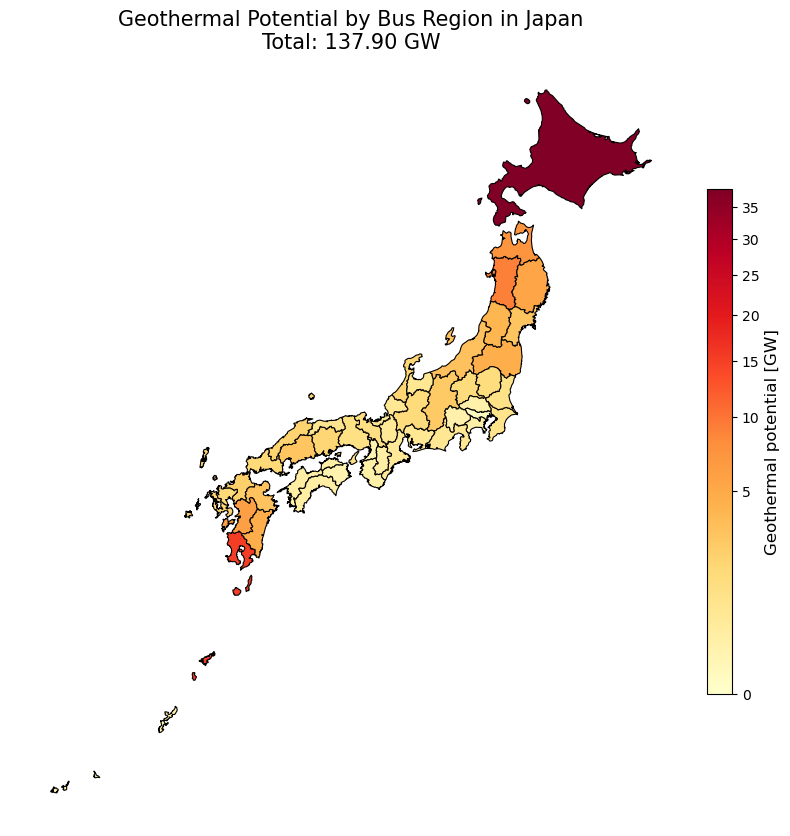

In [60]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

egs_potential_path = "/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/egs_potentials_10_2050.csv"

potential_column = "p_nom_max"
potential_unit = "GW"

cmap = "YlOrRd"  # yellow = low, red = high


# ------------------------------------------------------------
# 1) Load geothermal potential data
# ------------------------------------------------------------

egs_potentials = pd.read_csv(egs_potential_path)

egs_potentials["region_exact"] = (
    egs_potentials["region"]
    .astype(str)
    .str.strip()
)

egs_potentials["region_without_AC"] = (
    egs_potentials["region_exact"]
    .str.replace("_AC$", "", regex=True)
)

egs_potentials["region_with_AC"] = np.where(
    egs_potentials["region_exact"].str.endswith("_AC"),
    egs_potentials["region_exact"],
    egs_potentials["region_exact"] + "_AC"
)

egs_potentials["geothermal_potential"] = (
    egs_potentials[potential_column]
    .fillna(0)
)


# ------------------------------------------------------------
# 2) Prepare GADM regions
# ------------------------------------------------------------

regions = gadm_shapes.copy()

potential_key_columns = [
    "region_exact",
    "region_without_AC",
    "region_with_AC",
]

candidate_region_columns = ["__index__"]

for col in regions.columns:
    if col != regions.geometry.name:
        candidate_region_columns.append(col)

best_match = {
    "gadm_column": None,
    "potential_key": None,
    "matches": -1,
}

for gadm_col in candidate_region_columns:

    if gadm_col == "__index__":
        gadm_values = regions.index.astype(str).str.strip()
    else:
        gadm_values = regions[gadm_col].astype(str).str.strip()

    gadm_set = set(gadm_values)

    for potential_key in potential_key_columns:
        potential_set = set(
            egs_potentials[potential_key]
            .astype(str)
            .str.strip()
        )

        matches = len(gadm_set.intersection(potential_set))

        if matches > best_match["matches"]:
            best_match = {
                "gadm_column": gadm_col,
                "potential_key": potential_key,
                "matches": matches,
            }

if best_match["matches"] == 0:
    raise ValueError(
        "No matching region column found. "
        "Check region names in the CSV and in gadm_shapes."
    )


# ------------------------------------------------------------
# 3) Merge potentials onto regions
# ------------------------------------------------------------

if best_match["gadm_column"] == "__index__":
    regions["join_key"] = regions.index.astype(str).str.strip()
else:
    regions["join_key"] = (
        regions[best_match["gadm_column"]]
        .astype(str)
        .str.strip()
    )

potential_lookup = (
    egs_potentials
    .set_index(best_match["potential_key"])["geothermal_potential"]
)

regions["geothermal_potential"] = (
    regions["join_key"]
    .map(potential_lookup)
    .fillna(0)
)


# ------------------------------------------------------------
# 4) Plot map
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 11),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

vmin = 0
vmax = regions["geothermal_potential"].max()

if vmax <= 0:
    raise ValueError(
        "All mapped potentials are zero. The merge did not work correctly."
    )

norm = mcolors.PowerNorm(
    gamma=0.45,
    vmin=vmin,
    vmax=vmax
)

regions.plot(
    column="geothermal_potential",
    ax=ax,
    cmap=cmap,
    norm=norm,
    linewidth=0.8,
    edgecolor="black",
    transform=ccrs.PlateCarree()
)

bounds = regions.total_bounds

lon_buffer = 1.5
lat_buffer = 1.0

ax.set_extent(
    [
        bounds[0] - lon_buffer,
        bounds[2] + lon_buffer,
        bounds[1] - lat_buffer,
        bounds[3] + lat_buffer,
    ],
    crs=ccrs.PlateCarree()
)

ax.set_title(
    f"Geothermal Potential by Bus Region in Japan\n"
    f"Total: {regions['geothermal_potential'].sum():.2f} {potential_unit}",
    fontsize=15
)

ax.axis("off")


# ------------------------------------------------------------
# 5) Colorbar
# ------------------------------------------------------------

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="vertical",
    fraction=0.035,
    pad=0.02
)

cbar.set_label(
    f"Geothermal potential [{potential_unit}]",
    fontsize=12
)

plt.tight_layout()
plt.show()

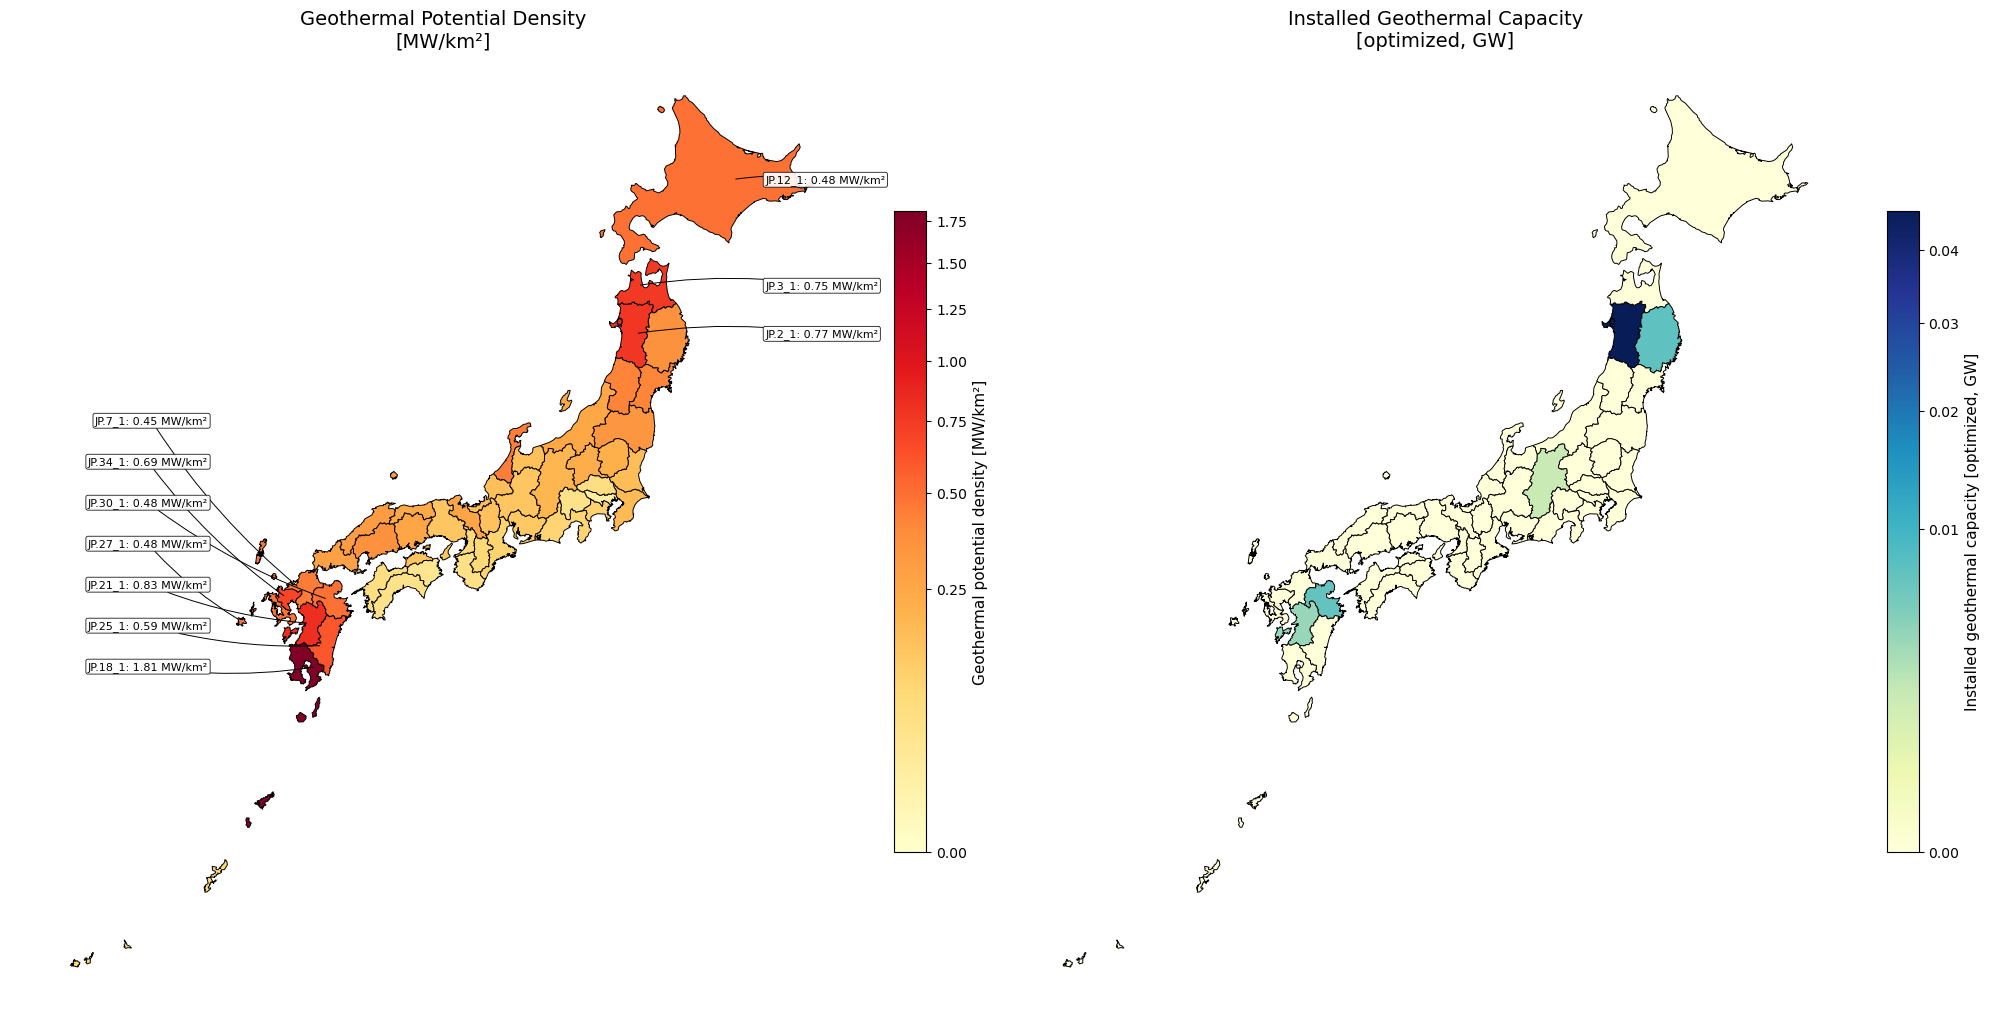

In [61]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

egs_potential_path = "/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/egs_potentials_10_2050.csv"

potential_column = "p_nom_max"

electric_bus_carriers = ["AC", "DC", "low voltage"]

# "optimized" = p_nom_opt, also zukünftige installierte Leistung
# "current" = p_nom, also heutige/bestehende installierte Leistung
capacity_mode = "optimized"

# Colormaps
potential_density_cmap = "YlOrRd"   # yellow -> red
installed_capacity_cmap = "YlGnBu"  # yellow/green -> blue


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def get_capacity(df, nominal_col="p_nom", mode="optimized"):
    """
    Get current or optimized capacity.
    """
    if mode == "optimized":
        opt_col = f"{nominal_col}_opt"

        if opt_col in df.columns:
            capacity = df[opt_col].copy()

            if nominal_col in df.columns:
                capacity = capacity.fillna(df[nominal_col])

            return capacity.fillna(0)

    if nominal_col in df.columns:
        return df[nominal_col].fillna(0)

    return pd.Series(0, index=df.index)


def bus_to_region(bus_name):
    """
    Convert PyPSA bus names to GADM region names.
    Examples:
    JP.10_1_AC -> JP.10_1
    JP.10_1 low voltage -> JP.10_1
    """
    s = str(bus_name)

    suffixes = [
        "_AC",
        "_DC",
        " AC",
        " DC",
        " low voltage",
        "_low voltage",
        " heat",
        "_heat",
        " gas",
        "_gas",
        " oil",
        "_oil",
        " coal",
        "_coal",
        " biomass",
        "_biomass",
        " H2",
        "_H2",
    ]

    for suffix in suffixes:
        if s.endswith(suffix):
            s = s[: -len(suffix)]

    return s.strip()


# ------------------------------------------------------------
# 1) Load geothermal potential data
# ------------------------------------------------------------

egs_potentials = pd.read_csv(egs_potential_path)

egs_potentials["region_without_AC"] = (
    egs_potentials["region"]
    .astype(str)
    .str.strip()
    .str.replace("_AC$", "", regex=True)
)

egs_potentials["geothermal_potential_GW"] = (
    egs_potentials[potential_column]
    .fillna(0)
)


# ------------------------------------------------------------
# 2) Prepare GADM regions
# ------------------------------------------------------------

regions = gadm_shapes.copy()

if regions.crs is None:
    regions = regions.set_crs("EPSG:4326")

regions["region"] = regions["GADM_ID"].astype(str).str.strip()

potential_lookup = (
    egs_potentials
    .set_index("region_without_AC")["geothermal_potential_GW"]
)

regions["geothermal_potential_GW"] = (
    regions["region"]
    .map(potential_lookup)
    .fillna(0)
)


# ------------------------------------------------------------
# 3) Calculate area-normalized geothermal potential
# ------------------------------------------------------------
# Equal-area projection for area calculation
regions_equal_area = regions.to_crs("EPSG:6933")

regions["area_km2"] = regions_equal_area.geometry.area / 1e6

regions["geothermal_potential_density_MW_per_km2"] = (
    regions["geothermal_potential_GW"] * 1e3
    / regions["area_km2"]
)

regions["geothermal_potential_density_MW_per_km2"] = (
    regions["geothermal_potential_density_MW_per_km2"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


# ------------------------------------------------------------
# 4) Installed geothermal capacity from generators
# ------------------------------------------------------------

generator_geo_capacity = pd.Series(dtype=float)

if hasattr(n, "generators") and len(n.generators) > 0:
    generators = n.generators.copy()

    generators = generators[
        generators.carrier.astype(str).str.contains(
            "geothermal",
            case=False,
            regex=True,
            na=False
        )
    ].copy()

    if not generators.empty:
        generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

        generators = generators[
            generators["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        generators["capacity_MW"] = get_capacity(
            generators,
            "p_nom",
            mode=capacity_mode
        )

        generators["region"] = generators.bus.map(bus_to_region)

        generator_geo_capacity = (
            generators
            .groupby("region")["capacity_MW"]
            .sum()
        )


# ------------------------------------------------------------
# 5) Installed geothermal capacity from links
# ------------------------------------------------------------

link_geo_capacity_parts = []

if hasattr(n, "links") and len(n.links) > 0:
    links = n.links.copy()

    links = links[
        links.carrier.astype(str).str.contains(
            "geothermal",
            case=False,
            regex=True,
            na=False
        )
    ].copy()

    if not links.empty:
        links["p_nom_final"] = get_capacity(
            links,
            "p_nom",
            mode=capacity_mode
        )

        for bus_number in range(1, 6):
            bus_col = f"bus{bus_number}"

            if bus_col not in links.columns:
                continue

            if bus_number == 1:
                efficiency_col = "efficiency"
            else:
                efficiency_col = f"efficiency{bus_number}"

            output_bus_carrier = links[bus_col].map(n.buses.carrier)
            input_bus_carrier = links["bus0"].map(n.buses.carrier)

            mask = (
                output_bus_carrier.isin(electric_bus_carriers)
                & ~input_bus_carrier.isin(electric_bus_carriers)
            )

            if not mask.any():
                continue

            selected_links = links.loc[mask].copy()

            if efficiency_col in links.columns:
                if bus_number == 1:
                    efficiency = links.loc[mask, efficiency_col].fillna(1)
                else:
                    efficiency = links.loc[mask, efficiency_col].fillna(0)
            else:
                efficiency = 1 if bus_number == 1 else 0

            selected_links["capacity_MW"] = (
                selected_links["p_nom_final"]
                * efficiency
            )

            selected_links["region"] = selected_links[bus_col].map(bus_to_region)

            tmp = (
                selected_links
                .groupby("region")["capacity_MW"]
                .sum()
            )

            link_geo_capacity_parts.append(tmp)


if link_geo_capacity_parts:
    link_geo_capacity = (
        pd.concat(link_geo_capacity_parts)
        .groupby(level=0)
        .sum()
    )
else:
    link_geo_capacity = pd.Series(dtype=float)


# ------------------------------------------------------------
# 6) Merge installed geothermal capacity onto regions
# ------------------------------------------------------------

installed_geo_capacity_by_region = (
    pd.concat(
        [
            generator_geo_capacity,
            link_geo_capacity,
        ],
        axis=0
    )
    .groupby(level=0)
    .sum()
)

regions["installed_geothermal_capacity_MW"] = (
    regions["region"]
    .map(installed_geo_capacity_by_region)
    .fillna(0)
)

regions["installed_geothermal_capacity_GW"] = (
    regions["installed_geothermal_capacity_MW"] / 1e3
)


# ------------------------------------------------------------
# 7) Plot two maps side by side
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 12),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# Same map extent for both maps
bounds = regions.total_bounds

lon_buffer = 1.8
lat_buffer = 1.0

extent = [
    bounds[0] - lon_buffer,
    bounds[2] + lon_buffer,
    bounds[1] - lat_buffer,
    bounds[3] + lat_buffer,
]


# ------------------------------------------------------------
# Left map: geothermal potential density
# ------------------------------------------------------------

left_col = "geothermal_potential_density_MW_per_km2"

left_norm = mcolors.PowerNorm(
    gamma=0.45,
    vmin=0,
    vmax=regions[left_col].max()
)

regions.plot(
    column=left_col,
    ax=axes[0],
    cmap=potential_density_cmap,
    norm=left_norm,
    linewidth=0.7,
    edgecolor="black",
    transform=ccrs.PlateCarree()
)

axes[0].set_title(
    "Geothermal Potential Density\n[MW/km²]",
    fontsize=14
)

axes[0].set_extent(extent, crs=ccrs.PlateCarree())
axes[0].axis("off")


# ------------------------------------------------------------
# Right map: installed geothermal capacity
# ------------------------------------------------------------

right_col = "installed_geothermal_capacity_GW"

right_vmax = regions[right_col].max()

if right_vmax > 0:
    right_norm = mcolors.PowerNorm(
        gamma=0.45,
        vmin=0,
        vmax=right_vmax
    )
else:
    right_norm = mcolors.Normalize(vmin=0, vmax=1)

regions.plot(
    column=right_col,
    ax=axes[1],
    cmap=installed_capacity_cmap,
    norm=right_norm,
    linewidth=0.7,
    edgecolor="black",
    transform=ccrs.PlateCarree()
)

axes[1].set_title(
    f"Installed Geothermal Capacity\n[{capacity_mode}, GW]",
    fontsize=14
)

axes[1].set_extent(extent, crs=ccrs.PlateCarree())
axes[1].axis("off")

# ------------------------------------------------------------
# 7a) Add labels for top 10 geothermal potential density regions
# ------------------------------------------------------------

top_n_density_labels = 10
min_density_label_spacing_deg = 1.0

top_density_regions = (
    regions
    .sort_values(left_col, ascending=False)
    .head(top_n_density_labels)
    .copy()
)

# Use representative points so arrows point inside each polygon
top_density_regions["label_point"] = top_density_regions.geometry.representative_point()
top_density_regions["lon"] = top_density_regions["label_point"].x
top_density_regions["lat"] = top_density_regions["label_point"].y

# Split into western and eastern labels to reduce overlap
map_center_lon = (extent[0] + extent[1]) / 2

density_west_labels = top_density_regions[
    top_density_regions["lon"] < map_center_lon
].copy()

density_east_labels = top_density_regions[
    top_density_regions["lon"] >= map_center_lon
].copy()

# Place labels close to the corresponding regions
density_west_text_lon = (
    density_west_labels["lon"].min() - 1.0
    if not density_west_labels.empty
    else None
)

density_east_text_lon = (
    density_east_labels["lon"].max() + 1.0
    if not density_east_labels.empty
    else None
)

# Keep labels inside map extent
if density_west_text_lon is not None:
    density_west_text_lon = max(density_west_text_lon, extent[0] + 0.4)

if density_east_text_lon is not None:
    density_east_text_lon = min(density_east_text_lon, extent[1] - 0.4)

density_lat_min = extent[2] + 0.5
density_lat_max = extent[3] - 0.5


def spread_density_label_positions(df, min_spacing=min_density_label_spacing_deg):
    """
    Spread label y-positions vertically to reduce overlap.
    """
    if df.empty:
        return df

    df = df.sort_values("lat").copy()

    desired_y = df["lat"].to_numpy()
    adjusted_y = desired_y.copy()

    # Forward pass
    for i in range(1, len(adjusted_y)):
        if adjusted_y[i] - adjusted_y[i - 1] < min_spacing:
            adjusted_y[i] = adjusted_y[i - 1] + min_spacing

    # Shift down if labels exceed upper boundary
    overflow = adjusted_y[-1] - density_lat_max
    if overflow > 0:
        adjusted_y -= overflow

    # Backward pass
    for i in range(len(adjusted_y) - 2, -1, -1):
        if adjusted_y[i + 1] - adjusted_y[i] < min_spacing:
            adjusted_y[i] = adjusted_y[i + 1] - min_spacing

    # Shift up if labels exceed lower boundary
    underflow = density_lat_min - adjusted_y[0]
    if underflow > 0:
        adjusted_y += underflow

    df["text_lat"] = adjusted_y

    return df.sort_values("lat", ascending=False)


density_west_labels = spread_density_label_positions(density_west_labels)
density_east_labels = spread_density_label_positions(density_east_labels)

density_map_transform = ccrs.PlateCarree()._as_mpl_transform(axes[0])


def add_density_labels(df, text_lon, ha):
    """
    Add compact labels with arrows to the geothermal potential density map.
    """
    if df.empty:
        return

    for _, row in df.iterrows():

        lon = row["lon"]
        lat = row["lat"]
        text_lat = row["text_lat"]

        region_name = row["region"]
        density_value = row[left_col]

        label_text = f"{region_name}: {density_value:.2f} MW/km²"

        axes[0].annotate(
            label_text,
            xy=(lon, lat),
            xycoords=density_map_transform,
            xytext=(text_lon, text_lat),
            textcoords=density_map_transform,
            ha=ha,
            va="center",
            fontsize=8,
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="black",
                linewidth=0.6,
                alpha=0.90
            ),
            arrowprops=dict(
                arrowstyle="-",
                color="black",
                linewidth=0.7,
                shrinkA=0,
                shrinkB=3,
                connectionstyle="arc3,rad=0.08"
            ),
            zorder=10
        )


add_density_labels(
    density_west_labels,
    density_west_text_lon,
    ha="right"
)

add_density_labels(
    density_east_labels,
    density_east_text_lon,
    ha="left"
)

# ------------------------------------------------------------
# 7b) Add compact, non-overlapping labels for regions with high installed capacity
# ------------------------------------------------------------

label_threshold_GW = 2.0

# Mindestabstand zwischen zwei Label-Kästchen in Grad Breite/Länge.
# Falls sich doch noch etwas berührt: auf 1.2 oder 1.4 erhöhen.
min_label_spacing_deg = 1.05

label_regions = regions[
    regions[right_col] > label_threshold_GW
].copy()

# Representative points ensure that arrows point inside each polygon
label_regions["label_point"] = label_regions.geometry.representative_point()
label_regions["lon"] = label_regions["label_point"].x
label_regions["lat"] = label_regions["label_point"].y

# ------------------------------------------------------------
# Group labels geographically so they stay close to their regions
# ------------------------------------------------------------
# Adjust these longitude thresholds if needed.
west_labels = label_regions[label_regions["lon"] < 136.0].copy()
east_labels = label_regions[label_regions["lon"] >= 136.0].copy()

# Label columns closer to Japan than before
# West labels: mostly Kyushu / western Japan
# East labels: mostly Tohoku / northern Japan
west_text_lon = west_labels["lon"].max() - 8.0 if not west_labels.empty else None
east_text_lon = east_labels["lon"].max() - 8.0 if not east_labels.empty else None

# Keep labels within map extent
if west_text_lon is not None:
    west_text_lon = min(west_text_lon, extent[1] - 2.0)

if east_text_lon is not None:
    east_text_lon = min(east_text_lon, extent[1] - 1.0)

lat_min = extent[2] + 0.5
lat_max = extent[3] - 0.5


def spread_label_positions(df, min_spacing=min_label_spacing_deg):
    """
    Spread labels vertically to avoid overlap.
    The labels stay close to the original region latitude.
    """
    if df.empty:
        return df

    df = df.sort_values("lat").copy()

    desired_y = df["lat"].to_numpy()
    adjusted_y = desired_y.copy()

    # Forward pass
    for i in range(1, len(adjusted_y)):
        if adjusted_y[i] - adjusted_y[i - 1] < min_spacing:
            adjusted_y[i] = adjusted_y[i - 1] + min_spacing

    # Shift down if upper bound is exceeded
    overflow = adjusted_y[-1] - lat_max
    if overflow > 0:
        adjusted_y -= overflow

    # Backward pass
    for i in range(len(adjusted_y) - 2, -1, -1):
        if adjusted_y[i + 1] - adjusted_y[i] < min_spacing:
            adjusted_y[i] = adjusted_y[i + 1] - min_spacing

    # Shift up if lower bound is exceeded
    underflow = lat_min - adjusted_y[0]
    if underflow > 0:
        adjusted_y += underflow

    df["text_lat"] = adjusted_y

    return df.sort_values("lat", ascending=False)


west_labels = spread_label_positions(west_labels)
east_labels = spread_label_positions(east_labels)

map_transform = ccrs.PlateCarree()._as_mpl_transform(axes[1])


def add_capacity_labels(df, text_lon, ha="left"):
    """
    Add compact capacity labels with arrows.
    """
    if df.empty:
        return

    for _, row in df.iterrows():

        lon = row["lon"]
        lat = row["lat"]
        text_lat = row["text_lat"]
        capacity = row[right_col]
        region_name = row["region"]

        # Compact one-line label to reduce overlap
        label_text = f"{region_name}: {capacity:.2f} GW"

        axes[1].annotate(
            label_text,
            xy=(lon, lat),
            xycoords=map_transform,
            xytext=(text_lon, text_lat),
            textcoords=map_transform,
            ha=ha,
            va="center",
            fontsize=8,
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="black",
                linewidth=0.6,
                alpha=0.90
            ),
            arrowprops=dict(
                arrowstyle="-",
                color="black",
                linewidth=0.7,
                shrinkA=0,
                shrinkB=3,
                connectionstyle="arc3,rad=0.08"
            ),
            zorder=10
        )


# Labels close to their regions
add_capacity_labels(west_labels, west_text_lon, ha="left")
add_capacity_labels(east_labels, east_text_lon, ha="left")


# ------------------------------------------------------------
# 8) Colorbars
# ------------------------------------------------------------

sm_left = plt.cm.ScalarMappable(
    cmap=potential_density_cmap,
    norm=left_norm
)

sm_left.set_array([])

cbar_left = fig.colorbar(
    sm_left,
    ax=axes[0],
    orientation="vertical",
    fraction=0.035,
    pad=0.02
)

cbar_left.set_label(
    "Geothermal potential density [MW/km²]",
    fontsize=11
)


sm_right = plt.cm.ScalarMappable(
    cmap=installed_capacity_cmap,
    norm=right_norm
)

sm_right.set_array([])

cbar_right = fig.colorbar(
    sm_right,
    ax=axes[1],
    orientation="vertical",
    fraction=0.035,
    pad=0.02
)

cbar_right.set_label(
    f"Installed geothermal capacity [{capacity_mode}, GW]",
    fontsize=11
)


plt.tight_layout()
plt.show()

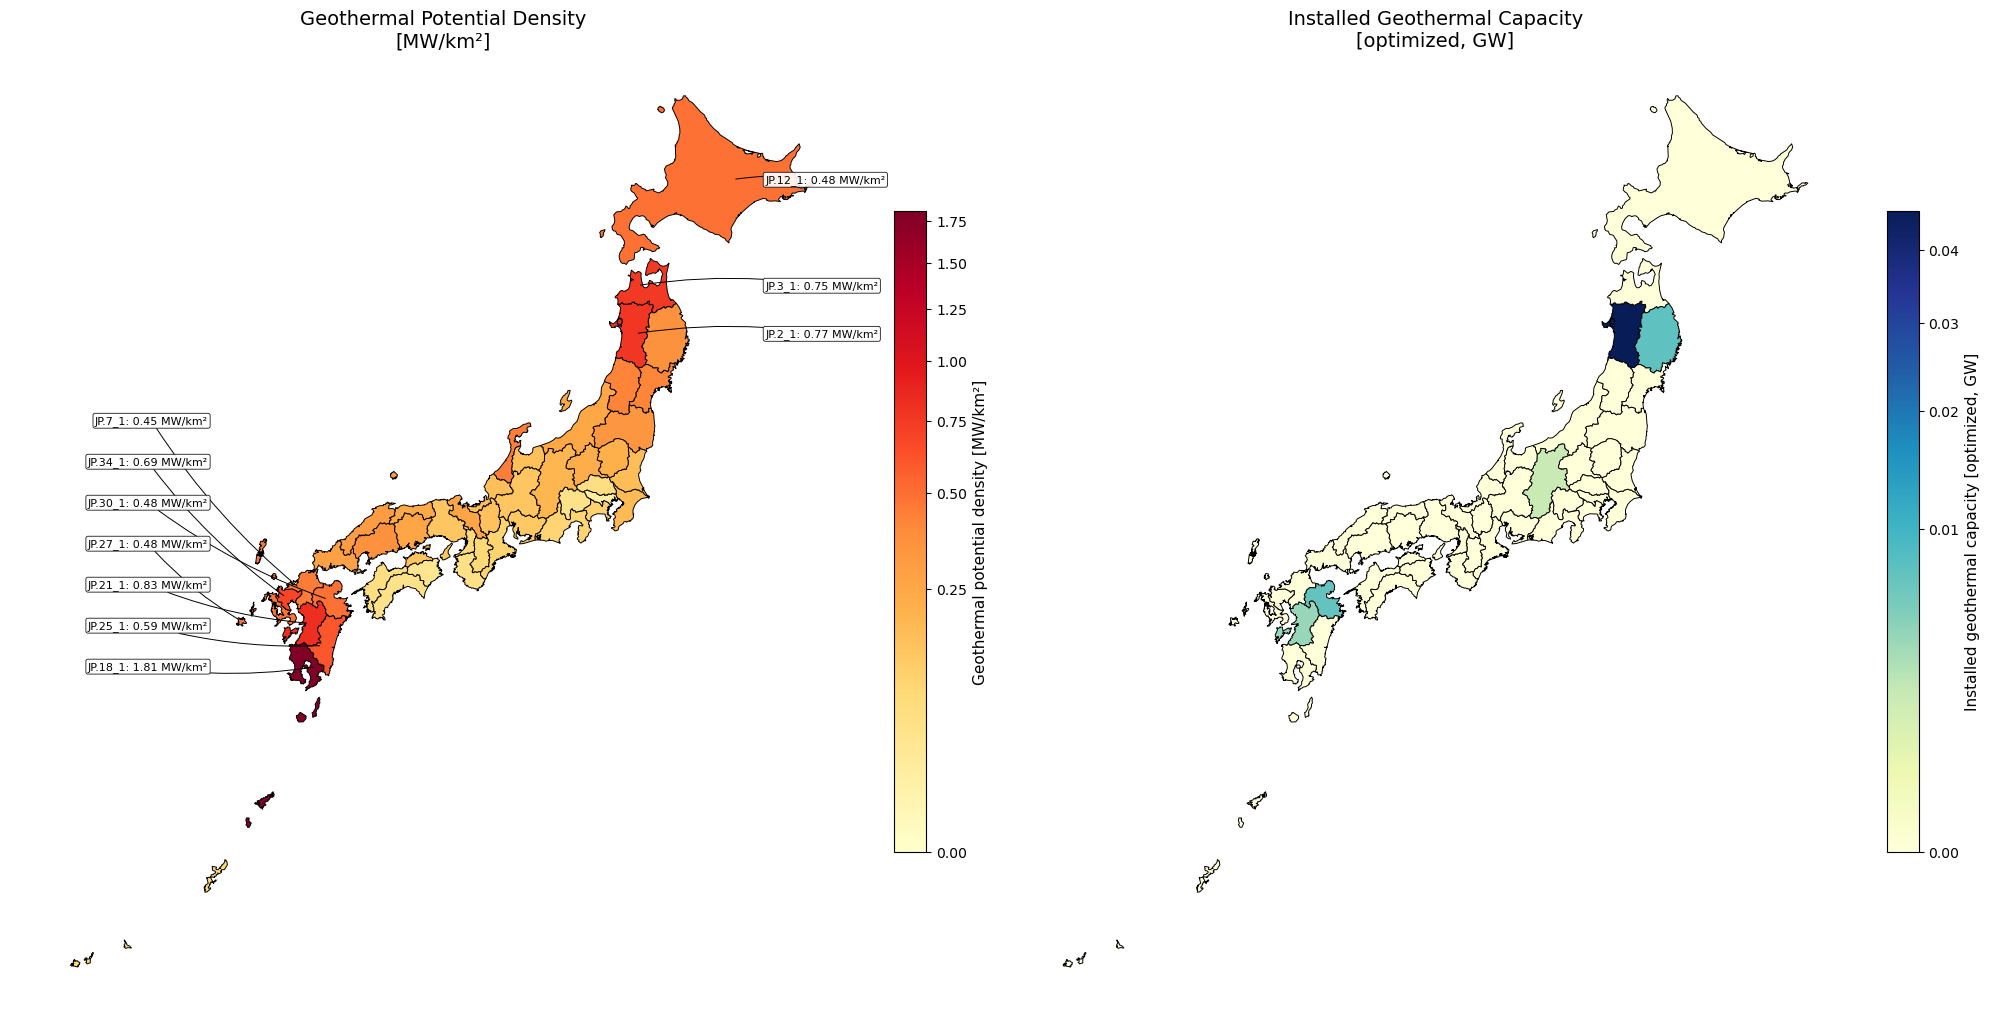

,region,installed_geothermal_capacity_GW,lcoe_electricity_EUR_per_MWh,lcoh_heat_EUR_per_MWh
1,JP.2_1,0.0460,NaN,NaN
15,JP.16_1,0.0074,NaN,NaN
29,JP.30_1,0.0070,NaN,NaN
20,JP.21_1,0.0040,NaN,NaN
25,JP.26_1,0.0020,NaN,NaN
0,JP.1_1,0.0000,NaN,NaN
2,JP.3_1,0.0000,NaN,NaN
7,JP.8_1,0.0000,NaN,NaN
8,JP.9_1,0.0000,NaN,NaN
9,JP.10_1,0.0000,NaN,NaN


In [62]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

egs_potential_path = "/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/egs_potentials_10_2050.csv"

potential_column = "p_nom_max"

electric_bus_carriers = ["AC", "DC", "low voltage"]

# "optimized" = p_nom_opt, also zukünftige installierte Leistung
# "current" = p_nom, also heutige/bestehende installierte Leistung
capacity_mode = "optimized"

# Colormaps
potential_density_cmap = "YlOrRd"   # yellow -> red
installed_capacity_cmap = "YlGnBu"  # yellow/green -> blue

# Geothermal technology names
orc_carrier = "geothermal organic rankine cycle"
dh_carrier = "geothermal district heat"
upstream_geo_heat_carrier = "geothermal heat"

# Label settings
top_n_density_labels = 10
label_threshold_GW = 2.0


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def get_capacity(df, nominal_col="p_nom", mode="optimized"):
    """
    Get current or optimized capacity.
    """
    if mode == "optimized":
        opt_col = f"{nominal_col}_opt"

        if opt_col in df.columns:
            capacity = df[opt_col].copy()

            if nominal_col in df.columns:
                capacity = capacity.fillna(df[nominal_col])

            return capacity.fillna(0)

    if nominal_col in df.columns:
        return df[nominal_col].fillna(0)

    return pd.Series(0, index=df.index)


def bus_to_region(bus_name):
    """
    Convert PyPSA bus names to GADM region names.
    Examples:
    JP.10_1_AC -> JP.10_1
    JP.10_1 urban central heat -> JP.10_1
    JP.10_1 geothermal heat -> JP.10_1
    """
    s = str(bus_name).strip()

    # Try direct GADM extraction first
    match = pd.Series([s]).str.extract(r"^([A-Z]{2}\.\d+_\d+)")[0].iloc[0]

    if pd.notna(match):
        return match

    suffixes = [
        "_AC",
        "_DC",
        " AC",
        " DC",
        " low voltage",
        "_low voltage",
        " urban central heat",
        "_urban central heat",
        " geothermal heat",
        "_geothermal heat",
        " heat",
        "_heat",
        " gas",
        "_gas",
        " oil",
        "_oil",
        " coal",
        "_coal",
        " biomass",
        "_biomass",
        " H2",
        "_H2",
    ]

    changed = True

    while changed:
        changed = False

        for suffix in suffixes:
            if s.endswith(suffix):
                s = s[: -len(suffix)].strip()
                changed = True

    return s


def get_snapshot_weights(network):
    """
    Snapshot weights for converting MW to MWh.
    """
    sw = getattr(network, "snapshot_weightings", None)

    if isinstance(sw, pd.DataFrame):
        if "generators" in sw.columns:
            return sw["generators"].reindex(network.snapshots).astype(float).fillna(1.0)
        if "objective" in sw.columns:
            return sw["objective"].reindex(network.snapshots).astype(float).fillna(1.0)

    return pd.Series(1.0, index=network.snapshots)


def annual_link_costs(links_subset):
    """
    Annualized link costs:
    capital_cost * p_nom / p_nom_opt + marginal_cost * weighted p0 input.
    """
    if links_subset.empty:
        return pd.Series(dtype=float)

    capacities = get_capacity(
        links_subset,
        "p_nom",
        mode=capacity_mode
    )

    annual_capex = (
        links_subset["capital_cost"].fillna(0)
        * capacities
    )

    if hasattr(n.links_t, "p0"):
        available_links = links_subset.index.intersection(n.links_t.p0.columns)

        input_MWh = (
            n.links_t.p0[available_links]
            .clip(lower=0)
            .mul(weights, axis=0)
            .sum(axis=0)
        )

        input_MWh = input_MWh.reindex(links_subset.index).fillna(0)
    else:
        input_MWh = pd.Series(0.0, index=links_subset.index)

    variable_cost = (
        input_MWh
        * links_subset["marginal_cost"].fillna(0)
    )

    return annual_capex + variable_cost


def annual_generator_costs(gens_subset):
    """
    Annualized generator costs:
    capital_cost * p_nom / p_nom_opt + marginal_cost * weighted positive dispatch.
    """
    if gens_subset.empty:
        return pd.Series(dtype=float)

    capacities = get_capacity(
        gens_subset,
        "p_nom",
        mode=capacity_mode
    )

    annual_capex = (
        gens_subset["capital_cost"].fillna(0)
        * capacities
    )

    if hasattr(n.generators_t, "p"):
        available_gens = gens_subset.index.intersection(n.generators_t.p.columns)

        output_MWh = (
            n.generators_t.p[available_gens]
            .clip(lower=0)
            .mul(weights, axis=0)
            .sum(axis=0)
        )

        output_MWh = output_MWh.reindex(gens_subset.index).fillna(0)
    else:
        output_MWh = pd.Series(0.0, index=gens_subset.index)

    variable_cost = (
        output_MWh
        * gens_subset["marginal_cost"].fillna(0)
    )

    return annual_capex + variable_cost


weights = get_snapshot_weights(n)


# ------------------------------------------------------------
# 1) Load geothermal potential data
# ------------------------------------------------------------

egs_potentials = pd.read_csv(egs_potential_path)

egs_potentials["region_without_AC"] = (
    egs_potentials["region"]
    .astype(str)
    .str.strip()
    .str.replace("_AC$", "", regex=True)
)

egs_potentials["geothermal_potential_GW"] = (
    egs_potentials[potential_column]
    .fillna(0)
)


# ------------------------------------------------------------
# 2) Prepare GADM regions
# ------------------------------------------------------------

regions = gadm_shapes.copy()

if regions.crs is None:
    regions = regions.set_crs("EPSG:4326")

regions["region"] = regions["GADM_ID"].astype(str).str.strip()

potential_lookup = (
    egs_potentials
    .set_index("region_without_AC")["geothermal_potential_GW"]
)

regions["geothermal_potential_GW"] = (
    regions["region"]
    .map(potential_lookup)
    .fillna(0)
)


# ------------------------------------------------------------
# 3) Calculate area-normalized geothermal potential
# ------------------------------------------------------------

regions_equal_area = regions.to_crs("EPSG:6933")

regions["area_km2"] = regions_equal_area.geometry.area / 1e6

regions["geothermal_potential_density_MW_per_km2"] = (
    regions["geothermal_potential_GW"] * 1e3
    / regions["area_km2"]
)

regions["geothermal_potential_density_MW_per_km2"] = (
    regions["geothermal_potential_density_MW_per_km2"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


# ------------------------------------------------------------
# 4) Installed geothermal electricity capacity from generators
# ------------------------------------------------------------

generator_geo_capacity = pd.Series(dtype=float)

if hasattr(n, "generators") and len(n.generators) > 0:
    generators = n.generators.copy()

    generators = generators[
        generators.carrier.astype(str).str.contains(
            "geothermal",
            case=False,
            regex=True,
            na=False
        )
    ].copy()

    if not generators.empty:
        generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

        generators = generators[
            generators["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        generators["capacity_MW"] = get_capacity(
            generators,
            "p_nom",
            mode=capacity_mode
        )

        generators["region"] = generators.bus.map(bus_to_region)

        generator_geo_capacity = (
            generators
            .groupby("region")["capacity_MW"]
            .sum()
        )


# ------------------------------------------------------------
# 5) Installed geothermal electricity capacity from links
# ------------------------------------------------------------

link_geo_capacity_parts = []

if hasattr(n, "links") and len(n.links) > 0:
    links = n.links.copy()

    links = links[
        links.carrier.astype(str).str.contains(
            "geothermal",
            case=False,
            regex=True,
            na=False
        )
    ].copy()

    if not links.empty:
        links["p_nom_final"] = get_capacity(
            links,
            "p_nom",
            mode=capacity_mode
        )

        for bus_number in range(1, 6):
            bus_col = f"bus{bus_number}"

            if bus_col not in links.columns:
                continue

            if bus_number == 1:
                efficiency_col = "efficiency"
            else:
                efficiency_col = f"efficiency{bus_number}"

            output_bus_carrier = links[bus_col].map(n.buses.carrier)
            input_bus_carrier = links["bus0"].map(n.buses.carrier)

            mask = (
                output_bus_carrier.isin(electric_bus_carriers)
                & ~input_bus_carrier.isin(electric_bus_carriers)
            )

            if not mask.any():
                continue

            selected_links = links.loc[mask].copy()

            if efficiency_col in links.columns:
                if bus_number == 1:
                    efficiency = links.loc[mask, efficiency_col].fillna(1)
                else:
                    efficiency = links.loc[mask, efficiency_col].fillna(0)
            else:
                efficiency = 1 if bus_number == 1 else 0

            selected_links["capacity_MW"] = (
                selected_links["p_nom_final"]
                * efficiency
            )

            selected_links["region"] = selected_links[bus_col].map(bus_to_region)

            tmp = (
                selected_links
                .groupby("region")["capacity_MW"]
                .sum()
            )

            link_geo_capacity_parts.append(tmp)


if link_geo_capacity_parts:
    link_geo_capacity = (
        pd.concat(link_geo_capacity_parts)
        .groupby(level=0)
        .sum()
    )
else:
    link_geo_capacity = pd.Series(dtype=float)


# ------------------------------------------------------------
# 6) Merge installed geothermal electricity capacity onto regions
# ------------------------------------------------------------

installed_geo_capacity_by_region = (
    pd.concat(
        [
            generator_geo_capacity,
            link_geo_capacity,
        ],
        axis=0
    )
    .groupby(level=0)
    .sum()
)

regions["installed_geothermal_capacity_MW"] = (
    regions["region"]
    .map(installed_geo_capacity_by_region)
    .fillna(0)
)

regions["installed_geothermal_capacity_GW"] = (
    regions["installed_geothermal_capacity_MW"] / 1e3
)


# ------------------------------------------------------------
# 6b) Geothermal LCOE / LCOH by region
# ------------------------------------------------------------
# Electricity = geothermal organic rankine cycle
# Heat        = geothermal district heat
#
# Upstream costs of geothermal heat are allocated by geothermal heat input.

# 6b-1) Upstream geothermal heat costs by region
upstream_cost_parts = []

geo_heat_gens = n.generators[
    n.generators.carrier.astype(str).str.lower()
    == upstream_geo_heat_carrier.lower()
].copy()

if not geo_heat_gens.empty:
    geo_heat_gens["region"] = geo_heat_gens.bus.map(bus_to_region)
    geo_heat_gen_costs = annual_generator_costs(geo_heat_gens)

    upstream_cost_parts.append(
        pd.DataFrame({
            "region": geo_heat_gens["region"],
            "cost_EUR_per_a": geo_heat_gen_costs
        })
    )


geo_heat_links = n.links[
    n.links.carrier.astype(str).str.lower()
    == upstream_geo_heat_carrier.lower()
].copy()

if not geo_heat_links.empty:
    geo_heat_links["region"] = geo_heat_links.bus0.map(bus_to_region)
    geo_heat_link_costs = annual_link_costs(geo_heat_links)

    upstream_cost_parts.append(
        pd.DataFrame({
            "region": geo_heat_links["region"],
            "cost_EUR_per_a": geo_heat_link_costs
        })
    )


if upstream_cost_parts:
    upstream_cost_by_region = (
        pd.concat(upstream_cost_parts)
        .groupby("region")["cost_EUR_per_a"]
        .sum()
    )
else:
    upstream_cost_by_region = pd.Series(dtype=float)


# 6b-2) Downstream ORC and district heat links
downstream_links = n.links[
    n.links.carrier.astype(str).str.lower().isin([
        orc_carrier.lower(),
        dh_carrier.lower()
    ])
].copy()

downstream_lcoe_rows = []

if not downstream_links.empty:

    downstream_link_costs = annual_link_costs(downstream_links)

    # Geothermal heat input at p0
    if hasattr(n.links_t, "p0"):
        available_downstream = downstream_links.index.intersection(n.links_t.p0.columns)

        downstream_input_MWh = (
            n.links_t.p0[available_downstream]
            .clip(lower=0)
            .mul(weights, axis=0)
            .sum(axis=0)
        )

        downstream_input_MWh = downstream_input_MWh.reindex(
            downstream_links.index
        ).fillna(0)
    else:
        downstream_input_MWh = pd.Series(0.0, index=downstream_links.index)

    downstream_links["input_region"] = downstream_links.bus0.map(bus_to_region)
    downstream_links["geothermal_heat_input_MWh"] = downstream_input_MWh

    total_downstream_input_by_region = (
        downstream_links
        .groupby("input_region")["geothermal_heat_input_MWh"]
        .sum()
    )

    # Useful outputs:
    # ORC -> electricity
    # district heat -> final heat
    for bus_number in range(1, 6):
        bus_col = f"bus{bus_number}"
        p_col = f"p{bus_number}"

        if bus_col not in downstream_links.columns:
            continue

        if not hasattr(n.links_t, p_col):
            continue

        output_bus_carrier = downstream_links[bus_col].map(n.buses.carrier).astype(str)

        is_orc_electricity = (
            downstream_links.carrier.astype(str).str.lower() == orc_carrier.lower()
        ) & output_bus_carrier.isin(electric_bus_carriers)

        is_dh_heat = (
            downstream_links.carrier.astype(str).str.lower() == dh_carrier.lower()
        ) & output_bus_carrier.str.contains(
            "heat",
            case=False,
            na=False
        ) & ~output_bus_carrier.str.lower().eq("geothermal heat")

        useful_mask = is_orc_electricity | is_dh_heat

        if not useful_mask.any():
            continue

        selected_links = downstream_links.loc[useful_mask].copy()

        useful_output = (
            -getattr(n.links_t, p_col)
            .reindex(index=n.snapshots, columns=selected_links.index)
            .fillna(0)
        ).clip(lower=0)

        useful_output_MWh = (
            useful_output
            .mul(weights, axis=0)
            .sum(axis=0)
        )

        for link_name, output_MWh in useful_output_MWh.items():
            if output_MWh <= 1e-9:
                continue

            link = selected_links.loc[link_name]

            input_region = link["input_region"]
            output_region = bus_to_region(link[bus_col])

            link_input_MWh = link["geothermal_heat_input_MWh"]
            total_region_input_MWh = total_downstream_input_by_region.get(
                input_region,
                0.0
            )

            if total_region_input_MWh > 0:
                upstream_share = link_input_MWh / total_region_input_MWh
            else:
                upstream_share = 0.0

            allocated_upstream_cost = (
                upstream_cost_by_region.get(input_region, 0.0)
                * upstream_share
            )

            link_cost = downstream_link_costs.get(link_name, 0.0)
            total_cost = link_cost + allocated_upstream_cost

            if str(link["carrier"]).lower() == orc_carrier.lower():
                use = "Electricity"
            else:
                use = "Heat"

            downstream_lcoe_rows.append({
                "region": output_region,
                "technology": link["carrier"],
                "use": use,
                "output_TWh": output_MWh / 1e6,
                "link_cost_EUR_per_a": link_cost,
                "allocated_upstream_cost_EUR_per_a": allocated_upstream_cost,
                "total_cost_EUR_per_a": total_cost,
                "specific_cost_EUR_per_MWh": total_cost / output_MWh,
            })


geothermal_lcoe_detail = pd.DataFrame(downstream_lcoe_rows)

if geothermal_lcoe_detail.empty:
    geothermal_lcoe_by_region = pd.DataFrame(
        columns=[
            "region",
            "lcoe_electricity_EUR_per_MWh",
            "lcoh_heat_EUR_per_MWh",
        ]
    )
else:
    geothermal_lcoe_by_region_long = (
        geothermal_lcoe_detail
        .groupby(["region", "use"], as_index=False)
        .agg(
            output_TWh=("output_TWh", "sum"),
            total_cost_EUR_per_a=("total_cost_EUR_per_a", "sum"),
        )
    )

    geothermal_lcoe_by_region_long["specific_cost_EUR_per_MWh"] = (
        geothermal_lcoe_by_region_long["total_cost_EUR_per_a"]
        / (geothermal_lcoe_by_region_long["output_TWh"] * 1e6)
    )

    geothermal_lcoe_by_region = (
        geothermal_lcoe_by_region_long
        .pivot(
            index="region",
            columns="use",
            values="specific_cost_EUR_per_MWh"
        )
        .rename(columns={
            "Electricity": "lcoe_electricity_EUR_per_MWh",
            "Heat": "lcoh_heat_EUR_per_MWh",
        })
        .reset_index()
    )

    if "lcoe_electricity_EUR_per_MWh" not in geothermal_lcoe_by_region.columns:
        geothermal_lcoe_by_region["lcoe_electricity_EUR_per_MWh"] = np.nan

    if "lcoh_heat_EUR_per_MWh" not in geothermal_lcoe_by_region.columns:
        geothermal_lcoe_by_region["lcoh_heat_EUR_per_MWh"] = np.nan


regions = regions.merge(
    geothermal_lcoe_by_region[
        [
            "region",
            "lcoe_electricity_EUR_per_MWh",
            "lcoh_heat_EUR_per_MWh",
        ]
    ],
    on="region",
    how="left"
)


# ------------------------------------------------------------
# 7) Plot two maps side by side
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 12),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

bounds = regions.total_bounds

lon_buffer = 1.8
lat_buffer = 1.0

extent = [
    bounds[0] - lon_buffer,
    bounds[2] + lon_buffer,
    bounds[1] - lat_buffer,
    bounds[3] + lat_buffer,
]


# ------------------------------------------------------------
# Left map: geothermal potential density
# ------------------------------------------------------------

left_col = "geothermal_potential_density_MW_per_km2"

if regions[left_col].max() > 0:
    left_norm = mcolors.PowerNorm(
        gamma=0.45,
        vmin=0,
        vmax=regions[left_col].max()
    )
else:
    left_norm = mcolors.Normalize(vmin=0, vmax=1)

regions.plot(
    column=left_col,
    ax=axes[0],
    cmap=potential_density_cmap,
    norm=left_norm,
    linewidth=0.7,
    edgecolor="black",
    transform=ccrs.PlateCarree()
)

axes[0].set_title(
    "Geothermal Potential Density\n[MW/km²]",
    fontsize=14
)

axes[0].set_extent(extent, crs=ccrs.PlateCarree())
axes[0].axis("off")


# ------------------------------------------------------------
# Right map: installed geothermal capacity
# ------------------------------------------------------------

right_col = "installed_geothermal_capacity_GW"

right_vmax = regions[right_col].max()

if right_vmax > 0:
    right_norm = mcolors.PowerNorm(
        gamma=0.45,
        vmin=0,
        vmax=right_vmax
    )
else:
    right_norm = mcolors.Normalize(vmin=0, vmax=1)

regions.plot(
    column=right_col,
    ax=axes[1],
    cmap=installed_capacity_cmap,
    norm=right_norm,
    linewidth=0.7,
    edgecolor="black",
    transform=ccrs.PlateCarree()
)

axes[1].set_title(
    f"Installed Geothermal Capacity\n[{capacity_mode}, GW]",
    fontsize=14
)

axes[1].set_extent(extent, crs=ccrs.PlateCarree())
axes[1].axis("off")


# ------------------------------------------------------------
# 7a) Add labels for top 10 geothermal potential density regions
# ------------------------------------------------------------

min_density_label_spacing_deg = 1.0

top_density_regions = (
    regions
    .sort_values(left_col, ascending=False)
    .head(top_n_density_labels)
    .copy()
)

top_density_regions["label_point"] = top_density_regions.geometry.representative_point()
top_density_regions["lon"] = top_density_regions["label_point"].x
top_density_regions["lat"] = top_density_regions["label_point"].y

map_center_lon = (extent[0] + extent[1]) / 2

density_west_labels = top_density_regions[
    top_density_regions["lon"] < map_center_lon
].copy()

density_east_labels = top_density_regions[
    top_density_regions["lon"] >= map_center_lon
].copy()

density_west_text_lon = (
    density_west_labels["lon"].min() - 1.0
    if not density_west_labels.empty
    else None
)

density_east_text_lon = (
    density_east_labels["lon"].max() + 1.0
    if not density_east_labels.empty
    else None
)

if density_west_text_lon is not None:
    density_west_text_lon = max(density_west_text_lon, extent[0] + 0.4)

if density_east_text_lon is not None:
    density_east_text_lon = min(density_east_text_lon, extent[1] - 0.4)

density_lat_min = extent[2] + 0.5
density_lat_max = extent[3] - 0.5


def spread_density_label_positions(df, min_spacing=min_density_label_spacing_deg):
    if df.empty:
        return df

    df = df.sort_values("lat").copy()

    desired_y = df["lat"].to_numpy()
    adjusted_y = desired_y.copy()

    for i in range(1, len(adjusted_y)):
        if adjusted_y[i] - adjusted_y[i - 1] < min_spacing:
            adjusted_y[i] = adjusted_y[i - 1] + min_spacing

    overflow = adjusted_y[-1] - density_lat_max
    if overflow > 0:
        adjusted_y -= overflow

    for i in range(len(adjusted_y) - 2, -1, -1):
        if adjusted_y[i + 1] - adjusted_y[i] < min_spacing:
            adjusted_y[i] = adjusted_y[i + 1] - min_spacing

    underflow = density_lat_min - adjusted_y[0]
    if underflow > 0:
        adjusted_y += underflow

    df["text_lat"] = adjusted_y

    return df.sort_values("lat", ascending=False)


density_west_labels = spread_density_label_positions(density_west_labels)
density_east_labels = spread_density_label_positions(density_east_labels)

density_map_transform = ccrs.PlateCarree()._as_mpl_transform(axes[0])


def add_density_labels(df, text_lon, ha):
    if df.empty:
        return

    for _, row in df.iterrows():

        lon = row["lon"]
        lat = row["lat"]
        text_lat = row["text_lat"]

        region_name = row["region"]
        density_value = row[left_col]

        label_text = f"{region_name}: {density_value:.2f} MW/km²"

        axes[0].annotate(
            label_text,
            xy=(lon, lat),
            xycoords=density_map_transform,
            xytext=(text_lon, text_lat),
            textcoords=density_map_transform,
            ha=ha,
            va="center",
            fontsize=8,
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="black",
                linewidth=0.6,
                alpha=0.90
            ),
            arrowprops=dict(
                arrowstyle="-",
                color="black",
                linewidth=0.7,
                shrinkA=0,
                shrinkB=3,
                connectionstyle="arc3,rad=0.08"
            ),
            zorder=10
        )


add_density_labels(
    density_west_labels,
    density_west_text_lon,
    ha="right"
)

add_density_labels(
    density_east_labels,
    density_east_text_lon,
    ha="left"
)


# ------------------------------------------------------------
# 7b) Add labels for installed capacity with LCOE and LCOH
# ------------------------------------------------------------

min_label_spacing_deg = 1.45

label_regions = regions[
    regions[right_col] > label_threshold_GW
].copy()

label_regions["label_point"] = label_regions.geometry.representative_point()
label_regions["lon"] = label_regions["label_point"].x
label_regions["lat"] = label_regions["label_point"].y

west_labels = label_regions[label_regions["lon"] < 136.0].copy()
east_labels = label_regions[label_regions["lon"] >= 136.0].copy()

west_text_lon = west_labels["lon"].max() - 8.0 if not west_labels.empty else None
east_text_lon = east_labels["lon"].max() - 8.0 if not east_labels.empty else None

if west_text_lon is not None:
    west_text_lon = min(west_text_lon, extent[1] - 2.0)

if east_text_lon is not None:
    east_text_lon = min(east_text_lon, extent[1] - 1.0)

lat_min = extent[2] + 0.5
lat_max = extent[3] - 0.5


def spread_label_positions(df, min_spacing=min_label_spacing_deg):
    if df.empty:
        return df

    df = df.sort_values("lat").copy()

    desired_y = df["lat"].to_numpy()
    adjusted_y = desired_y.copy()

    for i in range(1, len(adjusted_y)):
        if adjusted_y[i] - adjusted_y[i - 1] < min_spacing:
            adjusted_y[i] = adjusted_y[i - 1] + min_spacing

    overflow = adjusted_y[-1] - lat_max
    if overflow > 0:
        adjusted_y -= overflow

    for i in range(len(adjusted_y) - 2, -1, -1):
        if adjusted_y[i + 1] - adjusted_y[i] < min_spacing:
            adjusted_y[i] = adjusted_y[i + 1] - min_spacing

    underflow = lat_min - adjusted_y[0]
    if underflow > 0:
        adjusted_y += underflow

    df["text_lat"] = adjusted_y

    return df.sort_values("lat", ascending=False)


west_labels = spread_label_positions(west_labels)
east_labels = spread_label_positions(east_labels)

map_transform = ccrs.PlateCarree()._as_mpl_transform(axes[1])


def format_cost(value):
    if pd.isna(value) or value <= 0:
        return "n/a"

    return f"{value:.1f}"


def add_capacity_labels(df, text_lon, ha="left"):
    if df.empty:
        return

    for _, row in df.iterrows():

        lon = row["lon"]
        lat = row["lat"]
        text_lat = row["text_lat"]

        capacity = row[right_col]
        region_name = row["region"]

        lcoe_el = format_cost(
            row.get("lcoe_electricity_EUR_per_MWh", np.nan)
        )

        lcoh_heat = format_cost(
            row.get("lcoh_heat_EUR_per_MWh", np.nan)
        )

        label_text = (
            f"{region_name}: {capacity:.2f} GW\n"
            f"El: {lcoe_el} €/MWh\n"
            f"Heat: {lcoh_heat} €/MWh"
        )

        axes[1].annotate(
            label_text,
            xy=(lon, lat),
            xycoords=map_transform,
            xytext=(text_lon, text_lat),
            textcoords=map_transform,
            ha=ha,
            va="center",
            fontsize=7.5,
            bbox=dict(
                boxstyle="round,pad=0.20",
                facecolor="white",
                edgecolor="black",
                linewidth=0.6,
                alpha=0.92
            ),
            arrowprops=dict(
                arrowstyle="-",
                color="black",
                linewidth=0.7,
                shrinkA=0,
                shrinkB=3,
                connectionstyle="arc3,rad=0.08"
            ),
            zorder=10
        )


add_capacity_labels(west_labels, west_text_lon, ha="left")
add_capacity_labels(east_labels, east_text_lon, ha="left")


# ------------------------------------------------------------
# 8) Colorbars
# ------------------------------------------------------------

sm_left = plt.cm.ScalarMappable(
    cmap=potential_density_cmap,
    norm=left_norm
)

sm_left.set_array([])

cbar_left = fig.colorbar(
    sm_left,
    ax=axes[0],
    orientation="vertical",
    fraction=0.035,
    pad=0.02
)

cbar_left.set_label(
    "Geothermal potential density [MW/km²]",
    fontsize=11
)


sm_right = plt.cm.ScalarMappable(
    cmap=installed_capacity_cmap,
    norm=right_norm
)

sm_right.set_array([])

cbar_right = fig.colorbar(
    sm_right,
    ax=axes[1],
    orientation="vertical",
    fraction=0.035,
    pad=0.02
)

cbar_right.set_label(
    f"Installed geothermal capacity [{capacity_mode}, GW]",
    fontsize=11
)


plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Optional: tables for checking LCOE / LCOH values
# ------------------------------------------------------------

geothermal_lcoe_by_region_display = (
    regions[
        [
            "region",
            "installed_geothermal_capacity_GW",
            "lcoe_electricity_EUR_per_MWh",
            "lcoh_heat_EUR_per_MWh",
        ]
    ]
    .sort_values("installed_geothermal_capacity_GW", ascending=False)
)

geothermal_lcoe_by_region_display

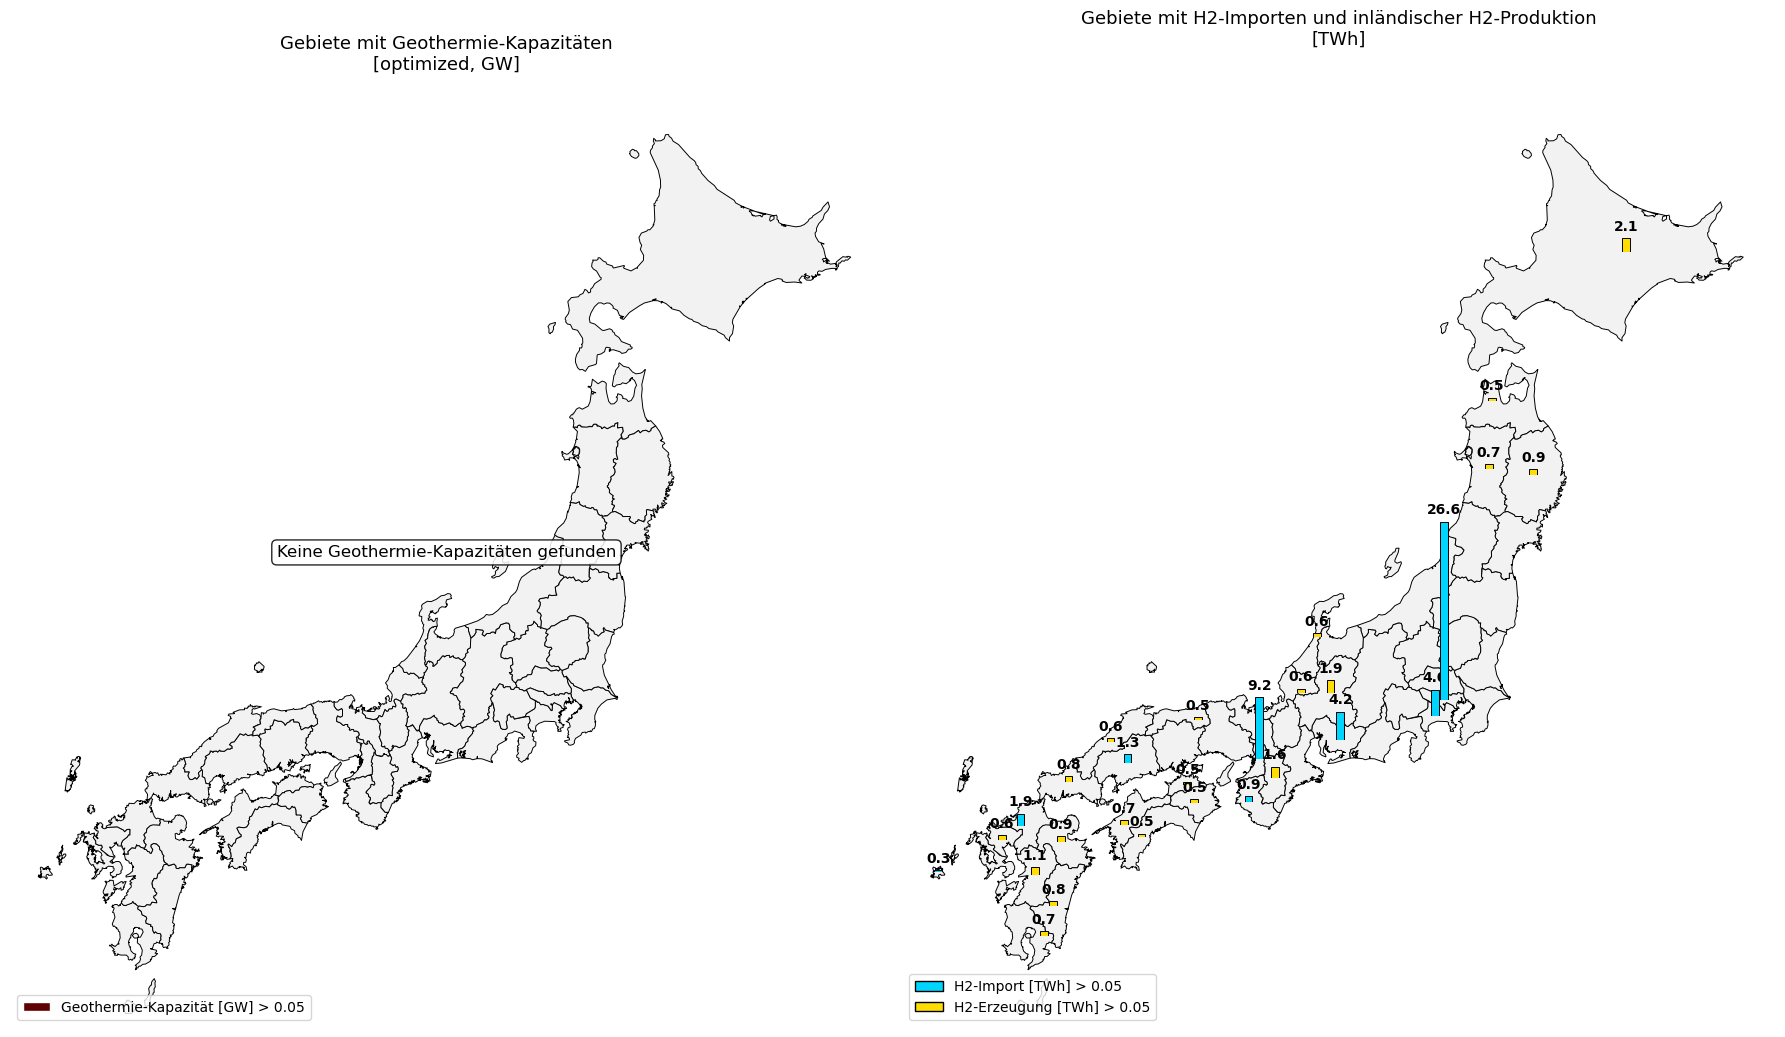

In [63]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs


# ============================================================
# Settings
# ============================================================

# "optimized" = p_nom_opt, also zukünftige / optimierte installierte Leistung
# "current" = p_nom, also heutige / bestehende installierte Leistung
capacity_mode = "optimized"

electric_bus_carriers = ["AC", "DC", "low voltage"]

# Geothermie-Erkennung
geothermal_carrier_regex = r"geothermal"

# H2-Importe werden im Netzwerk über Generator-Namen identifiziert
h2_import_generator_suffix = " import H2 port"

# Inländische H2-Produktion über diese Link-Carrier
h2_prod_carriers = ["H2 Electrolysis", "SMR", "SMR CC"]

# ------------------------------------------------------------
# Schwellenwerte für Anzeige
# ------------------------------------------------------------
# Da Labels mit einer Nachkommastelle angezeigt werden,
# würden Werte kleiner als 0.05 als 0.0 erscheinen.
# Deshalb werden sie nicht angezeigt.
geothermal_threshold_GW = 0.05
h2_threshold_TWh = 0.05

# Einheitliche Kartenfarben
region_fill_color = "#f2f2f2"
region_edge_color = "black"

# Balkenfarben
geo_bar_color = "#610000"          # dunkelblau
geo_bar_edge_color = "white"

h2_import_bar_color = "#00d5ff"    # cyan
h2_domestic_bar_color = "#ffdd00"  # gelb
h2_bar_edge_color = "black"

# Einheitliche Balkengröße für beide Karten
bar_width = 0.04
bar_height = 0.210

geo_bar_width = bar_width
geo_bar_height = bar_height

h2_bar_width = bar_width
h2_bar_height = bar_height

# Textgröße der Balkenbeschriftung
geo_bar_label_fontsize = 10
h2_bar_label_fontsize = 10

# Relevanter Kartenausschnitt Japan
# Reihenfolge: [lon_min, lon_max, lat_min, lat_max]
map_extent = [128.0, 146.5, 30.0, 46.5]


# ============================================================
# Helper functions
# ============================================================

def get_capacity(df, nominal_col="p_nom", mode="optimized"):
    """
    Gibt je nach Modus die installierte Leistung zurück.
    mode='optimized' nutzt p_nom_opt, falls vorhanden.
    mode='current' nutzt p_nom.
    """
    if mode == "optimized":
        opt_col = f"{nominal_col}_opt"

        if opt_col in df.columns:
            capacity = df[opt_col].copy()

            if nominal_col in df.columns:
                capacity = capacity.fillna(df[nominal_col])

            return capacity.fillna(0)

    if nominal_col in df.columns:
        return df[nominal_col].fillna(0)

    return pd.Series(0, index=df.index)


def bus_to_region(bus_name):
    """
    Wandelt PyPSA-Busnamen oder Komponentennamen in GADM-Regionen um.
    """
    s = str(bus_name).strip()

    suffixes = [
        "_AC",
        "_DC",
        " AC",
        " DC",
        " low voltage",
        "_low voltage",
        " heat",
        "_heat",
        " gas",
        "_gas",
        " oil",
        "_oil",
        " coal",
        "_coal",
        " biomass",
        "_biomass",

        # H2-spezifische Suffixe
        " import H2 port",
        "_import H2 port",
        " H2 port",
        "_H2 port",
        " H2",
        "_H2",
        " hydrogen",
        "_hydrogen",
        " import",
        "_import",
    ]

    changed = True

    while changed:
        changed = False

        for suffix in suffixes:
            if s.endswith(suffix):
                s = s[: -len(suffix)].strip()
                changed = True

    return s


def carrier_contains(series, pattern):
    """
    Case-insensitive Regex-Suche für Carrier.
    """
    return (
        series
        .astype(str)
        .str.contains(pattern, case=False, regex=True, na=False)
    )


def sum_series_by_index(series_list):
    """
    Summiert mehrere Series mit gleichem Index-Typ robust zusammen.
    """
    valid_series = [
        s for s in series_list
        if isinstance(s, pd.Series) and not s.empty
    ]

    if not valid_series:
        return pd.Series(dtype=float)

    return (
        pd.concat(valid_series, axis=0)
        .groupby(level=0)
        .sum()
    )


def get_snapshot_weights(n):
    """
    Snapshot-Gewichte robust auslesen.
    Priorität: n.snapshot_weightings.generators.
    """
    if hasattr(n, "snapshot_weightings"):

        if hasattr(n.snapshot_weightings, "generators"):
            return n.snapshot_weightings.generators.reindex(n.snapshots).fillna(1.0)

        if "generators" in n.snapshot_weightings.columns:
            return n.snapshot_weightings["generators"].reindex(n.snapshots).fillna(1.0)

        if hasattr(n.snapshot_weightings, "objective"):
            return n.snapshot_weightings.objective.reindex(n.snapshots).fillna(1.0)

        if "objective" in n.snapshot_weightings.columns:
            return n.snapshot_weightings["objective"].reindex(n.snapshots).fillna(1.0)

    return pd.Series(1.0, index=n.snapshots)


def data_to_axes_fraction(ax, x, y):
    """
    Transformiert Datenkoordinaten lon/lat in Achsenkoordinaten [0, 1].
    """
    display = ax.transData.transform((x, y))
    ax_frac = ax.transAxes.inverted().transform(display)

    return ax_frac


def prepare_chart_positions(
    ax,
    df,
    width,
    height,
    x_col="lon",
    y_col="lat"
):
    """
    Berechnet die Positionen der Mini-Balkendiagramme.
    """
    if df.empty:
        return df.copy()

    tmp = df.copy()

    coords = tmp.apply(
        lambda row: data_to_axes_fraction(ax, row[x_col], row[y_col]),
        axis=1
    )

    tmp["x_ax"] = [c[0] for c in coords]
    tmp["y_ax"] = [c[1] for c in coords]

    tmp = tmp[
        (tmp["x_ax"] >= 0) & (tmp["x_ax"] <= 1) &
        (tmp["y_ax"] >= 0) & (tmp["y_ax"] <= 1)
    ].copy()

    if tmp.empty:
        return tmp

    tmp["chart_left"] = tmp["x_ax"] - width / 2
    tmp["chart_bottom"] = tmp["y_ax"]
    tmp["chart_width"] = width
    tmp["chart_height"] = height

    # Horizontales Clipping am Kartenrand verhindern.
    tmp["chart_left"] = tmp["chart_left"].clip(
        lower=0.002,
        upper=1.0 - width - 0.002
    )

    return tmp


def add_geo_bar_charts(
    ax,
    df,
    value_col="installed_geothermal_capacity_GW",
    width=0.028,
    height=0.210,
    color="#08306b",
    edgecolor="white",
    label_fontsize=5.2,
    threshold=0.05
):
    """
    Fügt kleine Geothermie-Balken direkt auf Regionen ein.

    - Nur Regionen mit Geothermie-Kapazität > threshold.
    - Keine Balken und keine Labels für Werte, die als 0.0 erscheinen würden.
    """
    chart_df = df[df[value_col] > threshold].copy()

    if chart_df.empty:
        return

    chart_df["label_point"] = chart_df.geometry.representative_point()
    chart_df["lon"] = chart_df["label_point"].x
    chart_df["lat"] = chart_df["label_point"].y

    chart_df = prepare_chart_positions(
        ax=ax,
        df=chart_df,
        width=width,
        height=height,
        x_col="lon",
        y_col="lat"
    )

    if chart_df.empty:
        return

    ymax = chart_df[value_col].max()

    if ymax <= threshold:
        return

    for _, row in chart_df.iterrows():
        value = row[value_col]

        if value <= threshold:
            continue

        inset = ax.inset_axes(
            [
                row["chart_left"],
                row["chart_bottom"],
                row["chart_width"],
                row["chart_height"]
            ],
            transform=ax.transAxes
        )

        inset.bar(
            [0],
            [value],
            width=0.20,
            color=color,
            edgecolor=edgecolor,
            linewidth=0.7
        )

        inset.set_ylim(0, ymax * 1.12)
        inset.set_xlim(-0.45, 0.45)

        inset.text(
            0,
            value + ymax * 0.025,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=label_fontsize,
            color="black",
            fontweight="bold"
        )

        inset.set_xticks([])
        inset.set_yticks([])
        inset.set_facecolor("none")
        inset.patch.set_alpha(0)

        for spine in inset.spines.values():
            spine.set_visible(False)

        inset.tick_params(
            left=False,
            bottom=False,
            labelleft=False,
            labelbottom=False
        )


def add_h2_bar_charts(
    ax,
    df,
    import_col="h2_import_TWh",
    domestic_col="h2_domestic_TWh",
    width=0.028,
    height=0.210,
    import_color="#00d5ff",
    domestic_color="#ffdd00",
    edgecolor="black",
    label_fontsize=5.0,
    threshold=0.05
):
    """
    Fügt kleine H2-Balkendiagramme direkt auf Regionen ein.

    - Nur Regionen mit H2-Import oder H2-Produktion > threshold.
    - Einzelne Balken werden nur gezeichnet, wenn ihr Wert > threshold ist.
    - Dadurch werden keine 0.0-Labels mehr angezeigt.
    """
    chart_df = df[
        (df[import_col] > threshold) |
        (df[domestic_col] > threshold)
    ].copy()

    if chart_df.empty:
        return

    chart_df["label_point"] = chart_df.geometry.representative_point()
    chart_df["lon"] = chart_df["label_point"].x
    chart_df["lat"] = chart_df["label_point"].y

    chart_df = prepare_chart_positions(
        ax=ax,
        df=chart_df,
        width=width,
        height=height,
        x_col="lon",
        y_col="lat"
    )

    if chart_df.empty:
        return

    ymax = max(
        chart_df[import_col].max(),
        chart_df[domestic_col].max()
    )

    if ymax <= threshold:
        return

    for _, row in chart_df.iterrows():
        import_value = row[import_col]
        domestic_value = row[domestic_col]

        values = []
        colors = []
        x_positions = []

        if import_value > threshold:
            values.append(import_value)
            colors.append(import_color)
            x_positions.append(-0.16)

        if domestic_value > threshold:
            values.append(domestic_value)
            colors.append(domestic_color)
            x_positions.append(0.16)

        if len(values) == 0:
            continue

        # Falls nur ein Balken vorhanden ist, mittig platzieren.
        if len(values) == 1:
            x_positions = [0]
            bar_width_local = 0.20
        else:
            bar_width_local = 0.18

        inset = ax.inset_axes(
            [
                row["chart_left"],
                row["chart_bottom"],
                row["chart_width"],
                row["chart_height"]
            ],
            transform=ax.transAxes
        )

        inset.bar(
            x_positions,
            values,
            width=bar_width_local,
            color=colors,
            edgecolor=edgecolor,
            linewidth=0.7
        )

        inset.set_ylim(0, ymax * 1.12)
        inset.set_xlim(-0.45, 0.45)

        for x_pos, val in zip(x_positions, values):
            if val <= threshold:
                continue

            inset.text(
                x_pos,
                val + ymax * 0.025,
                f"{val:.1f}",
                ha="center",
                va="bottom",
                fontsize=label_fontsize,
                color="black",
                fontweight="bold"
            )

        inset.set_xticks([])
        inset.set_yticks([])
        inset.set_facecolor("none")
        inset.patch.set_alpha(0)

        for spine in inset.spines.values():
            spine.set_visible(False)

        inset.tick_params(
            left=False,
            bottom=False,
            labelleft=False,
            labelbottom=False
        )


# ============================================================
# 1) Prepare GADM regions
# ============================================================

regions = gadm_shapes.copy()

if regions.crs is None:
    regions = regions.set_crs("EPSG:4326")

regions["region"] = regions["GADM_ID"].astype(str).str.strip()


# ============================================================
# 2) Geothermal capacity from generators
# ============================================================

generator_geo_capacity = pd.Series(dtype=float)

if hasattr(n, "generators") and len(n.generators) > 0:
    generators = n.generators.copy()

    generators = generators[
        carrier_contains(generators.carrier, geothermal_carrier_regex)
    ].copy()

    if not generators.empty:
        generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

        generators = generators[
            generators["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        if not generators.empty:
            generators["capacity_MW"] = get_capacity(
                generators,
                "p_nom",
                mode=capacity_mode
            )

            generators["region"] = generators.bus.map(bus_to_region)

            generator_geo_capacity = (
                generators
                .groupby("region")["capacity_MW"]
                .sum()
            )


# ============================================================
# 3) Geothermal capacity from links
# ============================================================

link_geo_capacity_parts = []

if hasattr(n, "links") and len(n.links) > 0:
    links = n.links.copy()

    links = links[
        carrier_contains(links.carrier, geothermal_carrier_regex)
    ].copy()

    if not links.empty:
        links["p_nom_final"] = get_capacity(
            links,
            "p_nom",
            mode=capacity_mode
        )

        for bus_number in range(1, 6):
            bus_col = f"bus{bus_number}"

            if bus_col not in links.columns:
                continue

            if bus_number == 1:
                efficiency_col = "efficiency"
            else:
                efficiency_col = f"efficiency{bus_number}"

            output_bus_carrier = links[bus_col].map(n.buses.carrier)
            input_bus_carrier = links["bus0"].map(n.buses.carrier)

            mask = (
                output_bus_carrier.isin(electric_bus_carriers)
                & ~input_bus_carrier.isin(electric_bus_carriers)
            )

            if not mask.any():
                continue

            selected_links = links.loc[mask].copy()

            if efficiency_col in links.columns:
                if bus_number == 1:
                    efficiency = links.loc[mask, efficiency_col].fillna(1)
                else:
                    efficiency = links.loc[mask, efficiency_col].fillna(0)
            else:
                efficiency = 1 if bus_number == 1 else 0

            selected_links["capacity_MW"] = (
                selected_links["p_nom_final"] * efficiency
            )

            selected_links["region"] = selected_links[bus_col].map(bus_to_region)

            tmp = (
                selected_links
                .groupby("region")["capacity_MW"]
                .sum()
            )

            link_geo_capacity_parts.append(tmp)


link_geo_capacity = sum_series_by_index(link_geo_capacity_parts)


# ============================================================
# 4) Merge geothermal capacity onto regions
# ============================================================

installed_geo_capacity_by_region = sum_series_by_index(
    [
        generator_geo_capacity,
        link_geo_capacity,
    ]
)

regions["installed_geothermal_capacity_MW"] = (
    regions["region"]
    .map(installed_geo_capacity_by_region)
    .fillna(0)
)

regions["installed_geothermal_capacity_GW"] = (
    regions["installed_geothermal_capacity_MW"] / 1e3
)

regions["has_geothermal_capacity"] = (
    regions["installed_geothermal_capacity_GW"] > geothermal_threshold_GW
)


# ============================================================
# 5) H2 imports and domestic H2 production by region
# ============================================================

weights = get_snapshot_weights(n)


# ------------------------------------------------------------
# 5a) H2 imports from generators
# ------------------------------------------------------------

h2_import_gens = n.generators.index[
    n.generators.index.astype(str).str.endswith(h2_import_generator_suffix)
]

if (
    len(h2_import_gens) > 0
    and hasattr(n, "generators_t")
    and hasattr(n.generators_t, "p")
):
    available_h2_import_gens = h2_import_gens.intersection(
        n.generators_t.p.columns
    )

    h2_import_mwh_by_generator = (
        n.generators_t.p[available_h2_import_gens]
        .clip(lower=0)
        .multiply(weights, axis=0)
        .sum()
    )
else:
    h2_import_mwh_by_generator = pd.Series(dtype=float)


if not h2_import_mwh_by_generator.empty:
    h2_import_regions_from_bus = (
        n.generators
        .loc[h2_import_mwh_by_generator.index, "bus"]
        .map(bus_to_region)
    )

    h2_import_regions_from_name = pd.Series(
        h2_import_mwh_by_generator.index,
        index=h2_import_mwh_by_generator.index
    ).map(bus_to_region)

    valid_region_ids = set(regions["region"])

    h2_import_regions = h2_import_regions_from_bus.where(
        h2_import_regions_from_bus.isin(valid_region_ids),
        h2_import_regions_from_name
    )

    h2_import_mwh_by_region = (
        pd.DataFrame({
            "region": h2_import_regions,
            "h2_import_MWh": h2_import_mwh_by_generator
        })
        .groupby("region")["h2_import_MWh"]
        .sum()
    )
else:
    h2_import_mwh_by_region = pd.Series(dtype=float)


# ------------------------------------------------------------
# 5b) H2 buses
# ------------------------------------------------------------

h2_buses = n.buses.index[
    n.buses.carrier == "H2"
]


# ------------------------------------------------------------
# 5c) Domestic H2 production from links
# H2 output is usually on bus1 and p1 is negative.
# Therefore: -p1
# ------------------------------------------------------------

h2_prod_links = n.links.index[
    (n.links.carrier.isin(h2_prod_carriers)) &
    (n.links.bus1.isin(h2_buses))
]

if (
    len(h2_prod_links) > 0
    and hasattr(n, "links_t")
    and hasattr(n.links_t, "p1")
):
    available_h2_prod_links = h2_prod_links.intersection(
        n.links_t.p1.columns
    )

    h2_domestic_mwh_by_link = (
        (-n.links_t.p1[available_h2_prod_links])
        .clip(lower=0)
        .multiply(weights, axis=0)
        .sum()
    )
else:
    h2_domestic_mwh_by_link = pd.Series(dtype=float)


if not h2_domestic_mwh_by_link.empty:
    h2_domestic_regions = (
        n.links
        .loc[h2_domestic_mwh_by_link.index, "bus1"]
        .map(bus_to_region)
    )

    h2_domestic_mwh_by_region = (
        pd.DataFrame({
            "region": h2_domestic_regions,
            "h2_domestic_MWh": h2_domestic_mwh_by_link
        })
        .groupby("region")["h2_domestic_MWh"]
        .sum()
    )
else:
    h2_domestic_mwh_by_region = pd.Series(dtype=float)


# ------------------------------------------------------------
# 5d) Merge H2 values onto GADM regions
# ------------------------------------------------------------

regions["h2_import_MWh"] = (
    regions["region"]
    .map(h2_import_mwh_by_region)
    .fillna(0)
)

regions["h2_domestic_MWh"] = (
    regions["region"]
    .map(h2_domestic_mwh_by_region)
    .fillna(0)
)

regions["h2_import_TWh"] = regions["h2_import_MWh"] / 1e6
regions["h2_domestic_TWh"] = regions["h2_domestic_MWh"] / 1e6

regions["has_h2_import"] = regions["h2_import_TWh"] > h2_threshold_TWh
regions["has_h2_domestic_production"] = (
    regions["h2_domestic_TWh"] > h2_threshold_TWh
)

regions["has_any_h2"] = (
    regions["has_h2_import"] |
    regions["has_h2_domestic_production"]
)


# ============================================================
# 6) Plot two maps side by side
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 10),
    subplot_kw={"projection": ccrs.PlateCarree()}
)


# ------------------------------------------------------------
# Left map: geothermal capacity as bars only
# ------------------------------------------------------------

regions.plot(
    ax=axes[0],
    color=region_fill_color,
    linewidth=0.7,
    edgecolor=region_edge_color,
    transform=ccrs.PlateCarree()
)

if not regions["has_geothermal_capacity"].any():
    axes[0].text(
        0.5,
        0.5,
        "Keine Geothermie-Kapazitäten gefunden",
        transform=axes[0].transAxes,
        ha="center",
        va="center",
        fontsize=12,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )

axes[0].set_title(
    f"Gebiete mit Geothermie-Kapazitäten\n[{capacity_mode}, GW]",
    fontsize=13
)

axes[0].set_extent(map_extent, crs=ccrs.PlateCarree())
axes[0].axis("off")


# ------------------------------------------------------------
# Right map: H2 import and domestic H2 production as bars only
# ------------------------------------------------------------

regions.plot(
    ax=axes[1],
    color=region_fill_color,
    linewidth=0.7,
    edgecolor=region_edge_color,
    transform=ccrs.PlateCarree()
)

if not regions["has_any_h2"].any():
    axes[1].text(
        0.5,
        0.5,
        "Keine H2-Importe oder H2-Produktion gefunden",
        transform=axes[1].transAxes,
        ha="center",
        va="center",
        fontsize=12,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )

axes[1].set_title(
    "Gebiete mit H2-Importen und inländischer H2-Produktion\n[TWh]",
    fontsize=13
)

axes[1].set_extent(map_extent, crs=ccrs.PlateCarree())
axes[1].axis("off")


# ------------------------------------------------------------
# Wichtig: Canvas zuerst zeichnen, damit Koordinaten stimmen
# ------------------------------------------------------------

fig.canvas.draw()


# ------------------------------------------------------------
# Add bar charts directly on regions
# ------------------------------------------------------------

add_geo_bar_charts(
    ax=axes[0],
    df=regions,
    value_col="installed_geothermal_capacity_GW",
    width=geo_bar_width,
    height=geo_bar_height,
    color=geo_bar_color,
    edgecolor=geo_bar_edge_color,
    label_fontsize=geo_bar_label_fontsize,
    threshold=geothermal_threshold_GW
)

add_h2_bar_charts(
    ax=axes[1],
    df=regions,
    import_col="h2_import_TWh",
    domestic_col="h2_domestic_TWh",
    width=h2_bar_width,
    height=h2_bar_height,
    import_color=h2_import_bar_color,
    domestic_color=h2_domestic_bar_color,
    edgecolor=h2_bar_edge_color,
    label_fontsize=h2_bar_label_fontsize,
    threshold=h2_threshold_TWh
)


# ============================================================
# 7) Legends
# ============================================================

geo_legend_handles = [
    mpatches.Patch(
        facecolor=geo_bar_color,
        edgecolor=geo_bar_edge_color,
        label=f"Geothermie-Kapazität [GW] > {geothermal_threshold_GW}"
    )
]

axes[0].legend(
    handles=geo_legend_handles,
    loc="lower left",
    fontsize=10,
    frameon=True
)

h2_legend_handles = [
    mpatches.Patch(
        facecolor=h2_import_bar_color,
        edgecolor=h2_bar_edge_color,
        label=f"H2-Import [TWh] > {h2_threshold_TWh}"
    ),
    mpatches.Patch(
        facecolor=h2_domestic_bar_color,
        edgecolor=h2_bar_edge_color,
        label=f"H2-Erzeugung [TWh] > {h2_threshold_TWh}"
    ),
]

axes[1].legend(
    handles=h2_legend_handles,
    loc="lower left",
    fontsize=10,
    frameon=True
)


plt.tight_layout()
plt.show()

------------------------------------------------------------
Feine Simulationsregionen
------------------------------------------------------------
GADM-Level: 1
Anzahl feine Regionen: 47
Verwendete ID-Spalte für Netzwerk-Mapping: GID_1
Beispiele für normalisierte region IDs:
['JP.1_1', 'JP.2_1', 'JP.3_1', 'JP.4_1', 'JP.5_1', 'JP.6_1', 'JP.7_1', 'JP.8_1', 'JP.9_1', 'JP.10_1']
------------------------------------------------------------
Vergleich Shape-IDs und Netzwerk-Bus-IDs
------------------------------------------------------------
Shape region examples:
['JP.10_1', 'JP.11_1', 'JP.12_1', 'JP.13_1', 'JP.14_1', 'JP.15_1', 'JP.16_1', 'JP.17_1', 'JP.18_1', 'JP.19_1']

Network region examples:
['Earth lignite', 'H2 export bus', 'JP.10_1', 'JP.10_1_AC EV battery', 'JP.10_1_AC battery', 'JP.10_1_AC biogas', 'JP.10_1_AC co2 stored', 'JP.10_1_AC gas for industry', 'JP.10_1_AC home battery', 'JP.10_1_AC residential rural']

Overlap Shape / Netzwerk: 47 Regionen
['JP.10_1', 'JP.11_1', 'JP.12_

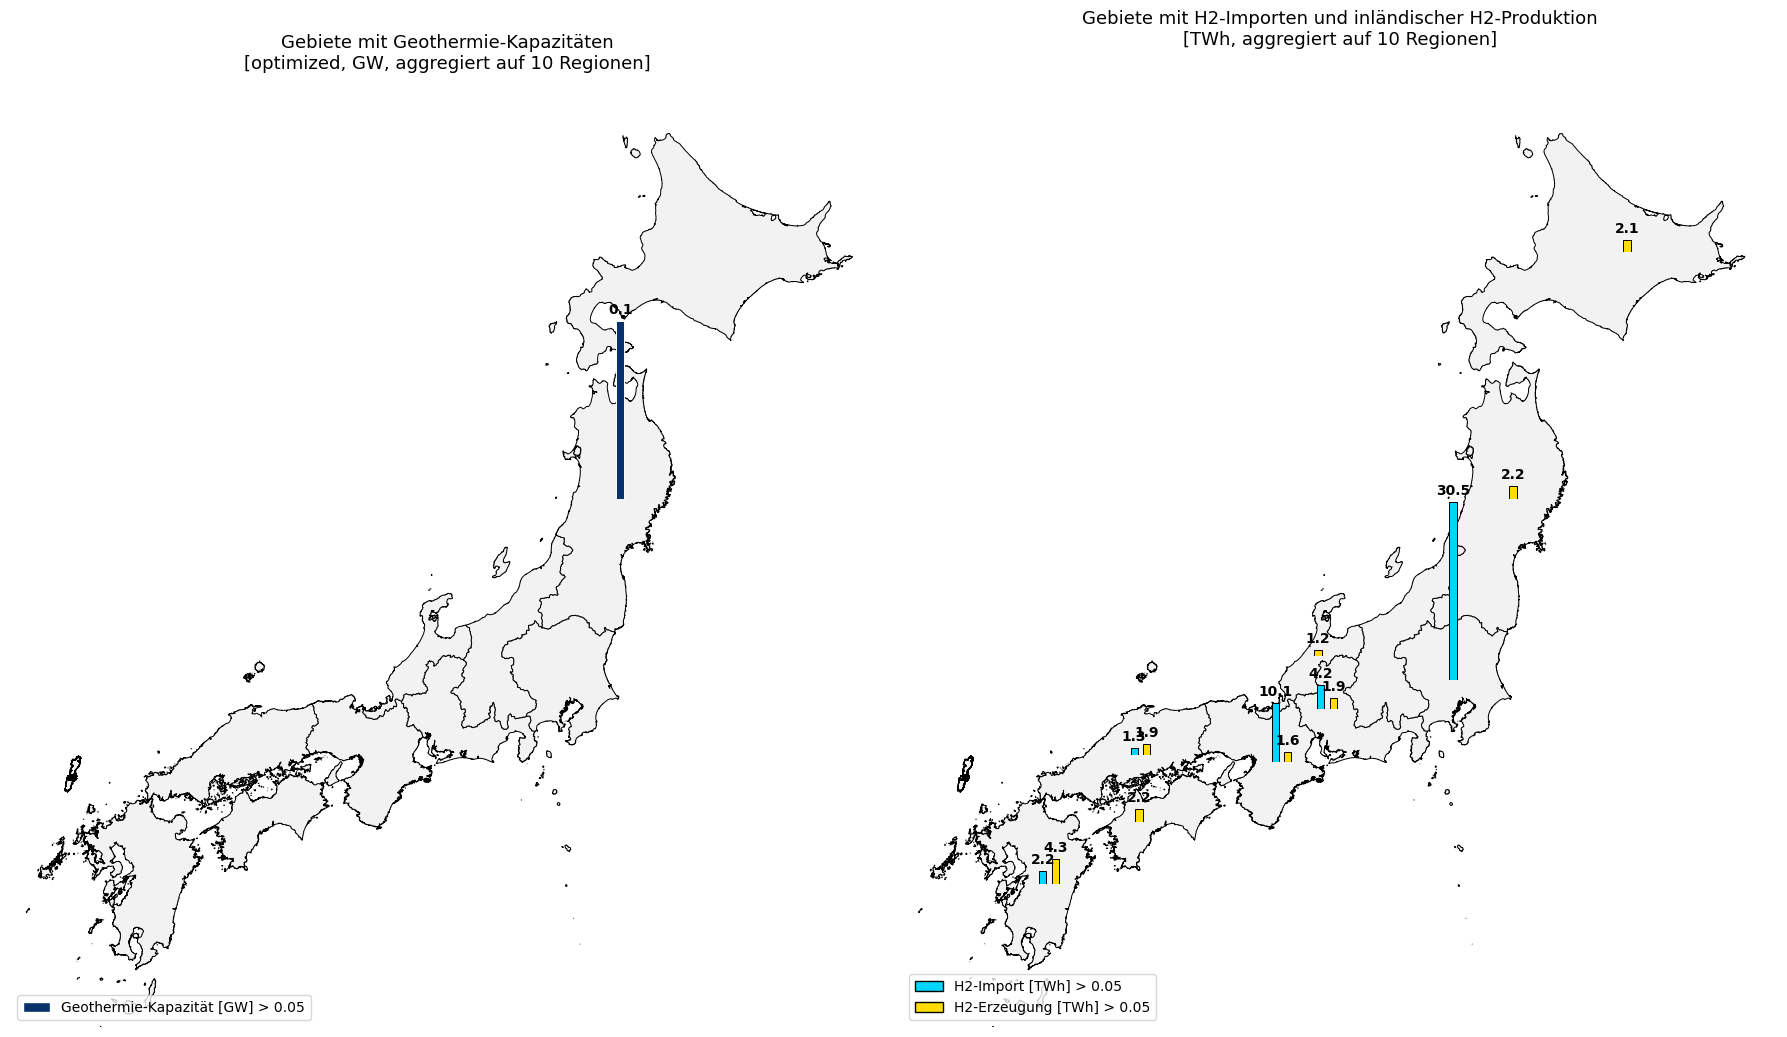

In [64]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import fiona


# ============================================================
# Settings
# ============================================================

# "optimized" = p_nom_opt, also zukünftige / optimierte installierte Leistung
# "current" = p_nom, also heutige / bestehende installierte Leistung
capacity_mode = "optimized"

electric_bus_carriers = ["AC", "DC", "low voltage"]

# Geothermie-Erkennung
geothermal_carrier_regex = r"geothermal"

# H2-Importe werden im Netzwerk über Generator-Namen identifiziert
h2_import_generator_suffix = " import H2 port"

# Inländische H2-Produktion über diese Link-Carrier
h2_prod_carriers = ["H2 Electrolysis", "SMR", "SMR CC"]

# ------------------------------------------------------------
# GADM / Aggregation
# ------------------------------------------------------------

# True:
# Netzwerk wird auf feiner Ebene ausgewertet,
# Karte wird auf grobe 10 Regionen aggregiert.
aggregate_to_coarse_regions = True

# 10-Regionen-GPKG
coarse_gadm_path = (
    "/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/data/gadm/gadm41_JPN/old/OUTPUT.gpkg"
)

# Simulations-GPKG
# Level 1 = 47 Regionen
# Level 2 = feinere GADM-02-Regionen
fine_gadm_path = (
    "/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/data/gadm/gadm41_JPN/gadm41_JPN.gpkg"
)

# 1 = 47 Regionen
# 2 = GADM-02
simulation_gadm_level = 1

# Grobe Darstellungsebene: 10 Regionen
coarse_gadm_level = 1

# Im 10er-GPKG ist NAME_1 die grobe Region:
# Tokai, Tohoku, Hokkaido, Kinki, ...
coarse_region_id_col = "NAME_1"

# Falls du später zusätzliche additive Spalten aggregieren willst,
# kannst du sie hier ergänzen, sobald sie auf regions existieren.
extra_value_cols_to_aggregate = []

# ------------------------------------------------------------
# Schwellenwerte für Anzeige
# ------------------------------------------------------------

geothermal_threshold_GW = 0.05
h2_threshold_TWh = 0.05

# Einheitliche Kartenfarben
region_fill_color = "#f2f2f2"
region_edge_color = "black"

# Balkenfarben
geo_bar_color = "#08306b"
geo_bar_edge_color = "white"

h2_import_bar_color = "#00d5ff"
h2_domestic_bar_color = "#ffdd00"
h2_bar_edge_color = "black"

# Einheitliche Balkengröße für beide Karten
bar_width = 0.04
bar_height = 0.210

geo_bar_width = bar_width
geo_bar_height = bar_height

h2_bar_width = bar_width
h2_bar_height = bar_height

# Textgröße der Balkenbeschriftung
geo_bar_label_fontsize = 10
h2_bar_label_fontsize = 10

# Relevanter Kartenausschnitt Japan
# Reihenfolge: [lon_min, lon_max, lat_min, lat_max]
map_extent = [128.0, 146.5, 30.0, 46.5]


# ============================================================
# Helper functions: GADM / GeoPackage
# ============================================================

def find_gadm_layer(gpkg_path, gadm_level):
    """
    Findet automatisch den passenden GADM-Layer in einem GeoPackage.

    Funktioniert für Layernamen wie:
      - ADM_ADM_1
      - gadm41_JPN — ADM_ADM_1
    """
    target = f"ADM_ADM_{gadm_level}"
    layers = fiona.listlayers(gpkg_path)

    matches = [
        layer for layer in layers
        if layer.endswith(target) or target in layer
    ]

    if not matches:
        raise ValueError(
            f"Kein Layer für {target} in {gpkg_path} gefunden. "
            f"Vorhandene Layer: {layers}"
        )

    return matches[0]


def read_gadm_layer(gpkg_path, gadm_level):
    """
    Liest einen GADM-Layer aus einem GeoPackage.
    """
    layer = find_gadm_layer(gpkg_path, gadm_level)

    gdf = gpd.read_file(
        gpkg_path,
        layer=layer
    )

    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")

    return gdf


def infer_gadm_id_col(gdf, gadm_level):
    """
    Findet die passende ID-Spalte für die Simulationsregionen.
    """
    candidates = [
        "GADM_ID",
        f"GID_{gadm_level}",
        "GID_2",
        "GID_1",
        "region",
        "name",
        "Name",
        "NAME_2",
        "NAME_1",
    ]

    for col in candidates:
        if col in gdf.columns:
            return col

    raise ValueError(
        "Keine passende Regions-ID-Spalte gefunden. "
        f"Vorhandene Spalten: {list(gdf.columns)}"
    )


def sjoin_compat(left, right, how="left", predicate="within"):
    """
    Kompatibilität für verschiedene GeoPandas-Versionen.
    Neuere Versionen nutzen predicate=..., ältere op=...
    """
    try:
        return gpd.sjoin(
            left,
            right,
            how=how,
            predicate=predicate
        )
    except TypeError:
        return gpd.sjoin(
            left,
            right,
            how=how,
            op=predicate
        )


def aggregate_fine_regions_to_coarse_regions(
    fine_regions,
    coarse_regions,
    value_cols,
    fine_region_col="region",
    coarse_region_col="coarse_region",
    target_crs="EPSG:4326"
):
    """
    Aggregiert additive Werte von feinen Simulationsregionen
    auf grobe Darstellungsregionen.

    Geeignet für:
      - installierte Kapazitäten
      - technische Potenziale
      - H2-Importe
      - H2-Produktion
      - Energieflüsse

    Nicht direkt geeignet für:
      - LCOE
      - Kapazitätsfaktoren
      - spezifische Kosten
    """
    fine = fine_regions.copy()
    coarse = coarse_regions.copy()

    if fine.crs is None:
        fine = fine.set_crs(target_crs)

    if coarse.crs is None:
        coarse = coarse.set_crs(target_crs)

    fine = fine.to_crs(target_crs)
    coarse = coarse.to_crs(target_crs)

    existing_value_cols = [
        col for col in value_cols
        if col in fine.columns
    ]

    missing_value_cols = [
        col for col in value_cols
        if col not in fine.columns
    ]

    if missing_value_cols:
        print("Hinweis: Diese Spalten wurden nicht gefunden und nicht aggregiert:")
        print(missing_value_cols)

    if not existing_value_cols:
        raise ValueError("Keine vorhandenen Wertespalten für die Aggregation gefunden.")

    fine_points = fine[[fine_region_col, "geometry"]].copy()
    fine_points["geometry"] = fine_points.geometry.representative_point()

    mapping = sjoin_compat(
        fine_points,
        coarse[[coarse_region_col, "geometry"]],
        how="left",
        predicate="within"
    )

    mapping = mapping[[fine_region_col, coarse_region_col]].drop_duplicates()

    missing = mapping[mapping[coarse_region_col].isna()]

    if not missing.empty:
        print("Warnung: Einige feine Regionen konnten keiner groben Region zugeordnet werden:")
        print(missing[fine_region_col].tolist())

    fine_values = fine[[fine_region_col] + existing_value_cols].copy()

    merged = fine_values.merge(
        mapping,
        on=fine_region_col,
        how="left"
    )

    aggregated = (
        merged
        .dropna(subset=[coarse_region_col])
        .groupby(coarse_region_col)[existing_value_cols]
        .sum()
        .reset_index()
    )

    result = coarse.merge(
        aggregated,
        on=coarse_region_col,
        how="left"
    )

    for col in existing_value_cols:
        result[col] = result[col].fillna(0)

    return result


# ============================================================
# Helper functions: PyPSA Auswertung
# ============================================================

def get_capacity(df, nominal_col="p_nom", mode="optimized"):
    """
    Gibt je nach Modus die installierte Leistung zurück.

    mode='optimized' nutzt p_nom_opt, falls vorhanden.
    mode='current' nutzt p_nom.
    """
    if mode == "optimized":
        opt_col = f"{nominal_col}_opt"

        if opt_col in df.columns:
            capacity = df[opt_col].copy()

            if nominal_col in df.columns:
                capacity = capacity.fillna(df[nominal_col])

            return capacity.fillna(0)

    if nominal_col in df.columns:
        return df[nominal_col].fillna(0)

    return pd.Series(0, index=df.index)


def bus_to_region(bus_name):
    """
    Entfernt typische PyPSA-Earth-Suffixe aus Busnamen oder Komponentennamen.

    Beispiel:
      JP.13_1_AC          -> JP.13_1
      JP.13_1 AC          -> JP.13_1
      JP.13_1 heat        -> JP.13_1
      JP.13_1 import H2 port -> JP.13_1
    """
    s = str(bus_name).strip()

    suffixes = [
        "_AC",
        "_DC",
        " AC",
        " DC",
        " low voltage",
        "_low voltage",
        " heat",
        "_heat",
        " gas",
        "_gas",
        " oil",
        "_oil",
        " coal",
        "_coal",
        " biomass",
        "_biomass",

        # H2-spezifische Suffixe
        " import H2 port",
        "_import H2 port",
        " H2 port",
        "_H2 port",
        " H2",
        "_H2",
        " hydrogen",
        "_hydrogen",
        " import",
        "_import",
    ]

    changed = True

    while changed:
        changed = False

        for suffix in suffixes:
            if s.endswith(suffix):
                s = s[: -len(suffix)].strip()
                changed = True

    return s


def normalize_region_id(region_id):
    """
    Vereinheitlicht GADM-/PyPSA-Regions-IDs.

    Wichtig für deinen Fall:
      Shape:     JPN.13_1
      Netzwerk:  JP.13_1_AC

    Beide werden zu:
      JP.13_1
    """
    s = bus_to_region(region_id)

    if s.startswith("JPN."):
        s = "JP." + s[len("JPN."):]

    return s.strip()


def carrier_contains(series, pattern):
    """
    Case-insensitive Regex-Suche für Carrier.
    """
    return (
        series
        .astype(str)
        .str.contains(pattern, case=False, regex=True, na=False)
    )


def sum_series_by_index(series_list):
    """
    Summiert mehrere Series mit gleichem Index-Typ robust zusammen.
    """
    valid_series = [
        s for s in series_list
        if isinstance(s, pd.Series) and not s.empty
    ]

    if not valid_series:
        return pd.Series(dtype=float)

    return (
        pd.concat(valid_series, axis=0)
        .groupby(level=0)
        .sum()
    )


def get_snapshot_weights(n):
    """
    Snapshot-Gewichte robust auslesen.
    Priorität: n.snapshot_weightings.generators.
    """
    if hasattr(n, "snapshot_weightings"):

        if hasattr(n.snapshot_weightings, "generators"):
            return n.snapshot_weightings.generators.reindex(n.snapshots).fillna(1.0)

        if "generators" in n.snapshot_weightings.columns:
            return n.snapshot_weightings["generators"].reindex(n.snapshots).fillna(1.0)

        if hasattr(n.snapshot_weightings, "objective"):
            return n.snapshot_weightings.objective.reindex(n.snapshots).fillna(1.0)

        if "objective" in n.snapshot_weightings.columns:
            return n.snapshot_weightings["objective"].reindex(n.snapshots).fillna(1.0)

    return pd.Series(1.0, index=n.snapshots)


# ============================================================
# Helper functions: Plot
# ============================================================

def data_to_axes_fraction(ax, x, y):
    """
    Transformiert Datenkoordinaten lon/lat in Achsenkoordinaten [0, 1].
    """
    display = ax.transData.transform((x, y))
    ax_frac = ax.transAxes.inverted().transform(display)

    return ax_frac


def prepare_chart_positions(
    ax,
    df,
    width,
    height,
    x_col="lon",
    y_col="lat"
):
    """
    Berechnet die Positionen der Mini-Balkendiagramme.
    """
    if df.empty:
        return df.copy()

    tmp = df.copy()

    coords = tmp.apply(
        lambda row: data_to_axes_fraction(ax, row[x_col], row[y_col]),
        axis=1
    )

    tmp["x_ax"] = [c[0] for c in coords]
    tmp["y_ax"] = [c[1] for c in coords]

    tmp = tmp[
        (tmp["x_ax"] >= 0) & (tmp["x_ax"] <= 1) &
        (tmp["y_ax"] >= 0) & (tmp["y_ax"] <= 1)
    ].copy()

    if tmp.empty:
        return tmp

    tmp["chart_left"] = tmp["x_ax"] - width / 2
    tmp["chart_bottom"] = tmp["y_ax"]
    tmp["chart_width"] = width
    tmp["chart_height"] = height

    tmp["chart_left"] = tmp["chart_left"].clip(
        lower=0.002,
        upper=1.0 - width - 0.002
    )

    return tmp


def add_geo_bar_charts(
    ax,
    df,
    value_col="installed_geothermal_capacity_GW",
    width=0.028,
    height=0.210,
    color="#08306b",
    edgecolor="white",
    label_fontsize=5.2,
    threshold=0.05
):
    """
    Fügt kleine Geothermie-Balken direkt auf Regionen ein.
    """
    chart_df = df[df[value_col] > threshold].copy()

    if chart_df.empty:
        return

    chart_df["label_point"] = chart_df.geometry.representative_point()
    chart_df["lon"] = chart_df["label_point"].x
    chart_df["lat"] = chart_df["label_point"].y

    chart_df = prepare_chart_positions(
        ax=ax,
        df=chart_df,
        width=width,
        height=height,
        x_col="lon",
        y_col="lat"
    )

    if chart_df.empty:
        return

    ymax = chart_df[value_col].max()

    if ymax <= threshold:
        return

    for _, row in chart_df.iterrows():
        value = row[value_col]

        if value <= threshold:
            continue

        inset = ax.inset_axes(
            [
                row["chart_left"],
                row["chart_bottom"],
                row["chart_width"],
                row["chart_height"]
            ],
            transform=ax.transAxes
        )

        inset.bar(
            [0],
            [value],
            width=0.20,
            color=color,
            edgecolor=edgecolor,
            linewidth=0.7
        )

        inset.set_ylim(0, ymax * 1.12)
        inset.set_xlim(-0.45, 0.45)

        inset.text(
            0,
            value + ymax * 0.025,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=label_fontsize,
            color="black",
            fontweight="bold"
        )

        inset.set_xticks([])
        inset.set_yticks([])
        inset.set_facecolor("none")
        inset.patch.set_alpha(0)

        for spine in inset.spines.values():
            spine.set_visible(False)

        inset.tick_params(
            left=False,
            bottom=False,
            labelleft=False,
            labelbottom=False
        )


def add_h2_bar_charts(
    ax,
    df,
    import_col="h2_import_TWh",
    domestic_col="h2_domestic_TWh",
    width=0.028,
    height=0.210,
    import_color="#00d5ff",
    domestic_color="#ffdd00",
    edgecolor="black",
    label_fontsize=5.0,
    threshold=0.05
):
    """
    Fügt kleine H2-Balkendiagramme direkt auf Regionen ein.
    """
    chart_df = df[
        (df[import_col] > threshold) |
        (df[domestic_col] > threshold)
    ].copy()

    if chart_df.empty:
        return

    chart_df["label_point"] = chart_df.geometry.representative_point()
    chart_df["lon"] = chart_df["label_point"].x
    chart_df["lat"] = chart_df["label_point"].y

    chart_df = prepare_chart_positions(
        ax=ax,
        df=chart_df,
        width=width,
        height=height,
        x_col="lon",
        y_col="lat"
    )

    if chart_df.empty:
        return

    ymax = max(
        chart_df[import_col].max(),
        chart_df[domestic_col].max()
    )

    if ymax <= threshold:
        return

    for _, row in chart_df.iterrows():
        import_value = row[import_col]
        domestic_value = row[domestic_col]

        values = []
        colors = []
        x_positions = []

        if import_value > threshold:
            values.append(import_value)
            colors.append(import_color)
            x_positions.append(-0.16)

        if domestic_value > threshold:
            values.append(domestic_value)
            colors.append(domestic_color)
            x_positions.append(0.16)

        if len(values) == 0:
            continue

        if len(values) == 1:
            x_positions = [0]
            bar_width_local = 0.20
        else:
            bar_width_local = 0.18

        inset = ax.inset_axes(
            [
                row["chart_left"],
                row["chart_bottom"],
                row["chart_width"],
                row["chart_height"]
            ],
            transform=ax.transAxes
        )

        inset.bar(
            x_positions,
            values,
            width=bar_width_local,
            color=colors,
            edgecolor=edgecolor,
            linewidth=0.7
        )

        inset.set_ylim(0, ymax * 1.12)
        inset.set_xlim(-0.45, 0.45)

        for x_pos, val in zip(x_positions, values):
            if val <= threshold:
                continue

            inset.text(
                x_pos,
                val + ymax * 0.025,
                f"{val:.1f}",
                ha="center",
                va="bottom",
                fontsize=label_fontsize,
                color="black",
                fontweight="bold"
            )

        inset.set_xticks([])
        inset.set_yticks([])
        inset.set_facecolor("none")
        inset.patch.set_alpha(0)

        for spine in inset.spines.values():
            spine.set_visible(False)

        inset.tick_params(
            left=False,
            bottom=False,
            labelleft=False,
            labelbottom=False
        )


# ============================================================
# 1) Prepare fine simulation regions
# ============================================================

regions = read_gadm_layer(
    fine_gadm_path,
    simulation_gadm_level
)

if regions.crs is None:
    regions = regions.set_crs("EPSG:4326")

fine_region_id_col = infer_gadm_id_col(
    regions,
    simulation_gadm_level
)

regions["region"] = (
    regions[fine_region_id_col]
    .astype(str)
    .map(normalize_region_id)
)

print("------------------------------------------------------------")
print("Feine Simulationsregionen")
print("------------------------------------------------------------")
print(f"GADM-Level: {simulation_gadm_level}")
print(f"Anzahl feine Regionen: {len(regions)}")
print(f"Verwendete ID-Spalte für Netzwerk-Mapping: {fine_region_id_col}")
print("Beispiele für normalisierte region IDs:")
print(regions["region"].head(10).tolist())


# ============================================================
# 1b) Debug: Vergleich Shape-IDs und Netzwerk-Bus-IDs
# ============================================================

print("------------------------------------------------------------")
print("Vergleich Shape-IDs und Netzwerk-Bus-IDs")
print("------------------------------------------------------------")

shape_region_set = set(regions["region"])

network_region_set = set(
    pd.Series(n.buses.index)
    .map(normalize_region_id)
)

overlap = shape_region_set.intersection(network_region_set)

print("Shape region examples:")
print(sorted(list(shape_region_set))[:10])

print("")
print("Network region examples:")
print(sorted(list(network_region_set))[:10])

print("")
print(f"Overlap Shape / Netzwerk: {len(overlap)} Regionen")
print(sorted(list(overlap))[:20])

if len(overlap) == 0:
    print("")
    print("WARNUNG: Keine Überschneidung zwischen Shape-IDs und Netzwerk-Bus-IDs.")
    print("Dann können keine Werte auf die Regionen gemappt werden.")


# ============================================================
# 2) Geothermal capacity from generators
# ============================================================

generator_geo_capacity = pd.Series(dtype=float)

if hasattr(n, "generators") and len(n.generators) > 0:
    generators = n.generators.copy()

    generators = generators[
        carrier_contains(generators.carrier, geothermal_carrier_regex)
    ].copy()

    print("")
    print("------------------------------------------------------------")
    print("Geothermie-Generatoren")
    print("------------------------------------------------------------")
    print(f"Gefundene Geothermie-Generatoren: {len(generators)}")

    if not generators.empty:
        generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

        generators = generators[
            generators["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        print(f"Geothermie-Generatoren auf elektrischen Bussen: {len(generators)}")

        if not generators.empty:
            generators["capacity_MW"] = get_capacity(
                generators,
                "p_nom",
                mode=capacity_mode
            )

            generators["region"] = generators.bus.map(normalize_region_id)

            generator_geo_capacity = (
                generators
                .groupby("region")["capacity_MW"]
                .sum()
            )

            print("Geothermie-Generator-Kapazität vor Shape-Mapping [MW]:")
            print(generator_geo_capacity.sort_values(ascending=False).head(10).to_string())


# ============================================================
# 3) Geothermal capacity from links
# ============================================================

link_geo_capacity_parts = []

if hasattr(n, "links") and len(n.links) > 0:
    links = n.links.copy()

    links = links[
        carrier_contains(links.carrier, geothermal_carrier_regex)
    ].copy()

    print("")
    print("------------------------------------------------------------")
    print("Geothermie-Links")
    print("------------------------------------------------------------")
    print(f"Gefundene Geothermie-Links: {len(links)}")

    if not links.empty:
        links["p_nom_final"] = get_capacity(
            links,
            "p_nom",
            mode=capacity_mode
        )

        for bus_number in range(1, 6):
            bus_col = f"bus{bus_number}"

            if bus_col not in links.columns:
                continue

            if bus_number == 1:
                efficiency_col = "efficiency"
            else:
                efficiency_col = f"efficiency{bus_number}"

            output_bus_carrier = links[bus_col].map(n.buses.carrier)
            input_bus_carrier = links["bus0"].map(n.buses.carrier)

            mask = (
                output_bus_carrier.isin(electric_bus_carriers)
                & ~input_bus_carrier.isin(electric_bus_carriers)
            )

            if not mask.any():
                continue

            selected_links = links.loc[mask].copy()

            if efficiency_col in links.columns:
                if bus_number == 1:
                    efficiency = links.loc[mask, efficiency_col].fillna(1)
                else:
                    efficiency = links.loc[mask, efficiency_col].fillna(0)
            else:
                efficiency = 1 if bus_number == 1 else 0

            selected_links["capacity_MW"] = (
                selected_links["p_nom_final"] * efficiency
            )

            selected_links["region"] = selected_links[bus_col].map(normalize_region_id)

            tmp = (
                selected_links
                .groupby("region")["capacity_MW"]
                .sum()
            )

            link_geo_capacity_parts.append(tmp)


link_geo_capacity = sum_series_by_index(link_geo_capacity_parts)

if not link_geo_capacity.empty:
    print("Geothermie-Link-Kapazität vor Shape-Mapping [MW]:")
    print(link_geo_capacity.sort_values(ascending=False).head(10).to_string())


# ============================================================
# 4) Merge geothermal capacity onto fine regions
# ============================================================

installed_geo_capacity_by_region = sum_series_by_index(
    [
        generator_geo_capacity,
        link_geo_capacity,
    ]
)

regions["installed_geothermal_capacity_MW"] = (
    regions["region"]
    .map(installed_geo_capacity_by_region)
    .fillna(0)
)

regions["installed_geothermal_capacity_GW"] = (
    regions["installed_geothermal_capacity_MW"] / 1e3
)

regions["has_geothermal_capacity"] = (
    regions["installed_geothermal_capacity_GW"] > geothermal_threshold_GW
)


# ============================================================
# 5) H2 imports and domestic H2 production by fine region
# ============================================================

weights = get_snapshot_weights(n)


# ------------------------------------------------------------
# 5a) H2 imports from generators
# ------------------------------------------------------------

h2_import_gens = n.generators.index[
    n.generators.index.astype(str).str.endswith(h2_import_generator_suffix)
]

print("")
print("------------------------------------------------------------")
print("H2-Import-Generatoren")
print("------------------------------------------------------------")
print(f"Gefundene H2-Import-Generatoren: {len(h2_import_gens)}")

if (
    len(h2_import_gens) > 0
    and hasattr(n, "generators_t")
    and hasattr(n.generators_t, "p")
):
    available_h2_import_gens = h2_import_gens.intersection(
        n.generators_t.p.columns
    )

    h2_import_mwh_by_generator = (
        n.generators_t.p[available_h2_import_gens]
        .clip(lower=0)
        .multiply(weights, axis=0)
        .sum()
    )
else:
    h2_import_mwh_by_generator = pd.Series(dtype=float)


if not h2_import_mwh_by_generator.empty:
    h2_import_regions_from_bus = (
        n.generators
        .loc[h2_import_mwh_by_generator.index, "bus"]
        .map(normalize_region_id)
    )

    h2_import_regions_from_name = pd.Series(
        h2_import_mwh_by_generator.index,
        index=h2_import_mwh_by_generator.index
    ).map(normalize_region_id)

    valid_region_ids = set(regions["region"])

    h2_import_regions = h2_import_regions_from_bus.where(
        h2_import_regions_from_bus.isin(valid_region_ids),
        h2_import_regions_from_name
    )

    h2_import_mwh_by_region = (
        pd.DataFrame({
            "region": h2_import_regions,
            "h2_import_MWh": h2_import_mwh_by_generator
        })
        .groupby("region")["h2_import_MWh"]
        .sum()
    )

    print("H2-Import vor Shape-Mapping [MWh]:")
    print(h2_import_mwh_by_region.sort_values(ascending=False).head(10).to_string())

else:
    h2_import_mwh_by_region = pd.Series(dtype=float)


# ------------------------------------------------------------
# 5b) H2 buses
# ------------------------------------------------------------

h2_buses = n.buses.index[
    n.buses.carrier == "H2"
]


# ------------------------------------------------------------
# 5c) Domestic H2 production from links
# H2 output is usually on bus1 and p1 is negative.
# Therefore: -p1
# ------------------------------------------------------------

h2_prod_links = n.links.index[
    (n.links.carrier.isin(h2_prod_carriers)) &
    (n.links.bus1.isin(h2_buses))
]

print("")
print("------------------------------------------------------------")
print("Inländische H2-Produktion")
print("------------------------------------------------------------")
print(f"Gefundene H2-Produktionslinks: {len(h2_prod_links)}")

if (
    len(h2_prod_links) > 0
    and hasattr(n, "links_t")
    and hasattr(n.links_t, "p1")
):
    available_h2_prod_links = h2_prod_links.intersection(
        n.links_t.p1.columns
    )

    h2_domestic_mwh_by_link = (
        (-n.links_t.p1[available_h2_prod_links])
        .clip(lower=0)
        .multiply(weights, axis=0)
        .sum()
    )
else:
    h2_domestic_mwh_by_link = pd.Series(dtype=float)


if not h2_domestic_mwh_by_link.empty:
    h2_domestic_regions = (
        n.links
        .loc[h2_domestic_mwh_by_link.index, "bus1"]
        .map(normalize_region_id)
    )

    h2_domestic_mwh_by_region = (
        pd.DataFrame({
            "region": h2_domestic_regions,
            "h2_domestic_MWh": h2_domestic_mwh_by_link
        })
        .groupby("region")["h2_domestic_MWh"]
        .sum()
    )

    print("Inländische H2-Produktion vor Shape-Mapping [MWh]:")
    print(h2_domestic_mwh_by_region.sort_values(ascending=False).head(10).to_string())

else:
    h2_domestic_mwh_by_region = pd.Series(dtype=float)


# ------------------------------------------------------------
# 5d) Merge H2 values onto fine GADM regions
# ------------------------------------------------------------

regions["h2_import_MWh"] = (
    regions["region"]
    .map(h2_import_mwh_by_region)
    .fillna(0)
)

regions["h2_domestic_MWh"] = (
    regions["region"]
    .map(h2_domestic_mwh_by_region)
    .fillna(0)
)

regions["h2_import_TWh"] = regions["h2_import_MWh"] / 1e6
regions["h2_domestic_TWh"] = regions["h2_domestic_MWh"] / 1e6

regions["has_h2_import"] = regions["h2_import_TWh"] > h2_threshold_TWh
regions["has_h2_domestic_production"] = (
    regions["h2_domestic_TWh"] > h2_threshold_TWh
)

regions["has_any_h2"] = (
    regions["has_h2_import"] |
    regions["has_h2_domestic_production"]
)


# ============================================================
# 5e) Aggregate fine simulation regions to coarse display regions
# ============================================================

if aggregate_to_coarse_regions:

    coarse_regions = read_gadm_layer(
        coarse_gadm_path,
        coarse_gadm_level
    )

    if coarse_region_id_col not in coarse_regions.columns:
        raise ValueError(
            f"Die Spalte {coarse_region_id_col} wurde im groben GADM-Layer "
            f"nicht gefunden. Vorhandene Spalten: {list(coarse_regions.columns)}"
        )

    coarse_regions["coarse_region"] = (
        coarse_regions[coarse_region_id_col]
        .astype(str)
        .str.strip()
    )

    value_cols_to_aggregate = [
        "installed_geothermal_capacity_MW",
        "h2_import_MWh",
        "h2_domestic_MWh",
    ] + extra_value_cols_to_aggregate

    plot_regions = aggregate_fine_regions_to_coarse_regions(
        fine_regions=regions,
        coarse_regions=coarse_regions,
        value_cols=value_cols_to_aggregate,
        fine_region_col="region",
        coarse_region_col="coarse_region"
    )

    plot_regions["region"] = plot_regions["coarse_region"]

else:
    plot_regions = regions.copy()


# ------------------------------------------------------------
# 5f) Derived columns after optional aggregation
# ------------------------------------------------------------

plot_regions["installed_geothermal_capacity_GW"] = (
    plot_regions["installed_geothermal_capacity_MW"] / 1e3
)

plot_regions["h2_import_TWh"] = (
    plot_regions["h2_import_MWh"] / 1e6
)

plot_regions["h2_domestic_TWh"] = (
    plot_regions["h2_domestic_MWh"] / 1e6
)

plot_regions["has_geothermal_capacity"] = (
    plot_regions["installed_geothermal_capacity_GW"] > geothermal_threshold_GW
)

plot_regions["has_h2_import"] = (
    plot_regions["h2_import_TWh"] > h2_threshold_TWh
)

plot_regions["has_h2_domestic_production"] = (
    plot_regions["h2_domestic_TWh"] > h2_threshold_TWh
)

plot_regions["has_any_h2"] = (
    plot_regions["has_h2_import"] |
    plot_regions["has_h2_domestic_production"]
)


# ============================================================
# 5g) Console summary
# ============================================================

print("")
print("------------------------------------------------------------")
print("Auswertung")
print("------------------------------------------------------------")
print(f"capacity_mode: {capacity_mode}")
print(f"Aggregation auf 10 Regionen: {aggregate_to_coarse_regions}")

print("")
print("Geothermie gesamt:")
print(f"{plot_regions['installed_geothermal_capacity_GW'].sum():.3f} GW")

print("")
print("H2-Import gesamt:")
print(f"{plot_regions['h2_import_TWh'].sum():.3f} TWh")

print("")
print("Inländische H2-Produktion gesamt:")
print(f"{plot_regions['h2_domestic_TWh'].sum():.3f} TWh")

print("")
print("Regionen mit Geothermie:")
print(
    plot_regions.loc[
        plot_regions["installed_geothermal_capacity_GW"] > geothermal_threshold_GW,
        ["region", "installed_geothermal_capacity_GW"]
    ]
    .sort_values("installed_geothermal_capacity_GW", ascending=False)
    .to_string(index=False)
)

print("")
print("Regionen mit H2:")
print(
    plot_regions.loc[
        plot_regions["has_any_h2"],
        ["region", "h2_import_TWh", "h2_domestic_TWh"]
    ]
    .sort_values(["h2_import_TWh", "h2_domestic_TWh"], ascending=False)
    .to_string(index=False)
)


# ============================================================
# 6) Plot two maps side by side
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 10),
    subplot_kw={"projection": ccrs.PlateCarree()}
)


# ------------------------------------------------------------
# Left map: geothermal capacity as bars only
# ------------------------------------------------------------

plot_regions.plot(
    ax=axes[0],
    color=region_fill_color,
    linewidth=0.7,
    edgecolor=region_edge_color,
    transform=ccrs.PlateCarree()
)

if not plot_regions["has_geothermal_capacity"].any():
    axes[0].text(
        0.5,
        0.5,
        "Keine Geothermie-Kapazitäten gefunden",
        transform=axes[0].transAxes,
        ha="center",
        va="center",
        fontsize=12,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )

if aggregate_to_coarse_regions:
    geo_title_region_text = "aggregiert auf 10 Regionen"
else:
    geo_title_region_text = f"GADM-Level {simulation_gadm_level}"

axes[0].set_title(
    f"Gebiete mit Geothermie-Kapazitäten\n"
    f"[{capacity_mode}, GW, {geo_title_region_text}]",
    fontsize=13
)

axes[0].set_extent(map_extent, crs=ccrs.PlateCarree())
axes[0].axis("off")


# ------------------------------------------------------------
# Right map: H2 import and domestic H2 production as bars only
# ------------------------------------------------------------

plot_regions.plot(
    ax=axes[1],
    color=region_fill_color,
    linewidth=0.7,
    edgecolor=region_edge_color,
    transform=ccrs.PlateCarree()
)

if not plot_regions["has_any_h2"].any():
    axes[1].text(
        0.5,
        0.5,
        "Keine H2-Importe oder H2-Produktion gefunden",
        transform=axes[1].transAxes,
        ha="center",
        va="center",
        fontsize=12,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )

axes[1].set_title(
    f"Gebiete mit H2-Importen und inländischer H2-Produktion\n"
    f"[TWh, {geo_title_region_text}]",
    fontsize=13
)

axes[1].set_extent(map_extent, crs=ccrs.PlateCarree())
axes[1].axis("off")


# ------------------------------------------------------------
# Wichtig: Canvas zuerst zeichnen, damit Koordinaten stimmen
# ------------------------------------------------------------

fig.canvas.draw()


# ------------------------------------------------------------
# Add bar charts directly on regions
# ------------------------------------------------------------

add_geo_bar_charts(
    ax=axes[0],
    df=plot_regions,
    value_col="installed_geothermal_capacity_GW",
    width=geo_bar_width,
    height=geo_bar_height,
    color=geo_bar_color,
    edgecolor=geo_bar_edge_color,
    label_fontsize=geo_bar_label_fontsize,
    threshold=geothermal_threshold_GW
)

add_h2_bar_charts(
    ax=axes[1],
    df=plot_regions,
    import_col="h2_import_TWh",
    domestic_col="h2_domestic_TWh",
    width=h2_bar_width,
    height=h2_bar_height,
    import_color=h2_import_bar_color,
    domestic_color=h2_domestic_bar_color,
    edgecolor=h2_bar_edge_color,
    label_fontsize=h2_bar_label_fontsize,
    threshold=h2_threshold_TWh
)


# ============================================================
# 7) Legends
# ============================================================

geo_legend_handles = [
    mpatches.Patch(
        facecolor=geo_bar_color,
        edgecolor=geo_bar_edge_color,
        label=f"Geothermie-Kapazität [GW] > {geothermal_threshold_GW}"
    )
]

axes[0].legend(
    handles=geo_legend_handles,
    loc="lower left",
    fontsize=10,
    frameon=True
)

h2_legend_handles = [
    mpatches.Patch(
        facecolor=h2_import_bar_color,
        edgecolor=h2_bar_edge_color,
        label=f"H2-Import [TWh] > {h2_threshold_TWh}"
    ),
    mpatches.Patch(
        facecolor=h2_domestic_bar_color,
        edgecolor=h2_bar_edge_color,
        label=f"H2-Erzeugung [TWh] > {h2_threshold_TWh}"
    ),
]

axes[1].legend(
    handles=h2_legend_handles,
    loc="lower left",
    fontsize=10,
    frameon=True
)


plt.tight_layout()
plt.show()

In [65]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

# ============================================================
# Settings
# ============================================================

# Zielregion
selected_region_id = "JP.18_1"

# Netzwerkmodus:
# "optimized" = ausgebaut / optimiert
# "current"   = bestehend
capacity_mode = "optimized"

# Pfad zur EGS-Input-Datei
egs_input_path = r"C:\Users\nikla\Documents\Git\pypsa-earth-geothermal\data\egs_data\egs_input_dataset.csv"

# Fallback-Pfad für WSL / Linux
egs_input_path_fallback = "/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/data/egs_data/egs_input_dataset.csv"

# Relevante Spalten der CSV
lon_col = "lon"
lat_col = "lat"
gid_col = "gid1"

capacity_col = "Pout_Gringarten_MW"
lcoe_col = "LCOE_Gringarten_Eurct_per_kWh"

# Wichtig:
# Trotz Spaltenname "Eurct_per_kWh" werden die Werte laut Angabe als EUR/kWh interpretiert.
# Umrechnung: EUR/kWh * 1000 = EUR/MWh
lcoe_input_unit = "EUR_per_kWh"

# Wie viele der ausgewählten Standorte zusätzlich nummeriert / hervorgehoben werden sollen
n_best_labels = 10

# Ranking-Gewichte
# Kleinerer Score = besser
# hoher Anteil LCOE = niedrige Kosten werden stärker priorisiert
weight_lcoe = 0.7
weight_capacity = 0.3

# Markergrößen
min_marker_size = 40
max_marker_size = 220

# Kartendesign
region_fill_color = "#dcecf8"
region_edge_color = "black"
selected_site_cmap = "viridis_r"   # niedriger LCOE = bessere Farbe
selected_site_edgecolor = "black"

best_site_facecolor = "gold"
best_site_edgecolor = "darkred"

# Optional: alle Standorte der Region schwach im Hintergrund anzeigen
show_all_sites_background = False
background_site_color = "lightgray"
background_site_alpha = 0.18


# ============================================================
# Voraussetzungen prüfen
# ============================================================

if "n" not in globals():
    raise NameError("Das PyPSA-Netzwerk 'n' ist nicht im Notebook vorhanden.")

if "gadm_shapes" not in globals():
    raise NameError("gadm_shapes ist nicht im Notebook vorhanden.")

# Pfad robust wählen
if not os.path.exists(egs_input_path):
    if os.path.exists(egs_input_path_fallback):
        egs_input_path = egs_input_path_fallback
    else:
        raise FileNotFoundError(
            "EGS-CSV wurde nicht gefunden.\n"
            f"Geprüfte Pfade:\n- {egs_input_path}\n- {egs_input_path_fallback}"
        )


# ============================================================
# Helper functions
# ============================================================

def get_capacity(df, nominal_col="p_nom", mode="optimized"):
    """
    Liefert je nach Modus p_nom_opt oder p_nom.
    """
    if mode == "optimized":
        opt_col = f"{nominal_col}_opt"

        if opt_col in df.columns:
            capacity = df[opt_col].copy()

            if nominal_col in df.columns:
                capacity = capacity.fillna(df[nominal_col])

            return capacity.fillna(0)

    if nominal_col in df.columns:
        return df[nominal_col].fillna(0)

    return pd.Series(0.0, index=df.index)


def bus_to_region(bus_name):
    """
    Wandelt PyPSA-Busnamen in GADM-Regionen um.
    Beispiele:
    JP.18_1_AC -> JP.18_1
    JP.18_1 urban central heat -> JP.18_1
    """
    s = str(bus_name).strip()

    match = pd.Series([s]).str.extract(r"^([A-Z]{2}\.\d+_\d+)")[0].iloc[0]
    if pd.notna(match):
        return match

    suffixes = [
        "_AC",
        "_DC",
        " AC",
        " DC",
        " low voltage",
        "_low voltage",
        " urban central heat",
        "_urban central heat",
        " geothermal heat",
        "_geothermal heat",
        " heat",
        "_heat",
        " gas",
        "_gas",
        " oil",
        "_oil",
        " coal",
        "_coal",
        " biomass",
        "_biomass",
        " H2",
        "_H2",
    ]

    changed = True
    while changed:
        changed = False
        for suffix in suffixes:
            if s.endswith(suffix):
                s = s[:-len(suffix)].strip()
                changed = True

    return s


def normalize_marker_sizes(values, smin=min_marker_size, smax=max_marker_size):
    """
    Skaliert Werte auf Markergrößen.
    """
    arr = pd.to_numeric(values, errors="coerce").fillna(0).to_numpy(dtype=float)

    if len(arr) == 0:
        return arr

    vmin = np.nanmin(arr)
    vmax = np.nanmax(arr)

    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return np.full_like(arr, smin, dtype=float)

    if vmax <= vmin:
        return np.full_like(arr, (smin + smax) / 2, dtype=float)

    scaled = (arr - vmin) / (vmax - vmin)
    scaled = np.sqrt(scaled)

    return smin + scaled * (smax - smin)


def make_marker_size_legend_values(series):
    """
    Erzeugt sinnvolle Werte für die Größenlegende.
    """
    vals = pd.to_numeric(series, errors="coerce").dropna()

    if vals.empty:
        return []

    values = [
        vals.min(),
        vals.median(),
        vals.max(),
    ]

    values = sorted(set([round(v, 2) for v in values]))

    return values


# ============================================================
# 1) GADM-Region vorbereiten
# ============================================================

regions = gadm_shapes.copy()

if regions.crs is None:
    regions = regions.set_crs("EPSG:4326")
else:
    regions = regions.to_crs("EPSG:4326")

if "GADM_ID" not in regions.columns:
    raise KeyError("gadm_shapes benötigt die Spalte 'GADM_ID'.")

regions["region"] = regions["GADM_ID"].astype(str).str.strip()

selected_region = regions[regions["region"] == selected_region_id].copy()

if selected_region.empty:
    raise ValueError(f"Region '{selected_region_id}' nicht in gadm_shapes gefunden.")


# ============================================================
# 2) Ausgebaute geothermische ELEKTRISCHE Leistung der Region
# ============================================================

electric_bus_carriers = ["AC", "DC", "low voltage"]

# ------------------------------------------------------------
# 2a) Geothermie-Generatoren
# ------------------------------------------------------------

generator_geo_capacity = pd.Series(dtype=float)

if hasattr(n, "generators") and len(n.generators) > 0:
    generators = n.generators.copy()

    generators = generators[
        generators.carrier.astype(str).str.contains(
            "geothermal",
            case=False,
            regex=True,
            na=False
        )
    ].copy()

    if not generators.empty:
        generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

        generators = generators[
            generators["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        if not generators.empty:
            generators["capacity_MW"] = get_capacity(
                generators,
                "p_nom",
                mode=capacity_mode
            )

            generators["region"] = generators.bus.map(bus_to_region)

            generator_geo_capacity = (
                generators
                .groupby("region")["capacity_MW"]
                .sum()
            )


# ------------------------------------------------------------
# 2b) Geothermie-Links mit elektrischem Output
# ------------------------------------------------------------

link_geo_capacity_parts = []

if hasattr(n, "links") and len(n.links) > 0:
    links = n.links.copy()

    links = links[
        links.carrier.astype(str).str.contains(
            "geothermal",
            case=False,
            regex=True,
            na=False
        )
    ].copy()

    if not links.empty:
        links["p_nom_final"] = get_capacity(
            links,
            "p_nom",
            mode=capacity_mode
        )

        for bus_number in range(1, 6):
            bus_col = f"bus{bus_number}"

            if bus_col not in links.columns:
                continue

            if bus_number == 1:
                efficiency_col = "efficiency"
            else:
                efficiency_col = f"efficiency{bus_number}"

            output_bus_carrier = links[bus_col].map(n.buses.carrier)
            input_bus_carrier = links["bus0"].map(n.buses.carrier)

            mask = (
                output_bus_carrier.isin(electric_bus_carriers)
                & ~input_bus_carrier.isin(electric_bus_carriers)
            )

            if not mask.any():
                continue

            selected_links = links.loc[mask].copy()

            if efficiency_col in links.columns:
                if bus_number == 1:
                    efficiency = links.loc[mask, efficiency_col].fillna(1)
                else:
                    efficiency = links.loc[mask, efficiency_col].fillna(0)
            else:
                efficiency = 1 if bus_number == 1 else 0

            selected_links["capacity_MW"] = (
                selected_links["p_nom_final"] * efficiency
            )

            selected_links["region"] = selected_links[bus_col].map(bus_to_region)

            tmp = (
                selected_links
                .groupby("region")["capacity_MW"]
                .sum()
            )

            link_geo_capacity_parts.append(tmp)

if link_geo_capacity_parts:
    link_geo_capacity = (
        pd.concat(link_geo_capacity_parts)
        .groupby(level=0)
        .sum()
    )
else:
    link_geo_capacity = pd.Series(dtype=float)

installed_geo_capacity_by_region = (
    pd.concat([generator_geo_capacity, link_geo_capacity], axis=0)
    .groupby(level=0)
    .sum()
)

target_capacity_MW = installed_geo_capacity_by_region.get(selected_region_id, 0.0)
target_capacity_GW = target_capacity_MW / 1e3

if target_capacity_MW <= 0:
    raise ValueError(
        f"In der Region {selected_region_id} wurde keine geothermische Leistung gefunden "
        f"(capacity_mode='{capacity_mode}')."
    )


# ============================================================
# 3) EGS-Standorte aus CSV laden
# ============================================================

egs_sites = pd.read_csv(egs_input_path)

required_cols = [
    lon_col,
    lat_col,
    gid_col,
    capacity_col,
    lcoe_col,
]

missing_cols = [col for col in required_cols if col not in egs_sites.columns]

if missing_cols:
    raise KeyError(
        "Folgende Spalten fehlen in der CSV:\n"
        + "\n".join(missing_cols)
    )

sites = egs_sites.copy()

sites[lon_col] = pd.to_numeric(sites[lon_col], errors="coerce")
sites[lat_col] = pd.to_numeric(sites[lat_col], errors="coerce")
sites[capacity_col] = pd.to_numeric(sites[capacity_col], errors="coerce")
sites[lcoe_col] = pd.to_numeric(sites[lcoe_col], errors="coerce")

sites = sites.dropna(
    subset=[
        lon_col,
        lat_col,
        gid_col,
        capacity_col,
        lcoe_col,
    ]
).copy()

# Gringarten-Leistung ist bereits in MW
sites["capacity_MW"] = sites[capacity_col]

# LCOE laut Angabe in EUR/kWh -> EUR/MWh
if lcoe_input_unit == "EUR_per_kWh":
    sites["lcoe_EUR_per_MWh"] = sites[lcoe_col] * 1000.0
elif lcoe_input_unit == "EURct_per_kWh":
    sites["lcoe_EUR_per_MWh"] = sites[lcoe_col] * 10.0
else:
    raise ValueError(
        "lcoe_input_unit muss 'EUR_per_kWh' oder 'EURct_per_kWh' sein."
    )

# Ungültige Werte entfernen
sites = sites[
    (sites["capacity_MW"] > 0)
    & (sites["lcoe_EUR_per_MWh"] > 0)
].copy()

sites_gdf = gpd.GeoDataFrame(
    sites,
    geometry=gpd.points_from_xy(sites[lon_col], sites[lat_col]),
    crs="EPSG:4326"
)


# ============================================================
# 4) Nur Standorte innerhalb der Zielregion wählen
# ============================================================

# Zuerst über gid1 filtern
sites_in_region = sites_gdf[
    sites_gdf[gid_col].astype(str).str.strip() == selected_region_id
].copy()

# Fallback: falls gid1 nicht exakt passt, räumlich schneiden
if sites_in_region.empty:
    sites_in_region = gpd.sjoin(
        sites_gdf,
        selected_region[["region", "geometry"]],
        how="inner",
        predicate="intersects"
    ).copy()

if sites_in_region.empty:
    raise ValueError(f"Keine EGS-Standorte in {selected_region_id} gefunden.")

sites_in_region = sites_in_region.reset_index(drop=True)


# ============================================================
# 5) Ranking der Standorte
# ============================================================
# Ziel:
# beste Standorte nach niedrigem LCOE und hoher Leistung,
# dann so viele auswählen, bis die aufsummierte Leistung
# den ausgebauten Wert der Region erreicht.

sites_in_region["rank_lcoe"] = sites_in_region["lcoe_EUR_per_MWh"].rank(
    ascending=True,
    method="dense"
)

sites_in_region["rank_capacity"] = sites_in_region["capacity_MW"].rank(
    ascending=False,
    method="dense"
)

sites_in_region["selection_score"] = (
    weight_lcoe * sites_in_region["rank_lcoe"]
    + weight_capacity * sites_in_region["rank_capacity"]
)

sites_ranked = (
    sites_in_region
    .sort_values(
        ["selection_score", "lcoe_EUR_per_MWh", "capacity_MW"],
        ascending=[True, True, False]
    )
    .copy()
    .reset_index(drop=True)
)

sites_ranked["cum_capacity_MW"] = sites_ranked["capacity_MW"].cumsum()

# Nimm alle Standorte bis der Zielwert erreicht ist.
selected_sites = sites_ranked[
    (sites_ranked["cum_capacity_MW"] - sites_ranked["capacity_MW"]) < target_capacity_MW
].copy()

selected_sites["selected_rank"] = np.arange(1, len(selected_sites) + 1)

# Markergrößen
selected_sites["marker_size"] = normalize_marker_sizes(
    selected_sites["capacity_MW"],
    smin=min_marker_size,
    smax=max_marker_size
)

sites_in_region["marker_size"] = normalize_marker_sizes(
    sites_in_region["capacity_MW"],
    smin=min_marker_size * 0.5,
    smax=max_marker_size * 0.5
)

# Die besten 10 der ausgewählten zusätzlich hervorheben
best_labeled_sites = selected_sites.head(
    min(n_best_labels, len(selected_sites))
).copy()


# ============================================================
# 6) Konsistenz-Checks und Übersicht
# ============================================================

selected_capacity_MW = selected_sites["capacity_MW"].sum()
selected_capacity_GW = selected_capacity_MW / 1e3

available_capacity_MW = sites_in_region["capacity_MW"].sum()
available_capacity_GW = available_capacity_MW / 1e3

print("Verwendete Spalten:")
print(f"  Longitude: {lon_col}")
print(f"  Latitude:  {lat_col}")
print(f"  Region:    {gid_col}")
print(f"  Capacity:  {capacity_col} -> MW")
print(f"  LCOE:      {lcoe_col} -> interpretiert als EUR/kWh, geplottet als EUR/MWh")
print()
print(f"Ausgewählte Region: {selected_region_id}")
print(f"Geothermisch ausgebaute elektrische Leistung im Netzwerk ({capacity_mode}): {target_capacity_GW:.2f} GW")
print(f"Summe aller Gringarten-Standorte in der Region: {available_capacity_GW:.2f} GW")
print(f"Summe der ausgewählten besten Standorte: {selected_capacity_GW:.2f} GW")
print(f"Anzahl ausgewählter Standorte: {len(selected_sites)}")

if selected_capacity_MW < target_capacity_MW:
    print(
        "\nWARNUNG: Die Summe aller verfügbaren CSV-Standorte in dieser Region "
        "ist kleiner als die im Netzwerk ausgebaute Leistung."
    )

summary_selected = selected_sites[
    [
        "selected_rank",
        "capacity_MW",
        "cum_capacity_MW",
        "lcoe_EUR_per_MWh",
        "rank_lcoe",
        "rank_capacity",
        "selection_score",
        lon_col,
        lat_col,
    ]
].copy().rename(
    columns={
        lon_col: "lon",
        lat_col: "lat",
        "cum_capacity_MW": "cum_capacity_MW_until_here",
    }
)

display(summary_selected.head(25))


# ============================================================
# 7) Karte plotten
# ============================================================

fig, ax = plt.subplots(figsize=(10, 10))

# Zielregion plotten
selected_region.plot(
    ax=ax,
    facecolor=region_fill_color,
    edgecolor=region_edge_color,
    linewidth=1.2,
    zorder=1
)

# Optional: alle Punkte der Region schwach im Hintergrund
if show_all_sites_background:
    ax.scatter(
        sites_in_region.geometry.x,
        sites_in_region.geometry.y,
        s=sites_in_region["marker_size"],
        c=background_site_color,
        alpha=background_site_alpha,
        edgecolors="none",
        zorder=2
    )

# Ausgewählte Standorte
sc = ax.scatter(
    selected_sites.geometry.x,
    selected_sites.geometry.y,
    s=selected_sites["marker_size"],
    c=selected_sites["lcoe_EUR_per_MWh"],
    cmap=selected_site_cmap,
    edgecolors=selected_site_edgecolor,
    linewidths=0.5,
    alpha=0.95,
    zorder=4
)

# Beste 10 zusätzlich hervorheben
ax.scatter(
    best_labeled_sites.geometry.x,
    best_labeled_sites.geometry.y,
    s=best_labeled_sites["marker_size"] * 1.35,
    facecolors=best_site_facecolor,
    edgecolors=best_site_edgecolor,
    linewidths=1.1,
    marker="*",
    zorder=5
)

# Beste 10 nummerieren
for _, row in best_labeled_sites.iterrows():
    ax.annotate(
        str(int(row["selected_rank"])),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
        color="darkred",
        bbox=dict(
            boxstyle="round,pad=0.12",
            facecolor="white",
            edgecolor="darkred",
            linewidth=0.8,
            alpha=0.92
        ),
        zorder=6
    )

# ------------------------------------------------------------
# Stärkerer Zoom:
# Ausschnitt orientiert sich an den ausgewählten Standorten
# ------------------------------------------------------------

site_xmin, site_ymin, site_xmax, site_ymax = selected_sites.total_bounds

xpad = max((site_xmax - site_xmin) * 0.15, 0.03)
ypad = max((site_ymax - site_ymin) * 0.15, 0.03)

ax.set_xlim(site_xmin - xpad, site_xmax + xpad)
ax.set_ylim(site_ymin - ypad, site_ymax + ypad)

ax.set_title(
    f"Beste EGS-Standorte in Region {selected_region_id}\n"
    f"Auswahl bis zur Zielsumme von {target_capacity_GW:.2f} GW "
    f"({capacity_mode})",
    fontsize=13
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.grid(alpha=0.25)

# Colorbar für LCOE
cbar = plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("LCOE [EUR/MWh]", fontsize=10)

# Größenlegende
size_legend_values = make_marker_size_legend_values(
    selected_sites["capacity_MW"]
)

size_handles = []

for val in size_legend_values:
    marker_size = normalize_marker_sizes(
        pd.Series([val]),
        smin=min_marker_size,
        smax=max_marker_size
    )[0]

    size_handles.append(
        plt.scatter(
            [],
            [],
            s=marker_size,
            facecolor="lightgray",
            edgecolor="black",
            linewidth=0.5
        )
    )

if size_handles:
    legend1 = ax.legend(
        size_handles,
        [f"{v:.2f} MW" for v in size_legend_values],
        title="Standortleistung",
        loc="upper right",
        frameon=True
    )

    ax.add_artist(legend1)

# Symbol-Legende
selected_handle = Line2D(
    [0], [0],
    marker="o",
    color="w",
    markerfacecolor="lightgray",
    markeredgecolor="black",
    markersize=8,
    linewidth=0,
    label="Ausgewählte Standorte"
)

best_handle = Line2D(
    [0], [0],
    marker="*",
    color="w",
    markerfacecolor=best_site_facecolor,
    markeredgecolor=best_site_edgecolor,
    markersize=13,
    linewidth=0,
    label=f"Beste {min(n_best_labels, len(best_labeled_sites))}"
)

ax.legend(
    handles=[selected_handle, best_handle],
    loc="lower right",
    frameon=True
)

plt.tight_layout()
plt.show()


# ============================================================
# 8) Zusätzliche Tabellen
# ============================================================

print("\nBeste ausgewählte Standorte:")
display(
    selected_sites[
        [
            "selected_rank",
            "capacity_MW",
            "cum_capacity_MW",
            "lcoe_EUR_per_MWh",
            "selection_score",
            lon_col,
            lat_col,
        ]
    ]
    .rename(columns={lon_col: "lon", lat_col: "lat"})
    .head(25)
)

print("\nAlle Standorte der Region, nach Score sortiert:")
display(
    sites_ranked[
        [
            "capacity_MW",
            "lcoe_EUR_per_MWh",
            "rank_lcoe",
            "rank_capacity",
            "selection_score",
            "cum_capacity_MW",
            lon_col,
            lat_col,
        ]
    ]
    .rename(columns={lon_col: "lon", lat_col: "lat"})
    .head(50)
)

ValueError: In der Region JP.18_1 wurde keine geothermische Leistung gefunden (capacity_mode='optimized').

H2-Import-Generatoren:
['JP.11_1_AC import H2 port', 'JP.13_1_AC import H2 port', 'JP.19_1_AC import H2 port', 'JP.1_1_AC import H2 port', 'JP.27_1_AC import H2 port', 'JP.33_1_AC import H2 port', 'JP.41_1_AC import H2 port', 'JP.44_1_AC import H2 port', 'JP.7_1_AC import H2 port']

H2-Busse:
['JP.10_1_AC H2', 'JP.11_1_AC H2', 'JP.12_1_AC H2', 'JP.13_1_AC H2', 'JP.14_1_AC H2', 'JP.15_1_AC H2', 'JP.16_1_AC H2', 'JP.17_1_AC H2', 'JP.18_1_AC H2', 'JP.19_1_AC H2', 'JP.1_1_AC H2', 'JP.20_1_AC H2', 'JP.21_1_AC H2', 'JP.22_1_AC H2', 'JP.23_1_AC H2', 'JP.24_1_AC H2', 'JP.25_1_AC H2', 'JP.26_1_AC H2', 'JP.27_1_AC H2', 'JP.28_1_AC H2', 'JP.29_1_AC H2', 'JP.2_1_AC H2', 'JP.30_1_AC H2', 'JP.31_1_AC H2', 'JP.32_1_AC H2', 'JP.33_1_AC H2', 'JP.34_1_AC H2', 'JP.35_1_AC H2', 'JP.36_1_AC H2', 'JP.37_1_AC H2', 'JP.38_1_AC H2', 'JP.39_1_AC H2', 'JP.3_1_AC H2', 'JP.40_1_AC H2', 'JP.41_1_AC H2', 'JP.42_1_AC H2', 'JP.43_1_AC H2', 'JP.44_1_AC H2', 'JP.45_1_AC H2', 'JP.46_1_AC H2', 'JP.47_1_AC H2', 'JP.4_1_AC 

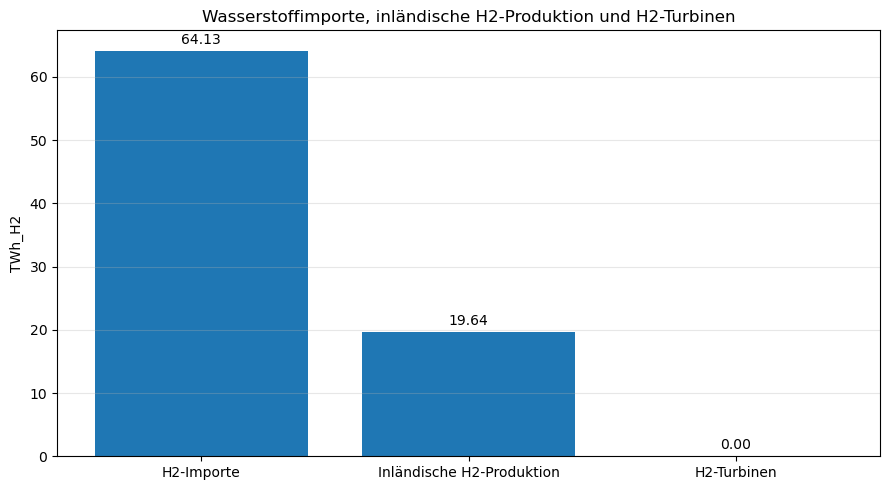

In [ ]:
# -----------------------------
# H2-Importe aus Generatoren
# jetzt über den Namen/Suffix identifizieren
# -----------------------------
h2_import_gens = n.generators.index[
    n.generators.index.astype(str).str.endswith(" import H2 port")
]

print("H2-Import-Generatoren:")
print(h2_import_gens.tolist())


# -----------------------------
# H2-Busse finden
# -----------------------------
h2_buses = n.buses.index[
    n.buses.carrier == "H2"
]

print("\nH2-Busse:")
print(h2_buses.tolist())


# -----------------------------
# Inländische H2-Produktion:
# Standardmäßig über diese Links
# -----------------------------
h2_prod_carriers = ["H2 Electrolysis", "SMR", "SMR CC"]

h2_prod_links = n.links.index[
    (n.links.carrier.isin(h2_prod_carriers)) &
    (n.links.bus1.isin(h2_buses))
]

print("\nInländische H2-Produktions-Links:")
print(n.links.loc[h2_prod_links, ["carrier", "bus0", "bus1"]])


# -----------------------------
# H2-Turbinen-Links
# H2 wird an bus0 eingesetzt
# -----------------------------
h2_turbine_links = n.links.index[
    n.links.carrier == "H2 turbine"
]

print("\nH2-Turbinen-Links:")
print(n.links.loc[h2_turbine_links, ["carrier", "bus0", "bus1"]])


# -----------------------------
# Snapshot-Gewichte
# -----------------------------
weights = n.snapshot_weightings.generators


# -----------------------------
# 1. H2-Importe [MWh_H2]
# -----------------------------
h2_import_mwh = (
    n.generators_t.p[h2_import_gens]
    .multiply(weights, axis=0)
    .sum()
    .sum()
)


# -----------------------------
# 2. Inländische H2-Produktion [MWh_H2]
# H2-Ausgabe liegt auf p1 und ist dort negativ
# -> Vorzeichen drehen
# -----------------------------
h2_domestic_mwh = (
    (-n.links_t.p1[h2_prod_links])
    .clip(lower=0)
    .multiply(weights, axis=0)
    .sum()
    .sum()
)


# -----------------------------
# 3. H2-Verbrauch in Turbinen [MWh_H2]
# H2-Einsatz liegt auf p0
# -----------------------------
h2_turbine_mwh = (
    n.links_t.p0[h2_turbine_links]
    .clip(lower=0)
    .multiply(weights, axis=0)
    .sum()
    .sum()
)

print(f"H2-Importe: {h2_import_mwh:,.2f} MWh_H2")
print(f"Inländische H2-Produktion: {h2_domestic_mwh:,.2f} MWh_H2")
print(f"H2-Verbrauch in Turbinen: {h2_turbine_mwh:,.2f} MWh_H2")



# -----------------------------
# Plot
# -----------------------------
values = pd.Series({
    "H2-Importe": h2_import_mwh / 1e6,                  # TWh_H2
    "Inländische H2-Produktion": h2_domestic_mwh / 1e6, # TWh_H2
    "H2-Turbinen": h2_turbine_mwh / 1e6                 # TWh_H2
})

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(values.index, values.values)

ax.set_ylabel("TWh_H2")
ax.set_title("Wasserstoffimporte, inländische H2-Produktion und H2-Turbinen")
ax.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, values.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01 * max(values.max(), 1),
        f"{val:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
h2_turbines = n.links.index[n.links.carrier == "H2 turbine"]

print("Anzahl H2-Turbinen:", len(h2_turbines))
print("Gesamtleistung je Zeitschritt:")
display((-n.links_t.p1[h2_turbines]).sum(axis=1).head())

print("Gesamterzeugung [MWh]:")
print(((-n.links_t.p1[h2_turbines]).multiply(n.snapshot_weightings.generators, axis=0)).sum().sum())

Anzahl H2-Turbinen: 47
Gesamtleistung je Zeitschritt:


snapshot
2013-01-01    0.000599
2013-01-07    0.000599
2013-01-13    0.000283
2013-01-19    0.000691
2013-01-25    0.000420
dtype: float64

Gesamterzeugung [MWh]:
4.869464387510723


In [ ]:
h2_turbines = n.links.index[n.links.carrier == "H2 turbine"]
weights = n.snapshot_weightings.generators

print("Anzahl H2-Turbinen:", len(h2_turbines))
print("H2-Verbrauch je Zeitschritt:")
display(n.links_t.p0[h2_turbines].sum(axis=1).head())

print("Gesamtverbrauch H2 [MWh_H2]:")
print(n.links_t.p0[h2_turbines].multiply(weights, axis=0).sum().sum())

Anzahl H2-Turbinen: 47
H2-Verbrauch je Zeitschritt:


snapshot
2013-01-01    0.001392
2013-01-07    0.001393
2013-01-13    0.000657
2013-01-19    0.001607
2013-01-25    0.000978
dtype: float64

Gesamtverbrauch H2 [MWh_H2]:
11.324335784908664


H2-Busse:
['JP.10_1_AC H2', 'JP.11_1_AC H2', 'JP.12_1_AC H2', 'JP.13_1_AC H2', 'JP.14_1_AC H2', 'JP.15_1_AC H2', 'JP.16_1_AC H2', 'JP.17_1_AC H2', 'JP.18_1_AC H2', 'JP.19_1_AC H2', 'JP.1_1_AC H2', 'JP.20_1_AC H2', 'JP.21_1_AC H2', 'JP.22_1_AC H2', 'JP.23_1_AC H2', 'JP.24_1_AC H2', 'JP.25_1_AC H2', 'JP.26_1_AC H2', 'JP.27_1_AC H2', 'JP.28_1_AC H2', 'JP.29_1_AC H2', 'JP.2_1_AC H2', 'JP.30_1_AC H2', 'JP.31_1_AC H2', 'JP.32_1_AC H2', 'JP.33_1_AC H2', 'JP.34_1_AC H2', 'JP.35_1_AC H2', 'JP.36_1_AC H2', 'JP.37_1_AC H2', 'JP.38_1_AC H2', 'JP.39_1_AC H2', 'JP.3_1_AC H2', 'JP.40_1_AC H2', 'JP.41_1_AC H2', 'JP.42_1_AC H2', 'JP.43_1_AC H2', 'JP.44_1_AC H2', 'JP.45_1_AC H2', 'JP.46_1_AC H2', 'JP.47_1_AC H2', 'JP.4_1_AC H2', 'JP.5_1_AC H2', 'JP.6_1_AC H2', 'JP.7_1_AC H2', 'JP.8_1_AC H2', 'JP.9_1_AC H2', 'H2 export bus']

H2-Speicher:
['JP.10_1_AC H2 Store Tank', 'JP.11_1_AC H2 Store Tank', 'JP.12_1_AC H2 Store Tank', 'JP.13_1_AC H2 Store Tank', 'JP.14_1_AC H2 Store Tank', 'JP.15_1_AC H2 Store Tank',

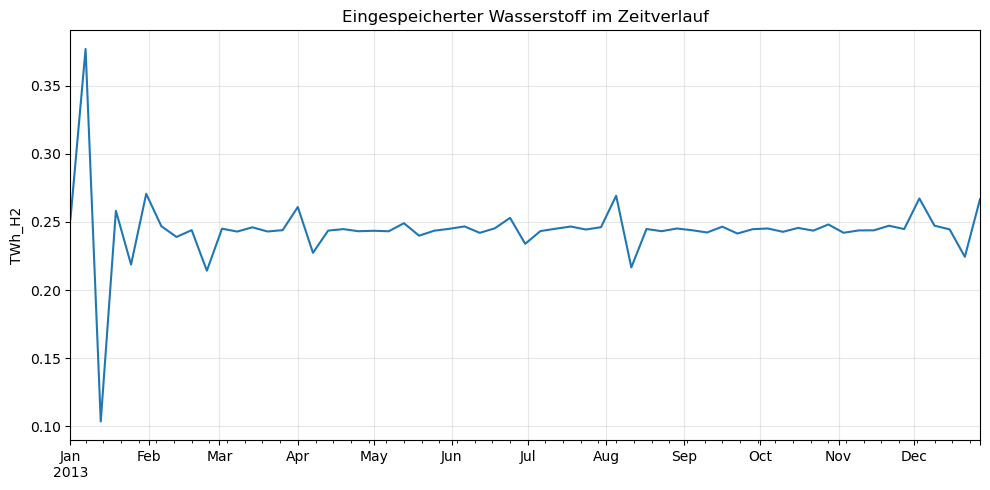

Aktueller Speicherstand (letzter Snapshot): 0.27 TWh_H2
Maximal gespeicherter Wasserstoff: 0.38 TWh_H2
Minimal gespeicherter Wasserstoff: 0.10 TWh_H2
Mittlerer gespeicherter Wasserstoff: 0.24 TWh_H2


In [ ]:
# -----------------------------
# H2-Busse finden
# -----------------------------
h2_buses = n.buses.index[n.buses.carrier == "H2"]

print("H2-Busse:")
print(h2_buses.tolist())


# -----------------------------
# H2-Stores finden
# robust über den Bus
# -----------------------------
h2_stores = n.stores.index[
    n.stores.bus.isin(h2_buses)
]

print("\nH2-Speicher:")
print(h2_stores.tolist())

print("\nDetails zu H2-Speichern:")
print(n.stores.loc[h2_stores, ["carrier", "bus"]])

# -----------------------------
# Eingespeicherter H2 im Zeitverlauf
# n.stores_t.e = gespeicherte Energiemenge
# -----------------------------
h2_stored_t = n.stores_t.e[h2_stores].sum(axis=1)    # TWh_H2

fig, ax = plt.subplots(figsize=(10, 5))

h2_stored_t.plot(ax=ax)

ax.set_title("Eingespeicherter Wasserstoff im Zeitverlauf")
ax.set_ylabel("TWh_H2")
ax.set_xlabel("")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Aktueller Speicherstand (letzter Snapshot): {h2_stored_t.iloc[-1]:.2f} TWh_H2")
print(f"Maximal gespeicherter Wasserstoff: {h2_stored_t.max():.2f} TWh_H2")
print(f"Minimal gespeicherter Wasserstoff: {h2_stored_t.min():.2f} TWh_H2")
print(f"Mittlerer gespeicherter Wasserstoff: {h2_stored_t.mean():.2f} TWh_H2")

Delivered Electricity and Heat by Carrier 

,Electricity [TWh],Heat [TWh],Other use [TWh],Total [TWh]
carrier,,,,
Geothermal,274.734644,3.759681,0.000000,278.494325
Gas,0.209720,55.021702,768.100272,823.331695
Coal,0.000011,0.000000,0.000000,0.000011
Oil,37.054103,0.000000,336.773849,373.827952


,Direct fossil loads [TWh],Other link outputs [TWh],Other use total [TWh]
carrier,,,
Gas,574.661476,193.438796,768.100272
Coal,0.000000,0.000000,0.000000
Oil,336.773849,0.000000,336.773849


Direct geothermal generator contribution: 0.558 TWh


,primary_fuel_import_or_generation_TWh
carrier,
gas,852.101892
coal,0.000032
oil,0.000001


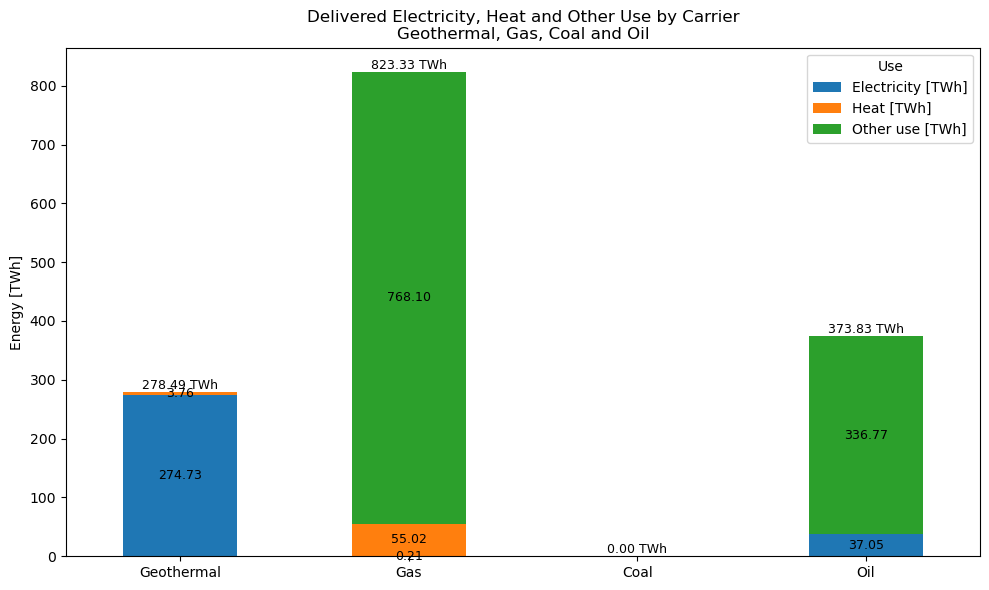

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

electric_bus_carriers = ["AC", "DC", "low voltage"]

# Heat buses are identified by their carrier name
heat_bus_pattern = "heat"

# Exclude non-energy output buses from "Other use"
non_energy_output_pattern = "co2|atmosphere|stored"

# Include existing conventional geothermal generators, if present
include_direct_geothermal_generators = True

# Exact geothermal link carrier names
orc_carrier = "geothermal organic rankine cycle"
dh_carrier = "geothermal district heat"

# Fossil fuels to analyse
fossil_fuels = ["gas", "coal", "oil"]


# ------------------------------------------------------------
# 0) Snapshot weighting
# ------------------------------------------------------------
# MW * hours = MWh

if hasattr(n, "snapshot_weightings") and "generators" in n.snapshot_weightings.columns:
    weights = n.snapshot_weightings["generators"].reindex(n.snapshots).fillna(1)
else:
    weights = pd.Series(1, index=n.snapshots)


# ------------------------------------------------------------
# Helper: calculate output energy from links
# ------------------------------------------------------------

def get_link_output_energy_TWh(links_subset, output_type):
    """
    Calculates delivered output energy from links in TWh.

    output_type:
        "electricity" -> output to AC/DC/low voltage buses
        "heat"        -> output to heat buses
        "other"       -> output to non-electric, non-heat, non-CO2 buses
                         e.g. gas for industry, H2, naphtha, etc.

    In PyPSA links:
        p0 is usually input.
        p1, p2, ... are outputs.
        Negative p on an output bus means injection into that bus.
    """
    energy_parts = []

    if links_subset.empty:
        return 0.0

    for bus_number in range(1, 6):
        bus_col = f"bus{bus_number}"
        p_col = f"p{bus_number}"

        if bus_col not in links_subset.columns:
            continue

        if not hasattr(n.links_t, p_col):
            continue

        output_bus_carrier = links_subset[bus_col].map(n.buses.carrier).astype(str)

        is_electricity = output_bus_carrier.isin(electric_bus_carriers)

        is_heat = output_bus_carrier.str.contains(
            heat_bus_pattern,
            case=False,
            regex=True,
            na=False
        )

        is_non_energy = output_bus_carrier.str.contains(
            non_energy_output_pattern,
            case=False,
            regex=True,
            na=False
        )

        if output_type == "electricity":
            mask = is_electricity

        elif output_type == "heat":
            mask = is_heat

        elif output_type == "other":
            mask = (
                ~is_electricity
                & ~is_heat
                & ~is_non_energy
                & output_bus_carrier.notna()
                & (output_bus_carrier != "nan")
            )

        else:
            raise ValueError("output_type must be 'electricity', 'heat' or 'other'.")

        if not mask.any():
            continue

        selected_links = links_subset.loc[mask]

        output = (
            -getattr(n.links_t, p_col)
            .reindex(index=n.snapshots, columns=selected_links.index)
            .fillna(0)
        )

        # Keep only positive delivered output
        output = output.clip(lower=0)

        # MWh
        energy_MWh = output.mul(weights, axis=0).sum().sum()

        energy_parts.append(energy_MWh)

    if len(energy_parts) == 0:
        return 0.0

    return sum(energy_parts) / 1e6  # MWh to TWh


# ------------------------------------------------------------
# Helper: calculate generator output energy
# ------------------------------------------------------------

def get_generator_energy_TWh(generators_subset):
    """
    Calculates positive generator output in TWh.
    """
    if generators_subset.empty:
        return 0.0

    dispatch = (
        n.generators_t.p
        .reindex(index=n.snapshots, columns=generators_subset.index)
        .fillna(0)
    )

    # Positive p means output from generator
    dispatch = dispatch.clip(lower=0)

    energy_MWh = dispatch.mul(weights, axis=0).sum().sum()

    return energy_MWh / 1e6  # MWh to TWh


# ------------------------------------------------------------
# Helper: calculate direct load consumption
# ------------------------------------------------------------

def get_load_energy_TWh(loads_subset):
    """
    Calculates direct final load consumption in TWh.
    Used for direct fossil loads, e.g. residential gas, services gas,
    transport oil, naphtha for industry, etc.
    """
    if loads_subset.empty:
        return 0.0

    static_p_set = (
        loads_subset["p_set"].fillna(0)
        if "p_set" in loads_subset.columns
        else pd.Series(0, index=loads_subset.index)
    )

    if hasattr(n.loads_t, "p_set"):
        load_ts = n.loads_t.p_set.reindex(
            index=n.snapshots,
            columns=loads_subset.index
        )
    else:
        load_ts = pd.DataFrame(
            np.nan,
            index=n.snapshots,
            columns=loads_subset.index
        )

    # Fill missing time series with static p_set
    load_ts = load_ts.T.fillna(static_p_set).T.fillna(0)

    # Positive load means consumption
    load_ts = load_ts.clip(lower=0)

    energy_MWh = load_ts.mul(weights, axis=0).sum().sum()

    return energy_MWh / 1e6  # MWh to TWh


# ------------------------------------------------------------
# 1) Geothermal electricity and heat
# ------------------------------------------------------------

links = n.links.copy()

orc_links = links[
    links.carrier.astype(str).str.lower() == orc_carrier.lower()
].copy()

dh_links = links[
    links.carrier.astype(str).str.lower() == dh_carrier.lower()
].copy()

geothermal_electricity_TWh = get_link_output_energy_TWh(
    orc_links,
    output_type="electricity"
)

geothermal_heat_TWh = get_link_output_energy_TWh(
    dh_links,
    output_type="heat"
)

geothermal_other_TWh = 0.0

# Optional: add existing direct geothermal generators
direct_geothermal_generator_TWh = 0.0

if include_direct_geothermal_generators:
    generators = n.generators.copy()

    generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

    direct_geothermal_generators = generators[
        generators.carrier.astype(str).str.contains(
            "geothermal",
            case=False,
            regex=True,
            na=False
        )
        & generators["bus_carrier"].isin(electric_bus_carriers)
    ].copy()

    direct_geothermal_generator_TWh = get_generator_energy_TWh(
        direct_geothermal_generators
    )

    geothermal_electricity_TWh += direct_geothermal_generator_TWh


# ------------------------------------------------------------
# 2) Fossil electricity, heat and other use from gas, coal and oil
# ------------------------------------------------------------
# Fossil fuel flows are classified by the input bus carrier of the link.
#
# Electricity:
#   fuel bus -> power plant / CHP -> AC/DC/low voltage bus
#
# Heat:
#   fuel bus -> boiler / CHP -> heat bus
#
# Other use:
#   a) direct loads on fuel buses, e.g. residential gas, services gas,
#      transport oil, naphtha, etc.
#   b) link outputs to non-electric, non-heat, non-CO2 buses,
#      e.g. gas for industry, H2 from SMR, etc.

links["input_bus_carrier"] = links.bus0.map(n.buses.carrier)

fossil_links = links[
    links["input_bus_carrier"].isin(fossil_fuels)
].copy()

loads = n.loads.copy()
loads["bus_carrier"] = loads.bus.map(n.buses.carrier)

fossil_results = []
other_breakdown = []

for fuel in fossil_fuels:
    selected_fuel_links = fossil_links[
        fossil_links["input_bus_carrier"] == fuel
    ].copy()

    # Electricity output from this fossil fuel
    electricity_TWh = get_link_output_energy_TWh(
        selected_fuel_links,
        output_type="electricity"
    )

    # Heat output from this fossil fuel
    heat_TWh = get_link_output_energy_TWh(
        selected_fuel_links,
        output_type="heat"
    )

    # Other link outputs, e.g. gas for industry, H2 from SMR
    other_link_output_TWh = get_link_output_energy_TWh(
        selected_fuel_links,
        output_type="other"
    )

    # Direct final loads on the corresponding fuel bus
    direct_fuel_loads = loads[
        loads["bus_carrier"] == fuel
    ].copy()

    direct_load_TWh = get_load_energy_TWh(
        direct_fuel_loads
    )

    other_TWh = other_link_output_TWh + direct_load_TWh

    fossil_results.append({
        "carrier": fuel.capitalize(),
        "Electricity [TWh]": electricity_TWh,
        "Heat [TWh]": heat_TWh,
        "Other use [TWh]": other_TWh,
    })

    other_breakdown.append({
        "carrier": fuel.capitalize(),
        "Direct fossil loads [TWh]": direct_load_TWh,
        "Other link outputs [TWh]": other_link_output_TWh,
        "Other use total [TWh]": other_TWh,
    })


# ------------------------------------------------------------
# 3) Combine results
# ------------------------------------------------------------

energy_by_carrier = pd.DataFrame(
    [
        {
            "carrier": "Geothermal",
            "Electricity [TWh]": geothermal_electricity_TWh,
            "Heat [TWh]": geothermal_heat_TWh,
            "Other use [TWh]": geothermal_other_TWh,
        }
    ]
    + fossil_results
).set_index("carrier")

# Remove tiny numerical values
energy_by_carrier = energy_by_carrier.where(
    energy_by_carrier.abs() > 1e-6,
    0
)

energy_by_carrier["Total [TWh]"] = energy_by_carrier.sum(axis=1)

display(energy_by_carrier)

other_breakdown = pd.DataFrame(other_breakdown).set_index("carrier")
display(other_breakdown)

print(
    f"Direct geothermal generator contribution: "
    f"{direct_geothermal_generator_TWh:.3f} TWh"
)


# ------------------------------------------------------------
# 4) Optional check: actually imported/generated fossil fuel from generators
# ------------------------------------------------------------
# These are primary fuel quantities from fuel generators,
# not final electricity/heat/other end use.

fuel_generators = n.generators[
    n.generators.carrier.astype(str).str.lower().isin(fossil_fuels)
].copy()

fuel_imports_from_generators_TWh = (
    n.generators_t.p[fuel_generators.index]
    .clip(lower=0)
    .mul(weights, axis=0)
    .sum()
    .groupby(fuel_generators.carrier)
    .sum()
    .div(1e6)
    .sort_values(ascending=False)
)

display(
    fuel_imports_from_generators_TWh
    .to_frame("primary_fuel_import_or_generation_TWh")
)


# ------------------------------------------------------------
# 5) Plot stacked bar chart
# ------------------------------------------------------------

plot_data = energy_by_carrier[
    [
        "Electricity [TWh]",
        "Heat [TWh]",
        "Other use [TWh]",
    ]
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

plot_data.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_ylabel("Energy [TWh]")
ax.set_xlabel("")
ax.set_title(
    "Delivered Electricity, Heat and Other Use by Carrier\n"
    "Geothermal, Gas, Coal and Oil"
)

ax.legend(title="Use")

# Add value labels
for container in ax.containers:
    labels = [
        f"{value:.2f}" if value > 0.01 else ""
        for value in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9
    )

# Add total labels above bars
totals = plot_data.sum(axis=1)

for i, total in enumerate(totals):
    if total > 0:
        ax.text(
            i,
            total,
            f"{total:.2f} TWh",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# Detailed breakdown table for Electricity, Heat and Other use
# ------------------------------------------------------------

def clean_network_name(name):
    """
    Removes regional prefixes from asset names where possible.
    Example: JP.10_1 residential gas -> residential gas
    """
    name = str(name)

    # Remove common PyPSA-Earth regional prefixes
    name = pd.Series([name]).str.replace(
        r"^[A-Z]{2}\.\d+_\d+(_AC)?\s+",
        "",
        regex=True
    ).iloc[0]

    return name


def classify_output_use(output_bus_carrier):
    """
    Classify link output bus carrier into Electricity, Heat, Other use or Ignore.
    """
    output_bus_carrier = str(output_bus_carrier)

    if output_bus_carrier in electric_bus_carriers:
        return "Electricity [TWh]"

    if pd.Series([output_bus_carrier]).str.contains(
        heat_bus_pattern,
        case=False,
        regex=True,
        na=False
    ).iloc[0]:
        return "Heat [TWh]"

    if pd.Series([output_bus_carrier]).str.contains(
        non_energy_output_pattern,
        case=False,
        regex=True,
        na=False
    ).iloc[0]:
        return "Ignore"

    return "Other use [TWh]"


def collect_link_output_breakdown(links_subset, carrier_label):
    """
    Create detailed TWh output table for selected links.
    Outputs are assigned to Electricity, Heat or Other use
    based on the output bus carrier.
    """
    rows = []

    if links_subset.empty:
        return pd.DataFrame(rows)

    for bus_number in range(1, 6):
        bus_col = f"bus{bus_number}"
        p_col = f"p{bus_number}"

        if bus_col not in links_subset.columns:
            continue

        if not hasattr(n.links_t, p_col):
            continue

        output_bus_carrier = links_subset[bus_col].map(n.buses.carrier)

        for use_category in ["Electricity [TWh]", "Heat [TWh]", "Other use [TWh]"]:

            mask = output_bus_carrier.map(classify_output_use) == use_category

            if not mask.any():
                continue

            selected_links = links_subset.loc[mask].copy()

            output = (
                -getattr(n.links_t, p_col)
                .reindex(index=n.snapshots, columns=selected_links.index)
                .fillna(0)
            )

            output = output.clip(lower=0)

            energy_by_link_TWh = (
                output
                .mul(weights, axis=0)
                .sum()
                .div(1e6)
            )

            for link_name, energy_TWh in energy_by_link_TWh.items():
                if energy_TWh <= 1e-8:
                    continue

                rows.append({
                    "Carrier": carrier_label,
                    "Use": use_category,
                    "Component": "Link",
                    "PyPSA carrier / name": selected_links.loc[link_name, "carrier"],
                    "Network object": link_name,
                    "Input bus carrier": selected_links.loc[link_name, "bus0"],
                    "Output bus carrier": output_bus_carrier.loc[link_name],
                    "Output bus": selected_links.loc[link_name, bus_col],
                    "Energy [TWh]": energy_TWh,
                })

    return pd.DataFrame(rows)


def collect_generator_breakdown(generators_subset, carrier_label, use_category):
    """
    Create detailed TWh table for selected generators.
    """
    rows = []

    if generators_subset.empty:
        return pd.DataFrame(rows)

    dispatch = (
        n.generators_t.p
        .reindex(index=n.snapshots, columns=generators_subset.index)
        .fillna(0)
        .clip(lower=0)
    )

    energy_by_generator_TWh = (
        dispatch
        .mul(weights, axis=0)
        .sum()
        .div(1e6)
    )

    for generator_name, energy_TWh in energy_by_generator_TWh.items():
        if energy_TWh <= 1e-8:
            continue

        rows.append({
            "Carrier": carrier_label,
            "Use": use_category,
            "Component": "Generator",
            "PyPSA carrier / name": generators_subset.loc[generator_name, "carrier"],
            "Network object": generator_name,
            "Input bus carrier": "",
            "Output bus carrier": generators_subset.loc[generator_name, "bus_carrier"],
            "Output bus": generators_subset.loc[generator_name, "bus"],
            "Energy [TWh]": energy_TWh,
        })

    return pd.DataFrame(rows)


def collect_direct_load_breakdown(loads_subset, carrier_label):
    """
    Create detailed TWh table for direct final loads on fossil buses.
    These are counted as Other use.
    """
    rows = []

    if loads_subset.empty:
        return pd.DataFrame(rows)

    static_p_set = (
        loads_subset["p_set"].fillna(0)
        if "p_set" in loads_subset.columns
        else pd.Series(0, index=loads_subset.index)
    )

    if hasattr(n.loads_t, "p_set"):
        load_ts = n.loads_t.p_set.reindex(
            index=n.snapshots,
            columns=loads_subset.index
        )
    else:
        load_ts = pd.DataFrame(
            np.nan,
            index=n.snapshots,
            columns=loads_subset.index
        )

    load_ts = load_ts.T.fillna(static_p_set).T.fillna(0)
    load_ts = load_ts.clip(lower=0)

    energy_by_load_TWh = (
        load_ts
        .mul(weights, axis=0)
        .sum()
        .div(1e6)
    )

    for load_name, energy_TWh in energy_by_load_TWh.items():
        if energy_TWh <= 1e-8:
            continue

        load_carrier = loads_subset.loc[load_name, "carrier"]

        if pd.isna(load_carrier) or str(load_carrier).strip() == "":
            display_name = clean_network_name(load_name)
        else:
            display_name = str(load_carrier)

        rows.append({
            "Carrier": carrier_label,
            "Use": "Other use [TWh]",
            "Component": "Load",
            "PyPSA carrier / name": display_name,
            "Network object": load_name,
            "Input bus carrier": "",
            "Output bus carrier": loads_subset.loc[load_name, "bus_carrier"],
            "Output bus": loads_subset.loc[load_name, "bus"],
            "Energy [TWh]": energy_TWh,
        })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# 1) Geothermal breakdown
# ------------------------------------------------------------

breakdown_parts = []

# Geothermal ORC electricity
breakdown_parts.append(
    collect_link_output_breakdown(
        orc_links,
        carrier_label="Geothermal"
    )
)

# Geothermal district heat
breakdown_parts.append(
    collect_link_output_breakdown(
        dh_links,
        carrier_label="Geothermal"
    )
)

# Direct geothermal generators, if included
if include_direct_geothermal_generators:
    generators = n.generators.copy()
    generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

    direct_geothermal_generators = generators[
        generators.carrier.astype(str).str.contains(
            "geothermal",
            case=False,
            regex=True,
            na=False
        )
        & generators["bus_carrier"].isin(electric_bus_carriers)
    ].copy()

    breakdown_parts.append(
        collect_generator_breakdown(
            direct_geothermal_generators,
            carrier_label="Geothermal",
            use_category="Electricity [TWh]"
        )
    )


# ------------------------------------------------------------
# 2) Fossil breakdown: gas, coal, oil
# ------------------------------------------------------------

links = n.links.copy()
links["input_bus_carrier"] = links.bus0.map(n.buses.carrier)

loads = n.loads.copy()
loads["bus_carrier"] = loads.bus.map(n.buses.carrier)

for fuel in fossil_fuels:
    carrier_label = fuel.capitalize()

    # Links using this fuel as input
    selected_fuel_links = links[
        links["input_bus_carrier"] == fuel
    ].copy()

    breakdown_parts.append(
        collect_link_output_breakdown(
            selected_fuel_links,
            carrier_label=carrier_label
        )
    )

    # Direct final loads on this fuel bus
    selected_fuel_loads = loads[
        loads["bus_carrier"] == fuel
    ].copy()

    breakdown_parts.append(
        collect_direct_load_breakdown(
            selected_fuel_loads,
            carrier_label=carrier_label
        )
    )


# ------------------------------------------------------------
# 3) Combine detailed breakdown
# ------------------------------------------------------------

detailed_breakdown = pd.concat(
    [df for df in breakdown_parts if df is not None and not df.empty],
    ignore_index=True
)

detailed_breakdown = detailed_breakdown[
    detailed_breakdown["Energy [TWh]"] > 1e-8
].copy()


# ------------------------------------------------------------
# 4) Summary table by PyPSA carrier / name
# ------------------------------------------------------------

breakdown_summary = (
    detailed_breakdown
    .groupby(
        [
            "Carrier",
            "Use",
            "Component",
            "PyPSA carrier / name",
            "Output bus carrier",
        ],
        dropna=False
    )
    .agg(
        **{
            "Energy [TWh]": ("Energy [TWh]", "sum"),
            "Number of network objects": ("Network object", "nunique"),
        }
    )
    .reset_index()
    .sort_values(
        ["Carrier", "Use", "Energy [TWh]"],
        ascending=[True, True, False]
    )
)

display(breakdown_summary)


# ------------------------------------------------------------
# 5) Pivot table, easier to read
# ------------------------------------------------------------

breakdown_pivot = (
    breakdown_summary
    .pivot_table(
        index=[
            "Carrier",
            "Component",
            "PyPSA carrier / name",
            "Output bus carrier",
        ],
        columns="Use",
        values="Energy [TWh]",
        aggfunc="sum",
        fill_value=0
    )
)

for col in ["Electricity [TWh]", "Heat [TWh]", "Other use [TWh]"]:
    if col not in breakdown_pivot.columns:
        breakdown_pivot[col] = 0.0

breakdown_pivot["Total [TWh]"] = (
    breakdown_pivot["Electricity [TWh]"]
    + breakdown_pivot["Heat [TWh]"]
    + breakdown_pivot["Other use [TWh]"]
)

breakdown_pivot = (
    breakdown_pivot
    .sort_values("Total [TWh]", ascending=False)
)

display(breakdown_pivot)


# ------------------------------------------------------------
# 6) Check against bar chart totals
# ------------------------------------------------------------

check_against_plot = (
    detailed_breakdown
    .groupby(["Carrier", "Use"])["Energy [TWh]"]
    .sum()
    .unstack(fill_value=0)
)

for col in ["Electricity [TWh]", "Heat [TWh]", "Other use [TWh]"]:
    if col not in check_against_plot.columns:
        check_against_plot[col] = 0.0

check_against_plot["Total [TWh]"] = check_against_plot.sum(axis=1)

display(check_against_plot)

,Carrier,Use,Component,PyPSA carrier / name,Output bus carrier,Energy [TWh],Number of network objects
0,Coal,Electricity [TWh],Link,coal,AC,0.000011,33
1,Gas,Electricity [TWh],Link,CCGT,AC,0.209704,20
3,Gas,Electricity [TWh],Link,urban central gas CHP CC,AC,0.000010,47
2,Gas,Electricity [TWh],Link,urban central gas CHP,AC,0.000007,47
5,Gas,Heat [TWh],Link,residential urban decentral gas boiler,residential urban decentral heat,53.236848,47
4,Gas,Heat [TWh],Link,residential rural gas boiler,residential rural heat,1.452621,39
7,Gas,Heat [TWh],Link,services urban decentral gas boiler,services urban decentral heat,0.324245,47
6,Gas,Heat [TWh],Link,services rural gas boiler,services rural heat,0.007949,39
10,Gas,Heat [TWh],Link,urban central gas boiler,urban central heat,0.000022,47
9,Gas,Heat [TWh],Link,urban central gas CHP CC,urban central heat,0.000011,47


Use                                                                                           Electricity [TWh]  \
Carrier    Component PyPSA carrier / name                   Output bus carrier                                    
Gas        Load      services gas                           gas                                        0.000000   
Geothermal Link      geothermal organic rankine cycle       AC                                       274.177063   
Oil        Load      land transport oil                     oil                                        0.000000   
Gas        Link      gas for industry CC                    gas for industry                           0.000000   
Oil        Load      services oil                           oil                                        0.000000   
                     residential oil                        oil                                        0.000000   
Gas        Link      residential urban decentral gas boiler residential urban decentral heat           0.000000   
           Load      residential gas                        gas                                        0.000000   
Oil        Link      oil                                    AC                                        37.054103   
Gas        Link      SMR CC                                 H2                                         0.000000   
Geothermal Link      geothermal district heat               urban central heat                         0.000000   
Gas        Link      residential rural gas boiler           residential rural heat                     0.000000   
Geothermal Generator geothermal                             AC                                         0.557581   
Gas        Link      services urban decentral gas boiler    services urban decentral heat              0.000000   
                     CCGT                                   AC                                         0.209704   
                     SMR                                    H2                                         0.000000   
                     services rural gas boiler              services rural heat                        0.000000   
                     gas for industry                       gas for industry                           0.000000   
                     urban central gas boiler               urban central heat                         0.000000   
Coal       Link      coal                                   AC                                         0.000011   
Gas        Link      urban central gas CHP CC               urban central heat                         0.000000   
                                                            AC                                         0.000010   
                     urban central gas CHP                  AC                                         0.000007   
                                                            urban central heat                         0.000000   

Use                                                                                           Heat [TWh]  \
Carrier    Component PyPSA carrier / name                   Output bus carrier                             
Gas        Load      services gas                           gas                                 0.000000   
Geothermal Link      geothermal organic rankine cycle       AC                                  0.000000   
Oil        Load      land transport oil                     oil                                 0.000000   
Gas        Link      gas for industry CC                    gas for industry                    0.000000   
Oil        Load      services oil                           oil                                 0.000000   
                     residential oil                        oil                                 0.000000   
Gas        Link      residential urban decentral gas boiler residential urban decentral heat   53.236848   
           Load      residential gas 

Use,Electricity [TWh],Heat [TWh],Other use [TWh],Total [TWh]
Carrier,,,,
Coal,0.000011,0.000000,0.000000,0.000011
Gas,0.209720,55.021702,768.100272,823.331695
Geothermal,274.734644,3.759681,0.000000,278.494325
Oil,37.054103,0.000000,336.773849,373.827952


,heat_consumption_TWh
bus_carrier,
residential urban decentral heat,81.546508
urban central heat,4.492860
residential rural heat,3.549478
services urban decentral heat,0.684812
services rural heat,0.029808


Total heat consumption: 90.30 TWh


,bus,bus_carrier,carrier,heat_consumption_TWh
Load,,,,
JP.41_1_AC residential urban decentral heat,JP.41_1_AC residential urban decentral heat,residential urban decentral heat,residential urban decentral heat,7.230596
JP.35_1_AC residential urban decentral heat,JP.35_1_AC residential urban decentral heat,residential urban decentral heat,residential urban decentral heat,6.172094
JP.19_1_AC residential urban decentral heat,JP.19_1_AC residential urban decentral heat,residential urban decentral heat,residential urban decentral heat,5.873969
JP.1_1_AC residential urban decentral heat,JP.1_1_AC residential urban decentral heat,residential urban decentral heat,residential urban decentral heat,4.287722
JP.33_1_AC residential urban decentral heat,JP.33_1_AC residential urban decentral heat,residential urban decentral heat,residential urban decentral heat,4.115623
...,...,...,...,...
JP.14_1_AC services rural heat,JP.14_1_AC services rural heat,services rural heat,services rural heat,0.000006
JP.33_1_AC services rural heat,JP.33_1_AC services rural heat,services rural heat,services rural heat,0.000006
JP.19_1_AC services rural heat,JP.19_1_AC services rural heat,services rural heat,services rural heat,0.000004


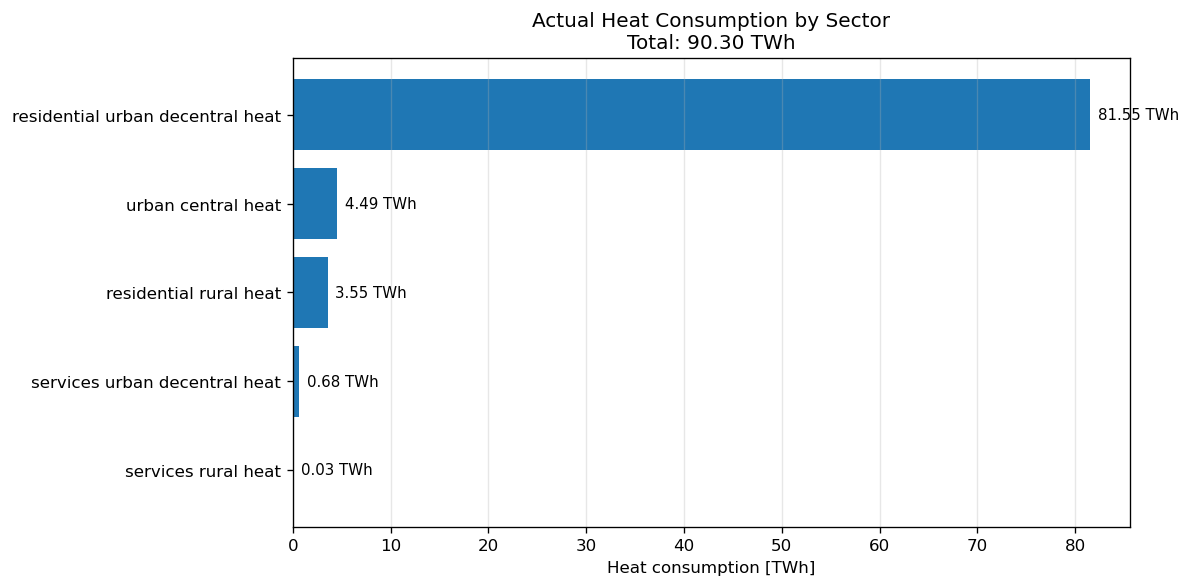

In [ ]:
# Falls n noch nicht existiert, diese Zeile aktivieren:
# n = pypsa.Network(network_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.dpi"] = 120


# ------------------------------------------------------------
# 1) Snapshot weights
# ------------------------------------------------------------

def get_snapshot_weights(network):
    """
    Returns snapshot weights for energy calculation.
    MW * hours = MWh
    """
    sw = getattr(network, "snapshot_weightings", None)

    if isinstance(sw, pd.DataFrame):
        if "generators" in sw.columns:
            return sw["generators"].reindex(network.snapshots).astype(float).fillna(1.0)
        if "objective" in sw.columns:
            return sw["objective"].reindex(network.snapshots).astype(float).fillna(1.0)

    return pd.Series(1.0, index=network.snapshots)


weights = get_snapshot_weights(n)


# ------------------------------------------------------------
# 2) Detect heat bus carriers
# ------------------------------------------------------------

heat_bus_carriers = (
    n.buses.carrier.astype(str)
    .loc[lambda s: s.str.contains("heat", case=False, na=False)]
    .dropna()
    .sort_values()
    .unique()
    .tolist()
)

if not heat_bus_carriers:
    raise ValueError("Keine Heat-Bus-Carrier im Netzwerk gefunden.")


# ------------------------------------------------------------
# 3) Heat consumption from loads
# ------------------------------------------------------------
# Endverbrauch wird hier als Last auf Heat-Bussen definiert.
# Nicht gezählt werden interne Geothermie-Wärmeflüsse unter der Oberfläche.

loads = n.loads.copy()

loads["bus_carrier"] = loads.bus.map(n.buses.carrier)

heat_loads = loads[
    loads["bus_carrier"].isin(heat_bus_carriers)
].copy()

if heat_loads.empty:
    raise ValueError("Keine Loads auf Heat-Bussen gefunden.")


# ------------------------------------------------------------
# 4) Load time series
# ------------------------------------------------------------

# Static p_set fallback
static_p_set = (
    heat_loads["p_set"].fillna(0)
    if "p_set" in heat_loads.columns
    else pd.Series(0.0, index=heat_loads.index)
)

# Time-dependent p_set
if hasattr(n.loads_t, "p_set") and not n.loads_t.p_set.empty:
    heat_load_ts = n.loads_t.p_set.reindex(
        index=n.snapshots,
        columns=heat_loads.index
    )
else:
    heat_load_ts = pd.DataFrame(
        np.nan,
        index=n.snapshots,
        columns=heat_loads.index
    )

# Fill missing time series with static p_set
heat_load_ts = heat_load_ts.T.fillna(static_p_set).T.fillna(0)

# Positive values are consumption
heat_load_ts = heat_load_ts.clip(lower=0)


# ------------------------------------------------------------
# 5) Convert MW to TWh
# ------------------------------------------------------------

heat_consumption_by_load_TWh = (
    heat_load_ts
    .mul(weights, axis=0)
    .sum(axis=0)
    .div(1e6)  # MWh to TWh
)

heat_loads["heat_consumption_TWh"] = heat_consumption_by_load_TWh


# ------------------------------------------------------------
# 6) Aggregate by heat sector
# ------------------------------------------------------------

heat_consumption_by_sector = (
    heat_loads
    .groupby("bus_carrier")["heat_consumption_TWh"]
    .sum()
    .sort_values(ascending=False)
)

heat_consumption_by_sector = heat_consumption_by_sector[
    heat_consumption_by_sector > 1e-9
]

total_heat_consumption_TWh = heat_consumption_by_sector.sum()

display(
    heat_consumption_by_sector
    .to_frame("heat_consumption_TWh")
)

print(
    f"Total heat consumption: "
    f"{total_heat_consumption_TWh:.2f} TWh"
)


# ------------------------------------------------------------
# 7) Optional detailed load table
# ------------------------------------------------------------

heat_load_detail = (
    heat_loads[
        [
            "bus",
            "bus_carrier",
            "carrier",
            "heat_consumption_TWh",
        ]
    ]
    .copy()
    .sort_values("heat_consumption_TWh", ascending=False)
)

heat_load_detail = heat_load_detail[
    heat_load_detail["heat_consumption_TWh"] > 1e-9
]

display(heat_load_detail)


# ------------------------------------------------------------
# 8) Plot: actual heat consumption by sector
# ------------------------------------------------------------

plot_df = heat_consumption_by_sector.sort_values(ascending=True)

fig, ax = plt.subplots(
    figsize=(10, max(5, 0.5 * len(plot_df)))
)

ax.barh(
    plot_df.index,
    plot_df.values
)

ax.set_xlabel("Heat consumption [TWh]")
ax.set_ylabel("")
ax.set_title(
    "Actual Heat Consumption by Sector\n"
    f"Total: {total_heat_consumption_TWh:.2f} TWh"
)

ax.grid(axis="x", alpha=0.3)

xmax = plot_df.max() if len(plot_df) else 0

for i, value in enumerate(plot_df.values):
    ax.text(
        value + (0.01 * xmax if xmax > 0 else 0.1),
        i,
        f"{value:.2f} TWh",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()



,technology,technology_group,heat_sector,heat_supply_TWh
20,urban central solid biomass CHP CC,Solid Biomass CHP,district heat / urban central heat,3.524566e+02
5,residential urban decentral gas boiler,Gas Boiler,residential urban decentral heat,5.323685e+01
6,residential urban decentral resistive heater,Resistive Heater,residential urban decentral heat,1.882139e+01
4,residential urban decentral air heat pump,Heat Pump,residential urban decentral heat,9.488241e+00
0,geothermal district heat,Geothermal District Heat,district heat / urban central heat,3.759681e+00
1,residential rural gas boiler,Gas Boiler,residential rural heat,1.452621e+00
3,residential rural resistive heater,Resistive Heater,residential rural heat,1.051939e+00
2,residential rural ground heat pump,Heat Pump,residential rural heat,1.044900e+00
12,services urban decentral gas boiler,Gas Boiler,services urban decentral heat,3.242448e-01
11,services urban decentral air heat pump,Heat Pump,services urban decentral heat,2.394148e-01


,heat_supply_TWh
technology_group,
Solid Biomass CHP,3.524567e+02
Gas Boiler,5.502168e+01
Resistive Heater,2.001075e+01
Heat Pump,1.078695e+01
Geothermal District Heat,3.759681e+00
Gas CHP,1.770259e-05
Water Tank Discharger,5.243857e-07


,heat_supply_TWh
heat_sector,
district heat / urban central heat,356.225198
residential urban decentral heat,81.546476
residential rural heat,3.549459
services urban decentral heat,0.684801
services rural heat,0.029796


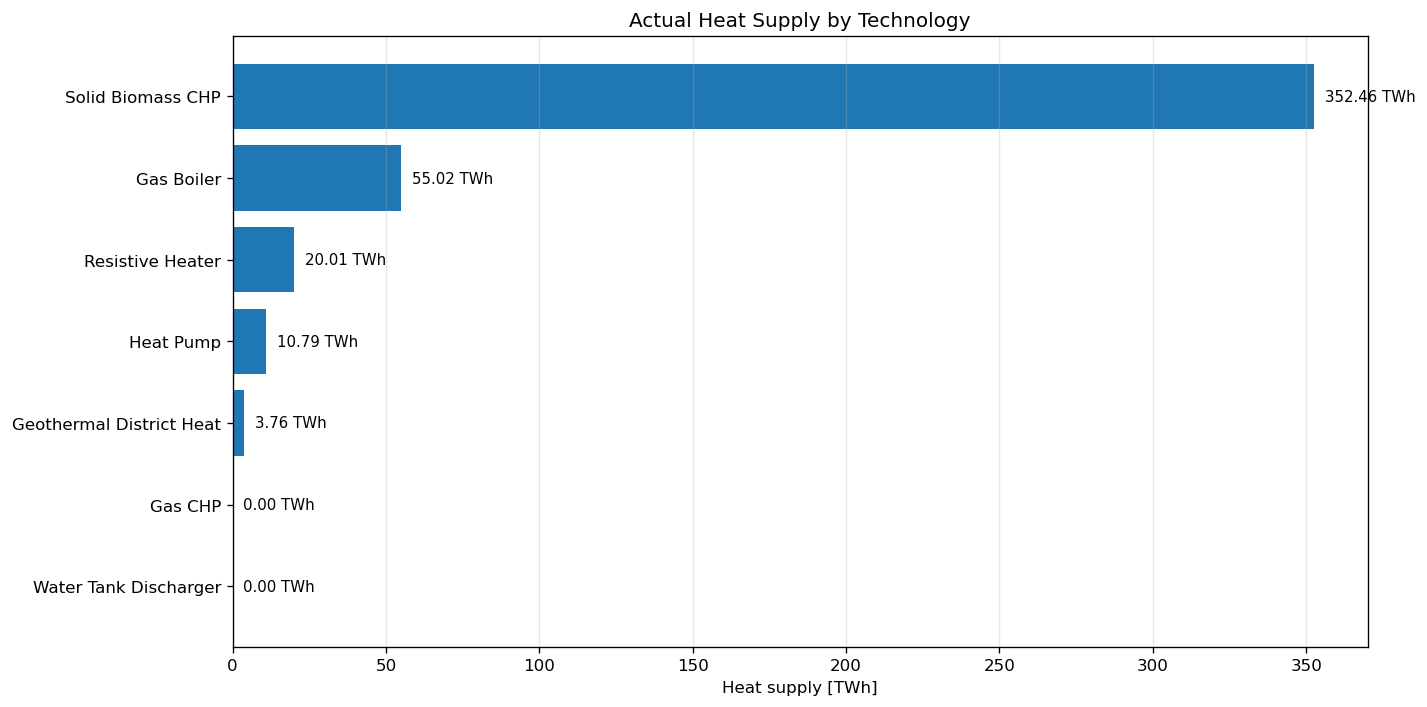

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.dpi"] = 120


# ------------------------------------------------------------
# 1) Snapshot weights
# ------------------------------------------------------------

def get_snapshot_weights(network):
    sw = getattr(network, "snapshot_weightings", None)

    if isinstance(sw, pd.DataFrame):
        if "generators" in sw.columns:
            return sw["generators"].reindex(network.snapshots).astype(float).fillna(1.0)
        if "objective" in sw.columns:
            return sw["objective"].reindex(network.snapshots).astype(float).fillna(1.0)

    return pd.Series(1.0, index=network.snapshots)


weights = get_snapshot_weights(n)


# ------------------------------------------------------------
# 2) Final heat bus carriers
# ------------------------------------------------------------
# "geothermal heat" is excluded because it is an internal geothermal source bus,
# not final heat demand.

final_heat_bus_carriers = (
    n.buses.carrier.astype(str)
    .loc[lambda s: s.str.contains("heat", case=False, na=False)]
    .dropna()
    .sort_values()
    .unique()
    .tolist()
)

final_heat_bus_carriers = [
    c for c in final_heat_bus_carriers
    if c.lower() != "geothermal heat"
]

if not final_heat_bus_carriers:
    raise ValueError("Keine finalen Heat-Bus-Carrier gefunden.")


# ------------------------------------------------------------
# 3) Helper functions for clearer labels
# ------------------------------------------------------------

def rename_heat_sector(heat_sector):
    heat_sector = str(heat_sector)

    if heat_sector == "urban central heat":
        return "district heat / urban central heat"

    return heat_sector


def group_heat_technology(carrier):
    carrier = str(carrier)
    carrier_lower = carrier.lower()

    if "geothermal district heat" in carrier_lower:
        return "Geothermal District Heat"

    if "solid biomass chp" in carrier_lower:
        return "Solid Biomass CHP"

    if "gas chp" in carrier_lower:
        return "Gas CHP"

    if "gas boiler" in carrier_lower:
        return "Gas Boiler"

    if "heat pump" in carrier_lower:
        return "Heat Pump"

    if "resistive heater" in carrier_lower:
        return "Resistive Heater"

    if "water tanks discharger" in carrier_lower:
        return "Water Tank Discharger"

    if "water tanks charger" in carrier_lower:
        return "Water Tank Charger"

    return carrier


# ------------------------------------------------------------
# 4) Heat supply from links
# ------------------------------------------------------------

links = n.links.copy()

heat_supply_rows = []

for bus_number in range(1, 6):
    bus_col = f"bus{bus_number}"
    p_col = f"p{bus_number}"

    if bus_col not in links.columns:
        continue

    if not hasattr(n.links_t, p_col):
        continue

    output_bus_carrier = links[bus_col].map(n.buses.carrier)

    mask = output_bus_carrier.isin(final_heat_bus_carriers)

    if not mask.any():
        continue

    selected_links = links.loc[mask].copy()

    # In PyPSA links:
    # negative p at output bus = injection/supply into that bus.
    # Important: first multiply by -1, then clip lower values.
    heat_output = (
        -getattr(n.links_t, p_col)
        .reindex(index=n.snapshots, columns=selected_links.index)
        .fillna(0)
    ).clip(lower=0)

    heat_energy_by_link_TWh = (
        heat_output
        .mul(weights, axis=0)
        .sum(axis=0)
        .div(1e6)  # MWh to TWh
    )

    for link_name, value in heat_energy_by_link_TWh.items():
        if value <= 1e-9:
            continue

        technology = selected_links.loc[link_name, "carrier"]
        heat_sector = output_bus_carrier.loc[link_name]

        heat_supply_rows.append({
            "technology": technology,
            "technology_group": group_heat_technology(technology),
            "link": link_name,
            "heat_sector": rename_heat_sector(heat_sector),
            "raw_heat_sector": heat_sector,
            "heat_supply_TWh": value,
        })


heat_supply_detail = pd.DataFrame(heat_supply_rows)

if heat_supply_detail.empty:
    raise ValueError("Keine Wärmebereitstellung aus Links gefunden.")


# ------------------------------------------------------------
# 5) Detailed table: technology and heat sector
# ------------------------------------------------------------

heat_supply_by_technology_sector = (
    heat_supply_detail
    .groupby(["technology", "technology_group", "heat_sector"], as_index=False)["heat_supply_TWh"]
    .sum()
    .sort_values("heat_supply_TWh", ascending=False)
)

display(heat_supply_by_technology_sector)


# ------------------------------------------------------------
# 6) Aggregate by technology group
# ------------------------------------------------------------

heat_supply_by_group = (
    heat_supply_detail
    .groupby("technology_group")["heat_supply_TWh"]
    .sum()
    .sort_values(ascending=False)
)

display(
    heat_supply_by_group
    .to_frame("heat_supply_TWh")
)


# ------------------------------------------------------------
# 7) Aggregate by final heat sector
# ------------------------------------------------------------

heat_supply_by_sector = (
    heat_supply_detail
    .groupby("heat_sector")["heat_supply_TWh"]
    .sum()
    .sort_values(ascending=False)
)

display(
    heat_supply_by_sector
    .to_frame("heat_supply_TWh")
)


# ------------------------------------------------------------
# 8) Plot: heat supply by technology group
# ------------------------------------------------------------

plot_df = heat_supply_by_group.sort_values(ascending=True)

fig, ax = plt.subplots(
    figsize=(12, max(6, 0.45 * len(plot_df)))
)

ax.barh(
    plot_df.index,
    plot_df.values
)

ax.set_xlabel("Heat supply [TWh]")
ax.set_ylabel("")
ax.set_title("Actual Heat Supply by Technology")

ax.grid(axis="x", alpha=0.3)

xmax = plot_df.max()

for i, value in enumerate(plot_df.values):
    ax.text(
        value + 0.01 * xmax,
        i,
        f"{value:.2f} TWh",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

,value_TWh
Total electricity generation,1625.345462
Total electricity demand,1487.169241
Electricity loads only,1107.439920
Electricity used by links,379.729259
Electricity used for storage charging,0.000062


,electricity_generation_TWh
carrier,
solar,313.648476
solar rooftop,287.558445
onwind,287.016583
geothermal ORC,274.177063
nuclear,272.329097
solid biomass CHP,92.573065
hydro + PHS,46.223502
oil,37.054103
offwind,11.841084


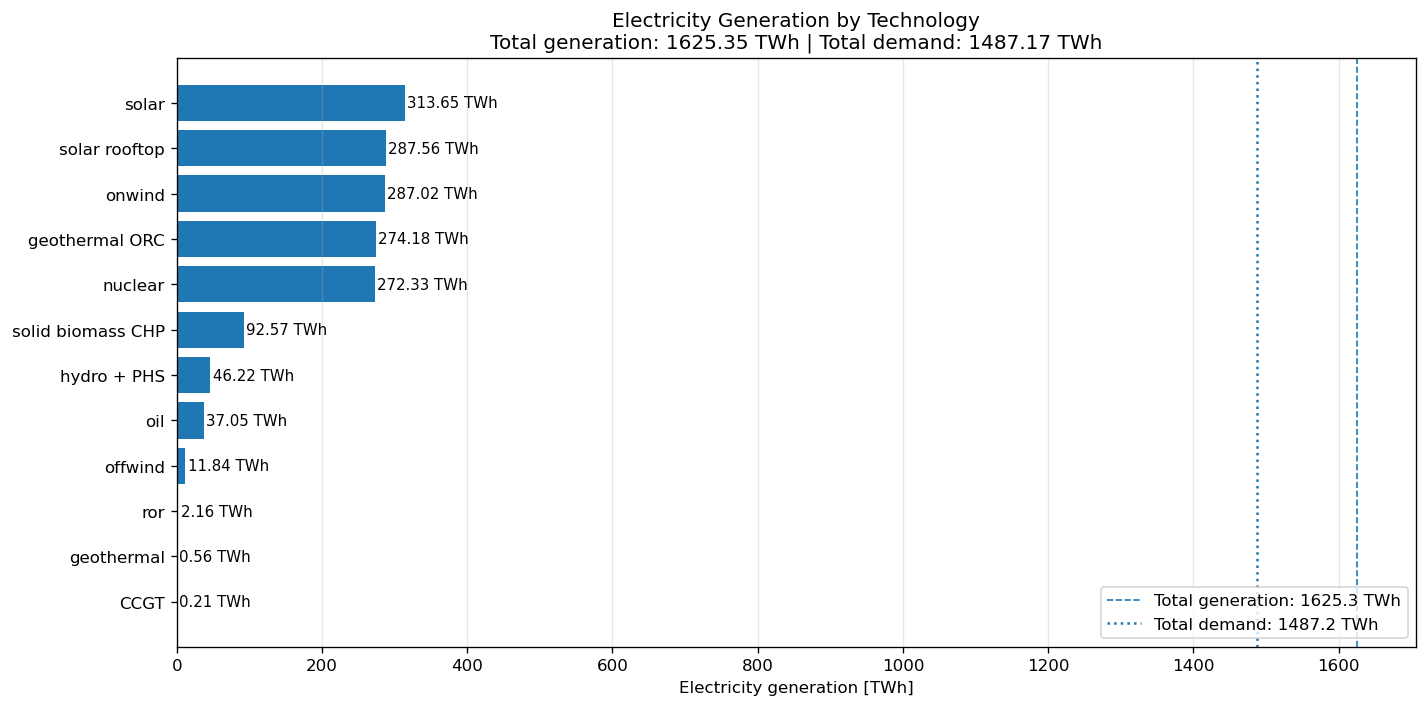

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.dpi"] = 120


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

electric_bus_carriers = ["AC", "DC", "low voltage"]

# Falls du nur größere Technologien im Plot anzeigen willst
min_generation_TWh = 0.01

# Carrier-Gruppierung
merge_solar_rooftop = False
merge_offwind = True
merge_hydro_phs = True


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def get_snapshot_weights(network):
    """
    Snapshot weights for converting MW to MWh.
    """
    sw = getattr(network, "snapshot_weightings", None)

    if isinstance(sw, pd.DataFrame):
        if "generators" in sw.columns:
            return sw["generators"].reindex(network.snapshots).astype(float).fillna(1.0)
        if "objective" in sw.columns:
            return sw["objective"].reindex(network.snapshots).astype(float).fillna(1.0)

    return pd.Series(1.0, index=network.snapshots)


def map_carrier(carrier):
    """
    Vereinheitlicht Carrier-Namen für die Darstellung.
    """
    carrier_str = str(carrier)
    carrier_low = carrier_str.lower()

    if merge_solar_rooftop:
        if carrier_low in ["solar", "solar rooftop", "solar-rooftop"]:
            return "solar + rooftop"

    if merge_offwind:
        if carrier_low.startswith("offwind"):
            return "offwind"

    if merge_hydro_phs:
        if carrier_low in ["hydro", "phs", "pumped hydro storage"]:
            return "hydro + PHS"

    if carrier_low == "ccgt":
        return "CCGT"

    if carrier_low == "ocgt":
        return "OCGT"

    if "urban central gas chp" in carrier_low:
        return "urban central gas CHP"

    if "solid biomass chp" in carrier_low:
        return "solid biomass CHP"

    if "geothermal organic rankine cycle" in carrier_low:
        return "geothermal ORC"

    if "geothermal" in carrier_low:
        return "geothermal"

    return carrier_str


def aggregate_by_carrier(series):
    """
    Gruppiert Carrier-Namen und summiert Werte.
    """
    if series.empty:
        return pd.Series(dtype=float)

    series = series.copy()
    series.index = series.index.to_series().map(map_carrier)

    return series.groupby(level=0).sum()


weights = get_snapshot_weights(n)


# ------------------------------------------------------------
# 1) Electricity generation from generators
# ------------------------------------------------------------

generators = n.generators.copy()

generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

electric_generators = generators[
    generators["bus_carrier"].isin(electric_bus_carriers)
    & ~generators.carrier.astype(str).str.contains("load", case=False, na=False)
].copy()

if not electric_generators.empty:
    generator_dispatch = (
        n.generators_t.p
        .reindex(index=n.snapshots, columns=electric_generators.index)
        .fillna(0)
        .clip(lower=0)
    )

    generator_energy_by_asset_TWh = (
        generator_dispatch
        .mul(weights, axis=0)
        .sum(axis=0)
        .div(1e6)
    )

    generator_energy_by_carrier = (
        generator_energy_by_asset_TWh
        .groupby(electric_generators.carrier)
        .sum()
    )
else:
    generator_energy_by_carrier = pd.Series(dtype=float)

generator_energy_by_carrier = aggregate_by_carrier(generator_energy_by_carrier)


# ------------------------------------------------------------
# 2) Electricity generation from links
# ------------------------------------------------------------
# Für Links gilt:
# p0 ist meist Input.
# p1, p2, ... sind Outputs.
# Output in einen Strombus ist meistens negativ.
# Deshalb: elektrische Erzeugung = -pX auf elektrischem Output-Bus.

links = n.links.copy()

link_generation_parts = []

for bus_number in range(1, 6):
    bus_col = f"bus{bus_number}"
    p_col = f"p{bus_number}"

    if bus_col not in links.columns:
        continue

    if not hasattr(n.links_t, p_col):
        continue

    output_bus_carrier = links[bus_col].map(n.buses.carrier)
    input_bus_carrier = links["bus0"].map(n.buses.carrier)

    # Nur echte Stromerzeugung zählen:
    # Output auf Strombus, Input nicht von Strombus.
    # Dadurch werden z. B. Netzleitungen, Batterielader, V2G etc. nicht doppelt gezählt.
    mask = (
        output_bus_carrier.isin(electric_bus_carriers)
        & ~input_bus_carrier.isin(electric_bus_carriers)
    )

    if not mask.any():
        continue

    selected_links = links.loc[mask].copy()

    link_output = (
        -getattr(n.links_t, p_col)
        .reindex(index=n.snapshots, columns=selected_links.index)
        .fillna(0)
    ).clip(lower=0)

    link_energy_by_asset_TWh = (
        link_output
        .mul(weights, axis=0)
        .sum(axis=0)
        .div(1e6)
    )

    tmp = pd.DataFrame({
        "carrier": selected_links.carrier,
        "electricity_generation_TWh": link_energy_by_asset_TWh,
    })

    link_generation_parts.append(tmp)


if link_generation_parts:
    link_energy_by_carrier = (
        pd.concat(link_generation_parts)
        .groupby("carrier")["electricity_generation_TWh"]
        .sum()
    )
else:
    link_energy_by_carrier = pd.Series(dtype=float)

link_energy_by_carrier = aggregate_by_carrier(link_energy_by_carrier)


# ------------------------------------------------------------
# 3) Electricity generation from storage units
# ------------------------------------------------------------
# Positive p bei StorageUnits = Entladung / Einspeisung ins Stromnetz.

storage_units = n.storage_units.copy()

if not storage_units.empty:
    storage_units["bus_carrier"] = storage_units.bus.map(n.buses.carrier)

    electric_storage_units = storage_units[
        storage_units["bus_carrier"].isin(electric_bus_carriers)
    ].copy()

    if not electric_storage_units.empty:
        storage_dispatch = (
            n.storage_units_t.p
            .reindex(index=n.snapshots, columns=electric_storage_units.index)
            .fillna(0)
            .clip(lower=0)
        )

        storage_energy_by_asset_TWh = (
            storage_dispatch
            .mul(weights, axis=0)
            .sum(axis=0)
            .div(1e6)
        )

        storage_energy_by_carrier = (
            storage_energy_by_asset_TWh
            .groupby(electric_storage_units.carrier)
            .sum()
        )
    else:
        storage_energy_by_carrier = pd.Series(dtype=float)
else:
    storage_energy_by_carrier = pd.Series(dtype=float)

storage_energy_by_carrier = aggregate_by_carrier(storage_energy_by_carrier)


# ------------------------------------------------------------
# 4) Combine electricity generation
# ------------------------------------------------------------

electricity_generation_by_carrier = (
    pd.concat(
        [
            generator_energy_by_carrier,
            link_energy_by_carrier,
            storage_energy_by_carrier,
        ],
        axis=0
    )
    .groupby(level=0)
    .sum()
    .sort_values(ascending=False)
)

electricity_generation_by_carrier = electricity_generation_by_carrier[
    electricity_generation_by_carrier > min_generation_TWh
]

total_electricity_generation_TWh = electricity_generation_by_carrier.sum()


# ------------------------------------------------------------
# 5) Calculate total electricity demand
# ------------------------------------------------------------
# Hier wird elektrischer Bedarf als Entnahme aus Strombussen berechnet:
# - Loads auf Strombussen
# - Link-Inputs von Strombussen, z. B. Elektrolyse, Heat Pumps, BEV charging
# - StorageUnit charging

# ------------------------------------------------------------
# 5a) Electricity loads
# ------------------------------------------------------------
# Important:
# Use n.loads_t.p first, because it contains the actual solved / effective
# load time series in this network. n.loads_t.p_set is incomplete here.

loads = n.loads.copy()
loads["bus_carrier"] = loads.bus.map(n.buses.carrier)

electric_loads = loads[
    loads["bus_carrier"].isin(electric_bus_carriers)
].copy()

if not electric_loads.empty:
    static_p_set = (
        electric_loads["p_set"].fillna(0)
        if "p_set" in electric_loads.columns
        else pd.Series(0.0, index=electric_loads.index)
    )

    # Prefer actual load time series p over p_set
    if hasattr(n.loads_t, "p") and not n.loads_t.p.empty:
        load_ts = n.loads_t.p.reindex(
            index=n.snapshots,
            columns=electric_loads.index
        )
    elif hasattr(n.loads_t, "p_set") and not n.loads_t.p_set.empty:
        load_ts = n.loads_t.p_set.reindex(
            index=n.snapshots,
            columns=electric_loads.index
        )
    else:
        load_ts = pd.DataFrame(
            np.nan,
            index=n.snapshots,
            columns=electric_loads.index
        )

    # Fill missing values with static p_set
    load_ts = load_ts.T.fillna(static_p_set).T.fillna(0)

    # Positive values are consumption
    load_ts = load_ts.clip(lower=0)

    electric_load_demand_TWh = (
        load_ts
        .mul(weights, axis=0)
        .sum()
        .sum()
        / 1e6
    )
else:
    electric_load_demand_TWh = 0.0


# 5b) Electricity consumed by links at bus0
links = n.links.copy()

links["bus0_carrier"] = links.bus0.map(n.buses.carrier)

electric_input_links = links[
    links["bus0_carrier"].isin(electric_bus_carriers)
].copy()

# Ausschließen: reine Stromnetz-Links, bei denen auch Output wieder Strom ist
# Sonst würden Leitungen/Übertragungen als Bedarf gezählt.
if not electric_input_links.empty:
    output_is_electric = pd.Series(False, index=electric_input_links.index)

    for bus_number in range(1, 6):
        bus_col = f"bus{bus_number}"

        if bus_col not in electric_input_links.columns:
            continue

        output_is_electric = (
            output_is_electric
            | electric_input_links[bus_col].map(n.buses.carrier).isin(electric_bus_carriers)
        )

    electric_consuming_links = electric_input_links[
        ~output_is_electric
    ].copy()

    if not electric_consuming_links.empty and hasattr(n.links_t, "p0"):
        link_electric_demand_TWh = (
            n.links_t.p0
            .reindex(index=n.snapshots, columns=electric_consuming_links.index)
            .fillna(0)
            .clip(lower=0)
            .mul(weights, axis=0)
            .sum()
            .sum()
            / 1e6
        )
    else:
        link_electric_demand_TWh = 0.0
else:
    link_electric_demand_TWh = 0.0


# 5c) Storage charging
# Negative p bei StorageUnits = Laden / Stromverbrauch.

if not storage_units.empty:
    electric_storage_units = storage_units[
        storage_units.bus.map(n.buses.carrier).isin(electric_bus_carriers)
    ].copy()

    if not electric_storage_units.empty:
        storage_charging_TWh = (
            (-n.storage_units_t.p)
            .reindex(index=n.snapshots, columns=electric_storage_units.index)
            .fillna(0)
            .clip(lower=0)
            .mul(weights, axis=0)
            .sum()
            .sum()
            / 1e6
        )
    else:
        storage_charging_TWh = 0.0
else:
    storage_charging_TWh = 0.0


total_electricity_demand_TWh = (
    electric_load_demand_TWh
    + link_electric_demand_TWh
    + storage_charging_TWh
)


# ------------------------------------------------------------
# 6) Output tables
# ------------------------------------------------------------

summary = pd.DataFrame({
    "value_TWh": {
        "Total electricity generation": total_electricity_generation_TWh,
        "Total electricity demand": total_electricity_demand_TWh,
        "Electricity loads only": electric_load_demand_TWh,
        "Electricity used by links": link_electric_demand_TWh,
        "Electricity used for storage charging": storage_charging_TWh,
    }
})

display(summary)

display(
    electricity_generation_by_carrier
    .to_frame("electricity_generation_TWh")
)


# ------------------------------------------------------------
# 7) Plot
# ------------------------------------------------------------

plot_df = electricity_generation_by_carrier.sort_values(ascending=True)

fig, ax = plt.subplots(
    figsize=(12, max(6, 0.45 * len(plot_df)))
)

ax.barh(
    plot_df.index,
    plot_df.values
)

ax.set_xlabel("Electricity generation [TWh]")
ax.set_ylabel("")
ax.set_title(
    "Electricity Generation by Technology\n"
    f"Total generation: {total_electricity_generation_TWh:.2f} TWh | "
    f"Total demand: {total_electricity_demand_TWh:.2f} TWh"
)

ax.grid(axis="x", alpha=0.3)

xmax = plot_df.max() if len(plot_df) else 0

for i, value in enumerate(plot_df.values):
    ax.text(
        value + (0.01 * xmax if xmax > 0 else 0.1),
        i,
        f"{value:.2f} TWh",
        va="center",
        fontsize=9
    )

# Demand and generation reference lines
ax.axvline(
    total_electricity_generation_TWh,
    linestyle="--",
    linewidth=1,
    label=f"Total generation: {total_electricity_generation_TWh:.1f} TWh"
)

ax.axvline(
    total_electricity_demand_TWh,
    linestyle=":",
    linewidth=1.5,
    label=f"Total demand: {total_electricity_demand_TWh:.1f} TWh"
)

ax.legend(loc="lower right")

plt.tight_layout()
plt.show()